# 1. Predecir la trayectoria e intensidad de huracanes aplicando modelos de aprendizaje automático, con enfoque en aquellos que amenacen las Islas de San Andrés y Providencia, Caribe colombiano

Objetivo General
Predecir la trayectoria e intensidad de huracanes aplicando modelos de aprendizaje automático, con enfoque en aquellos que amenacen las Islas de San Andrés y Providencia, Caribe colombiano.


Objetivos Específicos 

* Realizar extracción, transformación y carga (ETL) de datos mediante reglas para limpiar y organizar datos en bruto y prepararlos para el almacenamiento, el análisis de datos e implementación de modelos de ML para la predicción de la trayectoria e intensidad de huracanes.

* Realizar un Análisis Exploratorio de Datos (EDA) con base en la matriz de datos elaborada, como mecanismo para la detección de patrones importantes, datos faltantes y atípicos a tratar, así como también, el preprocesamiento de cada una de las variables de entrada de los modelos de aprendizaje automático, para la predicción de la trayectoria e intensidad de huracanes. 

* Implementar y evaluar distintos modelos estadísticos y de aprendizaje automático para la predicción de la trayectoria e intensidad de huracanes, mediante el uso de métricas de evaluación y validación cruzada adecuadas, así como métodos de optimización para la selección de parámetros.





#### Librerías

In [109]:
import matplotlib
matplotlib.use("Agg")
import pandas as pd

# Mostrar todas las columnas sin truncar
#pd.set_option('display.max_columns', None)
#pd.set_option('display.width', None)
#pd.set_option('display.max_colwidth', None)
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import joblib
import missingno as msno

# 2. ETL 

In [110]:
df = pd.read_csv('datos/hurdat2-1851-2023-051124.txt', sep= ',', names=['Date', 'Hour','RecIdentifier','type_storm','Latitude',
                                                              'Longitude','Max_wind','MinPress','NE34','SE34','SW34','NW34',
                                                              'NE50','SE50','SW50','NW50','NE64','SE64','SW64','NW64','Rad_Max_Wind'])

df.head(5)

,Date,Hour,RecIdentifier,type_storm,Latitude,Longitude,Max_wind,MinPress,NE34,SE34,...,NW34,NE50,SE50,SW50,NW50,NE64,SE64,SW64,NW64,Rad_Max_Wind
0,AL011851,UNNAMED,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18510625,0000,,HU,28.0N,94.8W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,18510625,0600,,HU,28.0N,95.4W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,18510625,1200,,HU,28.0N,96.0W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,18510625,1800,,HU,28.1N,96.5W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [111]:
# Agregar nuevas columnas para almacenar los valores extraídos
df["Code_storm"] = np.nan
df["Name_storm"] = np.nan
df["Trackets"] = np.nan

# Variables temporales para almacenar los valores
current_code, current_name, current_rec = None, None, None

for index, row in df.iterrows():
    if str(row["Date"]).startswith("AL"):
        current_code, current_name, current_rec = row["Date"], row["Hour"], row["RecIdentifier"]

    df.at[index, "Code_storm"] = current_code
    df.at[index, "Name_storm"] = current_name
    df.at[index, "Trackets"] = current_rec


# Eliminar filas donde la columna "Date" comienza con "AL"
df = df[~df["Date"].astype(str).str.startswith("AL")].reset_index(drop=True)

# Reubicar las columnas code_storm, name_storm y recIdentifier al inicio
column_order = ["Code_storm", "Name_storm", "Trackets"] + [col for col in df.columns if col not in ["Code_storm", "Name_storm", "Trackets"]]
df_procesado = df[column_order]


# Extraer el valor numérico y convertirlo a formato numérico
df_procesado['Lat_N'] = pd.to_numeric(df_procesado['Latitude'].str.extract(r'(\d+\.\d+)', expand=False))
df_procesado['Lon_W'] = pd.to_numeric(df_procesado['Longitude'].str.extract(r'(\d+\.\d+)', expand=False))


# Eliminar las columnas originales 'Latitude' y 'Longitude'
df_procesado.drop(['Latitude', 'Longitude'], axis=1, inplace=True)


# Cambia la columna 'nombre_columna' a tipo string
df_procesado['type_storm'] = df_procesado['type_storm'].astype(str) # Para asegurar que sea tipo String
df_procesado['type_storm'] = df_procesado['type_storm'].str.strip().str.upper() # Asegurar que no haya espacios en los targets y todo sean en MAYUS
df_procesado['Code_storm'] = df_procesado['Code_storm'].astype(str)
df_procesado['Code_storm'] = df_procesado['Code_storm'].str.strip().str.upper()


###### AJUSTES EN DATOS DE FECHA #######

df_procesado['Date'] = pd.to_datetime(df_procesado['Date'], format='%Y%m%d', errors='coerce')

#Convertir la columna en Date en datetime
#hrc['Date'] = pd.to_datetime(hrc['Date'])

# Crear nuevas columnas para año, mes y día
df_procesado['year'] = df_procesado['Date'].dt.year
df_procesado['month'] = df_procesado['Date'].dt.month
df_procesado['day'] = df_procesado['Date'].dt.day

# Eliminar la columna original "Date"
df_procesado.drop('Date', axis=1, inplace=True)

# Reorganizar las columnas: mover 'Año', 'Mes' y 'Día' a las posiciones 3, 4 y 5
columnas = list(df_procesado.columns)
# Insertar las nuevas columnas en las posiciones deseadas
columnas_nuevas = ['year', 'month', 'day']
for i, columna in enumerate(columnas_nuevas):
    columnas.remove(columna)  # Eliminar la columna de su posición original
    columnas.insert(3 + i, columna)  # Insertar en la nueva posición (3, 4 y 5)

# Reordenar el DataFrame
df_procesado = df_procesado[columnas]

# Conversión y separación de la hora y los minutos
df_procesado['Hour'] = df_procesado['Hour'].astype(int)  # Asegurar enteros
df_procesado['hour'] = df_procesado['Hour'] // 100  # División entera para las horas
#df_procesado['minuto'] = df_procesado['Hour'] % 100  # Resto para los minutos

df_procesado.drop('Hour', axis=1, inplace=True) # Eliminar la columna Hour

# Move 'hora' and 'minuto' columns to positions 7 and 8
cols = list(df_procesado.columns)
cols.insert(7, cols.pop(cols.index('hour')))
#cols.insert(8, cols.pop(cols.index('minuto')))
df_procesado = df_procesado[cols]

df_procesado['fecha'] = pd.to_datetime(
    df_procesado[['year', 'month', 'day', 'hour']]
    )

########################################

## Se verifican datos duplicados y se reemplaza -99 por NaN
duplicados = df_procesado.duplicated()
print(duplicados.sum())

# Reemplazar -999 por NaN en todo el DataFrame
df_procesado.replace(-999, np.nan, inplace=True)
df_procesado.replace(-99, np.nan, inplace=True)


# RecIdentifier y Trackets son variables descriptivas asociadas a la toma de información, se eliminan
df_procesado.drop(columns=['RecIdentifier', 'Trackets'], inplace=True)

/var/folders/_p/446c73rj4x19qh7rmqlrf1980000gp/T/ipykernel_2924/769007562.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'AL011851' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, "Code_storm"] = current_code
/var/folders/_p/446c73rj4x19qh7rmqlrf1980000gp/T/ipykernel_2924/769007562.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '            UNNAMED' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, "Name_storm"] = current_name
/var/folders/_p/446c73rj4x19qh7rmqlrf1980000gp/T/ipykernel_2924/769007562.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '     14' has dtype incompatible with float64, please explicitly cast to a

0


 Eliminación de la variable Rad_Max_wind

Los valores de esta variable solo han sido rastreados de manera precisa a partir de 2021. Por ende, es la variable que cuenta con menor cantidad de datos, teniendo 1331 registros o filas, lo cual representa el 2.46% del set de datos total. Por este motivo, se decidió borrar esta variable del conjunto de datos.  

Esta variable corresponde a los Radio de Vientos Máximos: Es la distancia desde el centro de un ciclón tropical hasta la ubicación de los vientos máximos del ciclón. En huracanes bien desarrollados, el radio de vientos máximos generalmente se encuentra en el borde interior de la pared del ojo (https://www.nhc.noaa.gov/aboutgloss.shtml#a)


In [112]:
# Eliminar la columna 'Rad_Max_Wind'
df_procesado.drop('Rad_Max_Wind', axis=1, inplace=True)

In [113]:
df_ETL = df_procesado
df_ETL.head(3)

,Code_storm,Name_storm,year,month,day,hour,type_storm,Max_wind,MinPress,NE34,...,SE50,SW50,NW50,NE64,SE64,SW64,NW64,Lat_N,Lon_W,fecha
0,AL011851,UNNAMED,1851,6,25,0,HU,80.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,94.8,1851-06-25 00:00:00
1,AL011851,UNNAMED,1851,6,25,6,HU,80.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,95.4,1851-06-25 06:00:00
2,AL011851,UNNAMED,1851,6,25,12,HU,80.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,96.0,1851-06-25 12:00:00


## 2.1 Agregar categorías de huracán y `type_storm` numérico

La reclasificación se hace aquí, al cierre del ETL, y no más adelante: es un recodificado determinista que aplica la escala Saffir-Simpson sobre el viento máximo registrado, sin ningún parámetro estimado a partir de los datos. Colocarlo en el ETL tiene además una consecuencia práctica: los tres bloques del EDA que vienen después —radios de viento, presión mínima y datos faltantes— se leen ya por categoría, y la imputación se limita a usar esa codificación en lugar de crearla.

* DB – Perturbación (de cualquier intensidad)
* WV – Onda tropical (de cualquier intensidad)
* LO – Baja no ciclónica (de cualquier intensidad)
* TD – Depresión tropical (< 34 nudos)
* SD – Depresión subtropical (< 34 nudos)
* TS – Tormenta tropical (34-63 nudos)
* SS – Tormenta subtropical (> 34 nudos)
* EX – Ciclón extratropical (de cualquier intensidad
* HU – Huracán (> 64 nudos)

In [114]:
def clasificacion_huracan(df):
    '''
    64-82       Cat 1
    83-95       Cat 2
    96-113      Cat 3
    114-135     Cat 4
    Mayor 135 Cat 5
    '''
    condiciones = [
        (df['Max_wind'] >= 64) & (df['Max_wind'] <= 82),
        (df['Max_wind'] >= 83) & (df['Max_wind'] <= 95),
        (df['Max_wind'] >= 96) & (df['Max_wind'] <= 113),
        (df['Max_wind'] >= 114) & (df['Max_wind'] <= 135),
        (df['Max_wind'] > 135)
    ]

    categorias = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']

    # Crear una nueva columna en el DataFrame con las categorías de huracanes
    df['categoria_huracan'] = np.select(condiciones, categorias,default='Sin categoria')

    return df

df_ETL = clasificacion_huracan(df_ETL)

In [115]:
# Reemplazar 'HU' en 'type_storm' por el valor de 'categoria_huracan' de la misma fila
df_ETL.loc[df_ETL['type_storm'] == 'HU', 'type_storm'] = df_ETL.loc[df_ETL['type_storm'] == 'HU', 'categoria_huracan']

df_ETL.drop('categoria_huracan', axis=1, inplace=True)

Las filas 25198 y 25199 presentaban categoría "HU" o sea Huracán. Sin embargo, la velocidad de viento máxima en estos dos registros fue de 60 nudos, lo cual está por debajo de los límites de la escala Saffir-Simpson que categoriza los estados Huracán de 1 a 5. Siendo 5 el mas fuerte. 


Esto pudo deberse a un error al ingresar los datos por parte del NHC (Centro nacional de Huracanes de EE.UU) o que los vientos del viento de huracán se debilitaron pero se conservó el estado de la tormenta en "HU".

En cualquier caso, se decide eliminar estas dos filas para no generar ruido en los modelos de clasificación.

In [116]:
df_ETL = df_ETL.drop([25198, 25199])

A continuación procedemos a convertir las categorias a númericas de manera manual, quiere decir, asignarle valores especificos para cada estado de tormenta. 

Se usa el siguiente Mapeo, empezando el 1 con "TD" hasta 7 con "HU-Cat5" porque se usarán estas categorías para los modelos de clasificación de categorías. 

Mientras que las restantes, se les coloca números restantes en orden, pero estas categorías no serán usadas para entrenar los modelos. Porque lo ideal es que la operatividad de los modelos empiece desde el estado de Depresión Tropical (TD). Además de simplificar el problema a menos categorías. 

In [117]:
# Mapeo manual
mapeo_target = {'TD': 1, 'TS': 2, 'Cat 1': 3, 'Cat 2': 4, 'Cat 3': 5, 'Cat 4': 6, 'Cat 5': 7,
                'DB': 13, 'WV': 12, 'LO': 11, 'SD': 10, 'SS': 9, 'EX': 8,}

# Aplicar el mapeo a la columna 'type_storm'
df_ETL['type_storm_n'] = df_ETL['type_storm'].map(mapeo_target)

# 3. EDA 

### Estilo común de las figuras

Una sola paleta y unos pocos ajustes de `rcParams` para que todas las figuras del EDA se lean como un conjunto.

In [118]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

AZUL, MAGENTA = "#0F6FB5", "#B33A7D"
INK, MUTED, LINEA, SURF = "#1C1917", "#78716C", "#E7E5E4", "#FCFCFB"
RAMPA = LinearSegmentedColormap.from_list(
    "az", ["#DCEBF7", "#B6D5EC", "#8ABBDF", "#5B9CCD", "#2F7EBB", "#116FB6", "#0A5288"])
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": LINEA,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

## 3.1 Datos faltantes

In [119]:
df_ETL.isnull().sum()

Code_storm          0
Name_storm          0
year                0
month               0
day                 0
hour                0
type_storm          0
Max_wind           57
MinPress        30946
NE34            43800
SE34            43800
SW34            43800
NW34            43800
NE50            43800
SE50            43800
SW50            43800
NW50            43800
NE64            43800
SE64            43800
SW64            43800
NW64            43800
Lat_N               0
Lon_W               0
fecha               0
type_storm_n        0
dtype: int64

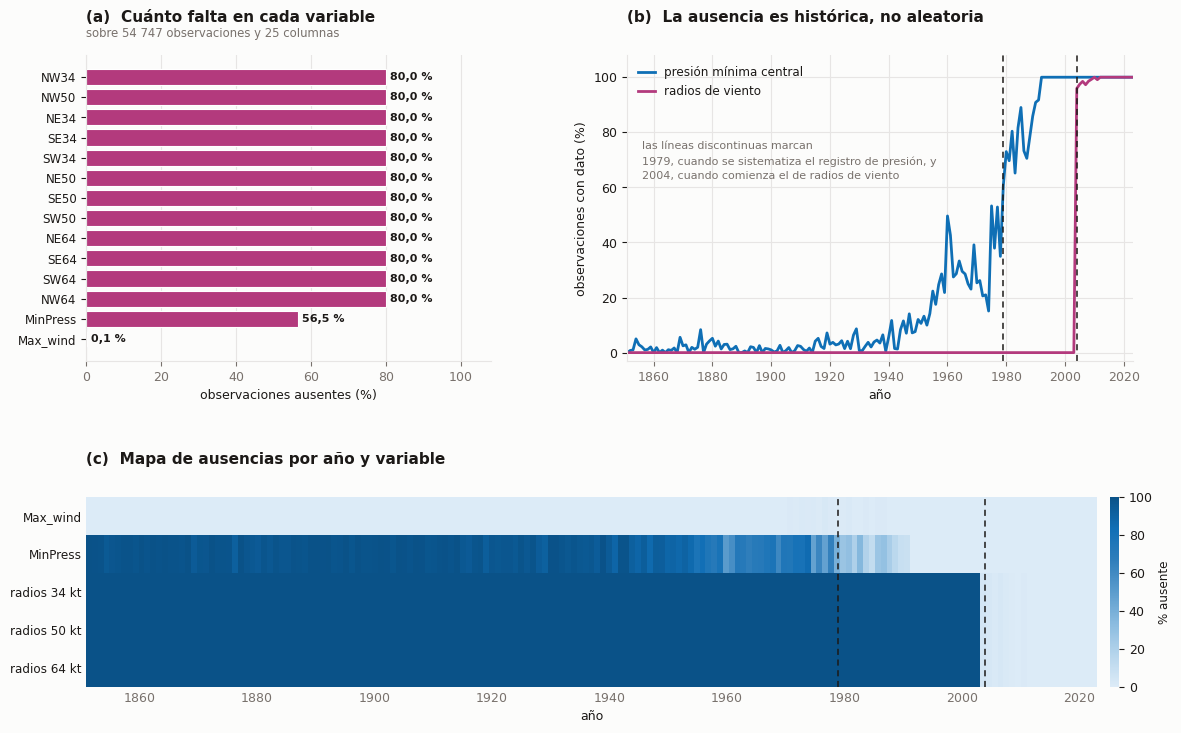

In [120]:
def figura_faltantes(d):
    fig = plt.figure(figsize=(13.5, 8.2))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.25], height_ratios=[1.0, 0.62],
                          wspace=0.30, hspace=0.55)

    # (a) porcentaje ausente por variable
    ax = fig.add_subplot(gs[0, 0])
    pct = (100 * d.isnull().mean()).sort_values()
    pct = pct[pct > 0]
    col = [MAGENTA if v > 50 else AZUL for v in pct]
    ax.barh(range(len(pct)), pct, color=col, edgecolor="white", lw=0.8)
    ax.set_yticks(range(len(pct))); ax.set_yticklabels(pct.index, fontsize=8.5)
    for i, v in enumerate(pct):
        ax.text(v + 1.2, i, f"{v:.1f} %".replace(".", ","), va="center",
                fontsize=8, color=INK, fontweight="bold")
    ax.set_xlim(0, 108); ax.set_xlabel("observaciones ausentes (%)")
    ax.set_title("(a)  Cuánto falta en cada variable", fontsize=11, fontweight="bold",
                 loc="left", color=INK, pad=24)
    ax.text(0, 1.06, f"sobre {len(d):,} observaciones y {d.shape[1]} columnas"
            .replace(",", " "), transform=ax.transAxes, fontsize=8.4, color=MUTED)
    ax.grid(axis="x", color=LINEA, lw=0.8); ax.set_axisbelow(True)

    # (b) cobertura a lo largo del tiempo
    ax2 = fig.add_subplot(gs[0, 1])
    cob = d.groupby("year").agg(n=("Code_storm", "size"),
                                press=("MinPress", lambda s: 100 * s.notna().mean()),
                                rad=("NE34", lambda s: 100 * s.notna().mean()))
    ax2.plot(cob.index, cob.press, lw=2, color=AZUL, label="presión mínima central")
    ax2.plot(cob.index, cob.rad, lw=2, color=MAGENTA, label="radios de viento")
    for x, et in ((1979, "1979\nse sistematiza\nel registro de presión"),
                  (2004, "2004\ncomienza el registro\nde radios")):
        ax2.axvline(x, color=INK, lw=1.1, ls=(0, (4, 3)))
        pass
    ax2.text(0.03, 0.72, "las líneas discontinuas marcan\n"
             "1979, cuando se sistematiza el registro de presión, y\n"
             "2004, cuando comienza el de radios de viento",
             transform=ax2.transAxes, fontsize=8, color=MUTED, va="top", linespacing=1.6)
    ax2.set_xlim(d.year.min(), d.year.max()); ax2.set_ylim(-3, 108)
    ax2.set_xlabel("año"); ax2.set_ylabel("observaciones con dato (%)")
    ax2.set_title("(b)  La ausencia es histórica, no aleatoria", fontsize=11,
                  fontweight="bold", loc="left", color=INK, pad=24)
    ax2.legend(frameon=False, fontsize=8.6, loc="upper left", handlelength=1.4)
    ax2.grid(color=LINEA, lw=0.8); ax2.set_axisbelow(True)

    # (c) mapa año x variable
    ax3 = fig.add_subplot(gs[1, :])
    aux = d[["year", "Max_wind", "MinPress"]].copy()
    for u in (34, 50, 64):
        aux[f"radios {u} kt"] = d[[f"{q}{u}" for q in ("NE", "SE", "SW", "NW")]].mean(axis=1)
    vars_map = ["Max_wind", "MinPress", "radios 34 kt", "radios 50 kt", "radios 64 kt"]
    M = aux.groupby("year")[vars_map].apply(lambda s: 100 * s.isnull().mean()).T
    im = ax3.imshow(M.values, aspect="auto", cmap=RAMPA, vmin=0, vmax=100,
                    extent=[M.columns.min(), M.columns.max(), len(vars_map) - 0.5, -0.5],
                    interpolation="nearest")
    ax3.set_yticks(range(len(vars_map))); ax3.set_yticklabels(vars_map, fontsize=8.6)
    ax3.set_xlabel("año")
    ax3.set_title("(c)  Mapa de ausencias por año y variable", fontsize=11,
                  fontweight="bold", loc="left", color=INK, pad=24)
    for x in (1979, 2004):
        ax3.axvline(x, color=INK, lw=1.1, ls=(0, (4, 3)))
    cb = fig.colorbar(im, ax=ax3, fraction=0.022, pad=0.012)
    cb.set_label("% ausente", fontsize=8.6); cb.outline.set_visible(False)
    ax3.spines[:].set_visible(False); ax3.tick_params(length=0)
    plt.show()

figura_faltantes(df_ETL)

Los datos faltantes corresponden a lo siguiente:

* "Minpress", "solo se incluían valores si había una observación específica que pudiera utilizarse explicitamente". A partir de 1979, se analizaba e incluía toda medición incluso si no fuese una medición in situ especifica.



* NE34 to NW64: Estos valores están disponibles a partir de 2004 con una resolución de hasta 5 millas nauticas. Las columnas de NE34 a NW64 hace referencia al Wind Radii o *Radios de viento*. "Se refiere a la distancia desde el centro de un huracán hasta donde los vientos alcanzan ciertas velocidades específicas, medidas en diferentes cuadrantes (noreste, sureste, suroeste y noroeste). Se utilizan para describir el tamaño del huracán y la extensión de los vientos peligrosos en diferentes direcciones". La distribución de los vientos alrededor de un huracán no es simétrica, entre mas lejos del ojo del huracán los vientos disminuyen y los vientos del lado derecho de la tormenta son mas fuertes en relación al lado izquierdo (De acuerdo a la dirección) (George & Gray, 1976).         
*NOTA*:Si bien es cierto que se observaron patrones importantes y que coinciden con la literatura de que son características importantes en cada estado de tormenta, la realidad es que la medición y obtención de estos radios en tiempo real no es práctica lo que entorpece el funcionamiento de un modelo operativo en tiempo real, además dentro del set de datos de HURDAT2 solo se tienen datos desde el 2004 hasta el año presente, y aunque se exploró la estrategia de imputar datos, esta no fue finalmente realizada ni incluida en el trabajo, ya que la naturaleza de la variable se presta para un trabajo adicional enfocado solamente en los radios del viento de los huracanes, por ello, se recomienda tenerla en cuenta para futuros trabajos o incluso explorar la predicción de esta variable importante en los huracanes






Gray, W. M., & Shea, D. J. (1976). Data summary of NOAA's hurricane inner-core radial leg flight penetrations 1957-1967, and 1969. Department of Atmospheric Sciences, Colorado State University.

## 3.2 Exploración de los Radios del viento

In [121]:
def find_negative_wind_radii(df):

  negative_values = {}
  for col in df.columns:
    if 'NW' in col or 'NE' in col or 'SE' in col or 'SW' in col:
      negative_rows = df[df[col] < 0]
      if not negative_rows.empty:
        negative_values[col] = negative_rows.index.tolist()
  return negative_values


negative_wind_radii = find_negative_wind_radii(df_ETL)

if negative_wind_radii:
  print("Valores negativos en las columnas NW, NE, SE y SW y sus posiciones:")
  for col, rows in negative_wind_radii.items():
    print(f"Columna: {col}")
    print(f"Filas con valores negativos: {rows}")
else:
  print("No se encontraron valores negativos en las columnas NW, NE, SE y SW.")

No se encontraron valores negativos en las columnas NW, NE, SE y SW.


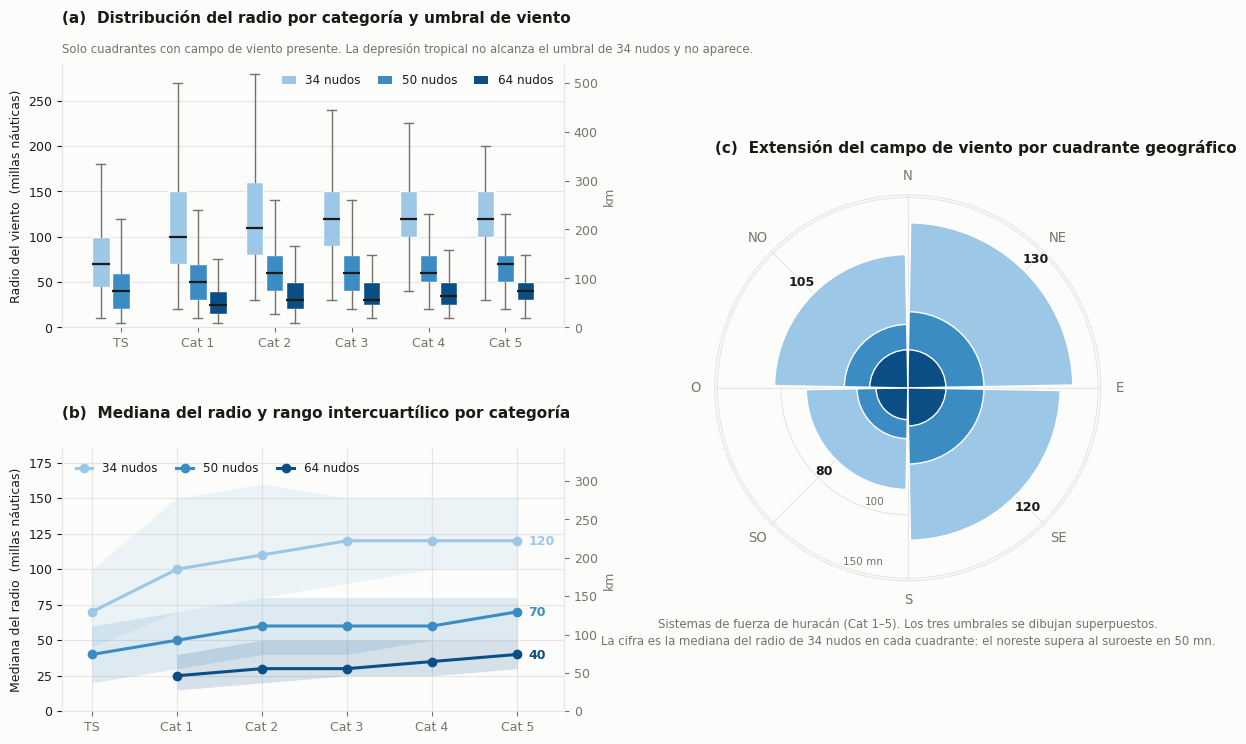

In [122]:
C34, C50, C64 = "#9CC7E6", "#3C8CC4", "#0A4E85"
UMB = [(34, C34), (50, C50), (64, C64)]
QUAD = {"NE": 45, "SE": 135, "SW": 225, "NW": 315}
NM_KM = 1.852
CATS = ["TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]

def figura_radios(d):
    def valores(cat, th):
        c = [f"{q}{th}" for q in QUAD]
        v = d.loc[d["type_storm"] == cat, c].values.ravel()
        v = v[~np.isnan(v)]
        return v[v > 0]

    fig = plt.figure(figsize=(13.4, 8.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.30, 1.0], height_ratios=[1.0, 1.0],
                          wspace=0.34, hspace=0.46)

    # (a) distribución por categoría y umbral
    ax = fig.add_subplot(gs[0, 0])
    pos, cajas, cols = [], [], []
    for i, cat in enumerate(CATS):
        for k, (th, col) in enumerate(UMB):
            v = valores(cat, th)
            if len(v) < 20:
                continue
            cajas.append(v); cols.append(col); pos.append(i + (k - 1) * 0.26)
    bp = ax.boxplot(cajas, positions=pos, widths=0.23, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, lw=1.6),
                    whiskerprops=dict(color=MUTED, lw=1.0), capprops=dict(color=MUTED, lw=1.0))
    for caja, col in zip(bp["boxes"], cols):
        caja.set(facecolor=col, edgecolor="white", lw=1.0)
    ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, fontsize=9)
    ax.set_ylabel("Radio del viento  (millas náuticas)"); ax.set_ylim(0, 290)
    ax.grid(axis="y", color=LINEA, lw=0.8); ax.set_axisbelow(True)
    ax.set_title("(a)  Distribución del radio por categoría y umbral de viento",
                 fontsize=11, fontweight="bold", loc="left", color=INK, pad=30)
    ax.text(0, 1.045, "Solo cuadrantes con campo de viento presente. La depresión tropical "
            "no alcanza el umbral de 34 nudos y no aparece.",
            transform=ax.transAxes, fontsize=8.4, color=MUTED)
    ax.legend(handles=[Patch(facecolor=c, label=f"{t} nudos") for t, c in UMB],
              frameon=False, fontsize=8.6, loc="upper right", ncol=3,
              handlelength=1.2, columnspacing=1.4, bbox_to_anchor=(1.0, 1.005))
    sec = ax.secondary_yaxis("right", functions=(lambda v: v * NM_KM, lambda v: v / NM_KM))
    sec.set_ylabel("km", fontsize=9, color=MUTED); sec.tick_params(colors=MUTED)

    # (b) mediana por categoría
    ax2 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(CATS))
    for th, col in UMB:
        med = [np.median(valores(c, th)) if len(valores(c, th)) >= 20 else np.nan for c in CATS]
        q1 = [np.percentile(valores(c, th), 25) if len(valores(c, th)) >= 20 else np.nan for c in CATS]
        q3 = [np.percentile(valores(c, th), 75) if len(valores(c, th)) >= 20 else np.nan for c in CATS]
        ax2.fill_between(x, q1, q3, color=col, alpha=0.16, lw=0)
        ax2.plot(x, med, "-o", ms=6, lw=2.2, color=col, label=f"{th} nudos")
        ax2.annotate(f"{med[-1]:.0f}", xy=(x[-1], med[-1]), xytext=(8, -3),
                     textcoords="offset points", fontsize=9, color=col, fontweight="bold")
    ax2.set_xticks(x); ax2.set_xticklabels(CATS, fontsize=9)
    ax2.set_ylabel("Mediana del radio  (millas náuticas)")
    ax2.set_xlim(-0.35, len(CATS) - 0.45); ax2.set_ylim(0, 185)
    ax2.grid(color=LINEA, lw=0.8); ax2.set_axisbelow(True)
    ax2.legend(frameon=False, fontsize=8.6, loc="upper left", ncol=3, handlelength=1.4,
               columnspacing=1.6, bbox_to_anchor=(0.005, 0.99))
    ax2.set_title("(b)  Mediana del radio y rango intercuartílico por categoría",
                  fontsize=11, fontweight="bold", loc="left", color=INK, pad=22)
    sec2 = ax2.secondary_yaxis("right", functions=(lambda v: v * NM_KM, lambda v: v / NM_KM))
    sec2.set_ylabel("km", fontsize=9, color=MUTED); sec2.tick_params(colors=MUTED)

    # (c) huella por cuadrante geográfico
    axp = fig.add_subplot(gs[:, 1], projection="polar")
    axp.set_theta_zero_location("N"); axp.set_theta_direction(-1)
    hu = d[d["type_storm"].isin(CATS[1:])]
    for z, (th, col) in enumerate(UMB):
        for q, b in QUAD.items():
            v = hu[f"{q}{th}"].dropna(); v = v[v > 0]
            if len(v) < 20:
                continue
            axp.bar(np.radians(b), np.median(v), width=np.radians(88),
                    color=col, edgecolor="white", lw=1.0, zorder=2 + z)
    for q, b in QUAD.items():
        v = hu[f"{q}34"].dropna(); v = v[v > 0]
        axp.text(np.radians(b), np.median(v) + 13, f"{np.median(v):.0f}",
                 ha="center", va="center", fontsize=9, color=INK, fontweight="bold")
    axp.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    axp.set_xticklabels(["N", "NE", "E", "SE", "S", "SO", "O", "NO"], fontsize=9.5)
    axp.set_ylim(0, 152); axp.set_yticks([50, 100, 150])
    axp.set_yticklabels(["50", "100", "150 mn"], fontsize=7.5)
    axp.set_rlabel_position(200); axp.tick_params(axis="y", colors=MUTED)
    axp.grid(color=LINEA, lw=0.8)
    axp.set_title("(c)  Extensión del campo de viento por cuadrante geográfico",
                  fontsize=11, fontweight="bold", loc="left", color=INK, pad=30)
    axp.text(0.5, -0.095, "Sistemas de fuerza de huracán (Cat 1–5). Los tres umbrales se "
             "dibujan superpuestos.\nLa cifra es la mediana del radio de 34 nudos en cada "
             "cuadrante: el noreste supera al suroeste en 50 mn.",
             transform=axp.transAxes, ha="center", va="top", fontsize=8.4, color=MUTED,
             linespacing=1.6)
    plt.show()

figura_radios(df_ETL)

Cada cuadrante de la tormenta —NE, SE, SO, NO— puede registrar hasta tres radios de viento: el de 34 nudos, el de 50 y el de 64. Los tres paneles se restringen a los sistemas tropicales, de tormenta tropical a categoría 5.

La exclusión de los estados extratropical (EX) y subtropical (SS, SD) no es cosmética. Un ciclón extratropical responde a dinámica baroclínica y no a un núcleo cálido: su campo de viento es amplio y débil —mediana de 210 millas náuticas frente a 125 de un categoría 5, con vientos mucho menores—, de modo que mezclarlo con los tropicales invierte el signo de la relación entre tamaño e intensidad. Además no ocurre en la zona de estudio: de los 2 381 registros EX del período 1975-2023, ninguno se sitúa al sur de 20 °N, mientras que San Andrés está a 12,6 °N. Los estados de baja no ciclónica (LO), onda tropical (DB) y perturbación (WV) sí aparecen en el Caribe suroccidental, pero rara vez conservan campo de viento medible y su tamaño de muestra no sostiene una caja.

* DB – Perturbación (de cualquier intensidad)
* WV – Onda tropical (de cualquier intensidad)
* LO – Baja no ciclónica (de cualquier intensidad)
* TD – Depresión tropical (< 34 nudos)
* SD – Depresión subtropical (< 34 nudos)
* TS – Tormenta tropical (34-63 nudos)
* SS – Tormenta subtropical (> 34 nudos)
* EX – Ciclón extratropical (de cualquier intensidad)
* HU – Huracán (> 64 nudos)

El panel (a) muestra que el campo de viento crece de forma monótona con la categoría en los tres umbrales, y que la dispersión es amplia dentro de cada una: la categoría no determina el tamaño, solo lo condiciona. La depresión tropical no alcanza los 34 nudos por definición y no aparece.

El panel (b) resume ese crecimiento con la mediana y el rango intercuartílico. La tormenta tropical registra valores en las bandas de 34 y 50 nudos solamente: según (McKenzie, 2017) el radio de 64 nudos está reservado a los ciclones tropicales con fuerza de huracán.

El panel (c) superpone los tres umbrales sobre los cuadrantes geográficos y muestra que el campo no es circular. El cuadrante noreste supera al suroeste en unas 50 millas náuticas, una asimetría sistemática que se estudia con más detalle en el apartado 4.3.1 y en el EDA posterior a la imputación.

McKenzie III, T. B. (2017). A climatology of tropical cyclone size in the western North Pacific using an alternative metric (Master's thesis, The Florida State University).


In [123]:
#Guardamos una copia de seguridad
df_EDA = df_ETL.copy()

## 3.3 Exploración de la presión mínima central

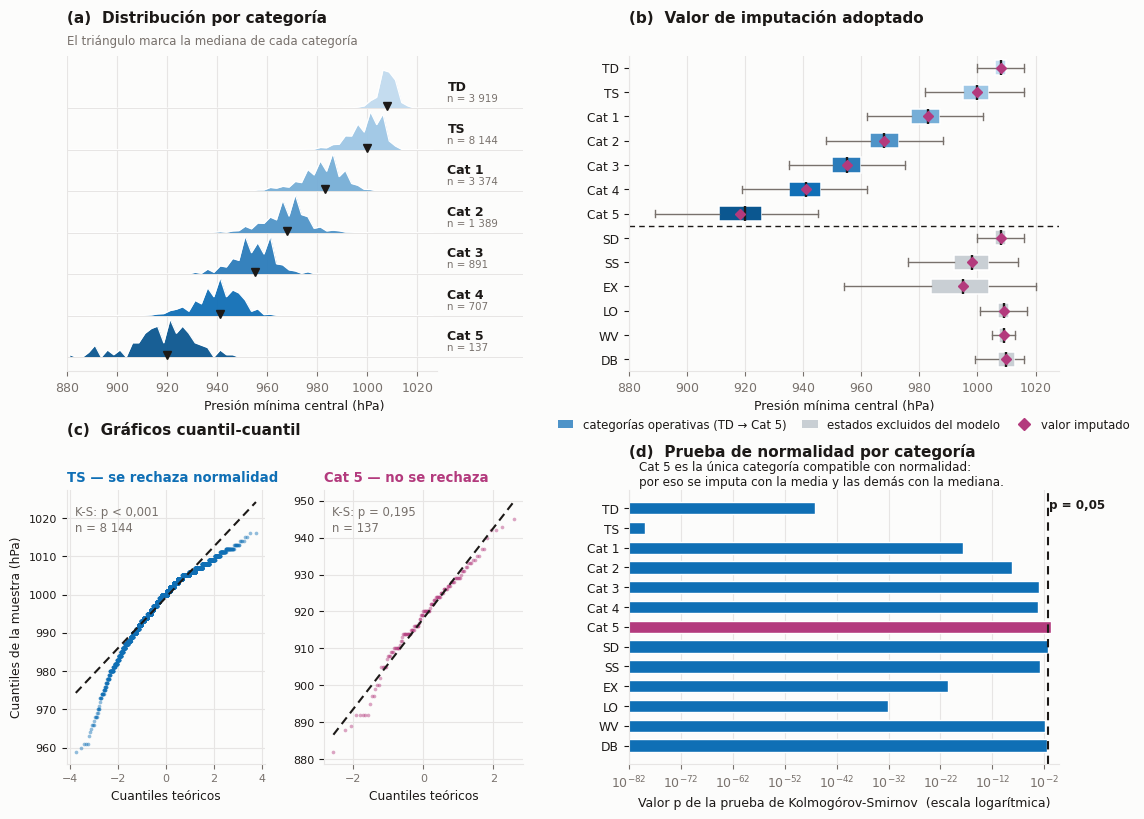

In [124]:
OPER = ["TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
TODAS = OPER + ["SD", "SS", "EX", "LO", "WV", "DB"]
IMPUT = {"TD": 1008.0, "TS": 1000.0, "Cat 1": 983.0, "Cat 2": 968.0, "Cat 3": 955.0,
         "Cat 4": 941.0, "Cat 5": 918.1, "SD": 1008.0, "SS": 998.0, "EX": 995.0,
         "LO": 1009.0, "WV": 1009.0, "DB": 1010.0}

def figura_minpress(d):
    obs = d.dropna(subset=["MinPress", "type_storm"])
    ks = {}
    for cat in TODAS:
        x = obs.loc[obs.type_storm == cat, "MinPress"].values
        if len(x) >= 20:
            ks[cat] = stats.kstest((x - x.mean()) / x.std(ddof=1), "norm")[1]

    fig = plt.figure(figsize=(12.8, 9.2))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], width_ratios=[1.06, 1.0],
                          hspace=0.40, wspace=0.24)

    # (a) histogramas apilados por categoría
    ax = fig.add_subplot(gs[0, 0])
    bins = np.arange(880, 1030, 2.5)
    for i, c in enumerate(OPER):
        x = obs.loc[obs.type_storm == c, "MinPress"].values
        if len(x) == 0:
            continue
        h, e = np.histogram(x, bins=bins, density=True)
        h = h / h.max() * 0.92
        base = (len(OPER) - 1 - i)
        ctr = (e[:-1] + e[1:]) / 2
        col = RAMPA(0.12 + 0.85 * i / (len(OPER) - 1))
        ax.fill_between(ctr, base, base + h, color=col, alpha=0.95, lw=0)
        ax.plot(ctr, base + h, color="white", lw=0.9)
        ax.axhline(base, color=LINEA, lw=0.7)
        ax.text(1032, base + 0.42, c, ha="left", fontsize=9, color=INK, fontweight="bold")
        ax.text(1032, base + 0.16, f"n = {len(x):,}".replace(",", " "),
                ha="left", fontsize=7.4, color=MUTED)
        ax.plot([np.median(x)], [base + 0.05], marker="v", ms=6, color=INK, zorder=5)
    ax.set_yticks([]); ax.set_xlim(880, 1062)
    ax.set_xlabel("Presión mínima central (hPa)")
    ax.set_title("(a)  Distribución por categoría", fontsize=11, fontweight="bold",
                 loc="left", color=INK, pad=24)
    ax.text(0, 1.035, "El triángulo marca la mediana de cada categoría",
            transform=ax.transAxes, fontsize=8.5, color=MUTED)
    ax.set_xticks([880, 900, 920, 940, 960, 980, 1000, 1020])
    ax.grid(axis="x", color=LINEA, lw=0.8); ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False); ax.spines["bottom"].set_bounds(880, 1028)

    # (b) diagramas de caja y valor imputado
    ax2 = fig.add_subplot(gs[0, 1])
    presentes = [c for c in TODAS if (obs.type_storm == c).sum() > 0]
    datos = [obs.loc[obs.type_storm == c, "MinPress"].values for c in presentes]
    bp = ax2.boxplot(datos, vert=False, patch_artist=True, showfliers=False, widths=0.62,
                     medianprops=dict(color=INK, lw=1.7),
                     whiskerprops=dict(color=MUTED, lw=1.0), capprops=dict(color=MUTED, lw=1.0))
    for i, caja in enumerate(bp["boxes"]):
        c = presentes[i]
        col = RAMPA(0.12 + 0.85 * OPER.index(c) / (len(OPER) - 1)) if c in OPER else "#C9CFD4"
        caja.set(facecolor=col, edgecolor="white", lw=1.1)
    for i, c in enumerate(presentes, start=1):
        ax2.plot(IMPUT[c], i, marker="D", ms=5.5, color=MAGENTA, zorder=6)
    ax2.set_yticks(range(1, len(presentes) + 1)); ax2.set_yticklabels(presentes, fontsize=8.8)
    ax2.invert_yaxis(); ax2.set_xlabel("Presión mínima central (hPa)")
    ax2.set_title("(b)  Valor de imputación adoptado", fontsize=11, fontweight="bold",
                  loc="left", color=INK, pad=24)
    ax2.grid(axis="x", color=LINEA, lw=0.8); ax2.set_axisbelow(True)
    ax2.axhline(len(OPER) + 0.5, color=INK, lw=1.0, ls=(0, (4, 3)))
    ax2.legend(handles=[Patch(facecolor=RAMPA(0.55), label="categorías operativas (TD → Cat 5)"),
                        Patch(facecolor="#C9CFD4", label="estados excluidos del modelo"),
                        Line2D([], [], marker="D", ls="", color=MAGENTA, ms=6,
                               label="valor imputado")],
               frameon=False, fontsize=8.4, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, -0.115), handlelength=1.3, columnspacing=1.4)
    ax2.set_xlim(880, 1028)

    # (c) cuantil-cuantil
    sub = gs[1, 0].subgridspec(1, 2, wspace=0.30)
    for k, (cat, titulo) in enumerate([("TS", "TS — se rechaza normalidad"),
                                       ("Cat 5", "Cat 5 — no se rechaza")]):
        axq = fig.add_subplot(sub[k])
        x = obs.loc[obs.type_storm == cat, "MinPress"].values
        (osm, osr), (m, b, r) = stats.probplot(x, dist="norm")
        col = AZUL if cat == "TS" else MAGENTA
        axq.scatter(osm, osr, s=7, color=col, alpha=0.45, lw=0)
        axq.plot(osm, m * osm + b, color=INK, lw=1.5, ls=(0, (4, 2.5)))
        p = ks.get(cat, np.nan)
        txt = "p < 0,001" if p < 1e-3 else f"p = {p:.3f}".replace(".", ",")
        axq.set_title(titulo, fontsize=9.5, fontweight="bold", loc="left", color=col, pad=6)
        axq.text(0.04, 0.94, f"K-S: {txt}\nn = " + f"{len(x):,}".replace(",", " "),
                 transform=axq.transAxes, va="top", fontsize=8.4, color=MUTED, linespacing=1.5)
        axq.set_xlabel("Cuantiles teóricos", fontsize=8.8)
        if k == 0:
            axq.set_ylabel("Cuantiles de la muestra (hPa)", fontsize=8.8)
            axq.text(0, 1.20, "(c)  Gráficos cuantil-cuantil", transform=axq.transAxes,
                     fontsize=11, fontweight="bold", color=INK)
        axq.grid(color=LINEA, lw=0.8); axq.set_axisbelow(True); axq.tick_params(labelsize=8)

    # (d) prueba de Kolmogórov-Smirnov
    ax4 = fig.add_subplot(gs[1, 1])
    cats = [c for c in TODAS if c in ks]
    pv = np.clip(np.array([ks[c] for c in cats]), 1e-80, 1)
    y = np.arange(len(cats))[::-1]
    ax4.barh(y, pv, height=0.62, color=[MAGENTA if p >= 0.05 else AZUL for p in pv],
             edgecolor="white", lw=1.0)
    ax4.set_xscale("log"); ax4.set_xlim(1e-82, 6)
    ax4.axvline(0.05, color=INK, lw=1.5, ls=(0, (4, 3)))
    ax4.text(0.05 * 1.9, len(cats) - 0.5, "p = 0,05", fontsize=8.6, color=INK,
             fontweight="bold", va="top")
    ax4.set_yticks(y); ax4.set_yticklabels(cats, fontsize=8.8)
    ax4.set_xlabel("Valor p de la prueba de Kolmogórov-Smirnov  (escala logarítmica)")
    ax4.set_title("(d)  Prueba de normalidad por categoría", fontsize=11, fontweight="bold",
                  loc="left", color=INK, pad=24)
    ax4.grid(axis="x", color=LINEA, lw=0.8); ax4.set_axisbelow(True)
    ax4.text(1e-80, len(cats) - 0.02,
             "Cat 5 es la única categoría compatible con normalidad:\n"
             "por eso se imputa con la media y las demás con la mediana.",
             fontsize=8.6, color=INK, va="bottom")
    plt.show()

figura_minpress(df_ETL)

Sabiendo entonces que la distribución de los datos de MinPress no sigue una distribucion en normal en niguna de las categorias. Procedemos a usar la MEDIANA de cada categoria para imputar en los valores faltantes de MinPress. 

La categoria 5, sigue una distribución normal según el valor P del test K-S 

## 3.4 Exploración de las variables ambientales del esquema SHIPS

El esquema SHIPS aporta diagnósticos del entorno en el que se mueve cada sistema: cizalladura vertical del viento, temperatura superficial del mar, humedad relativa de la capa media, contenido de calor oceánico, y rumbo y velocidad de traslación. Se exploran aquí sobre el fichero de origen, antes de unirlos al registro de trayectorias, para conocer su cobertura y su estructura interna.

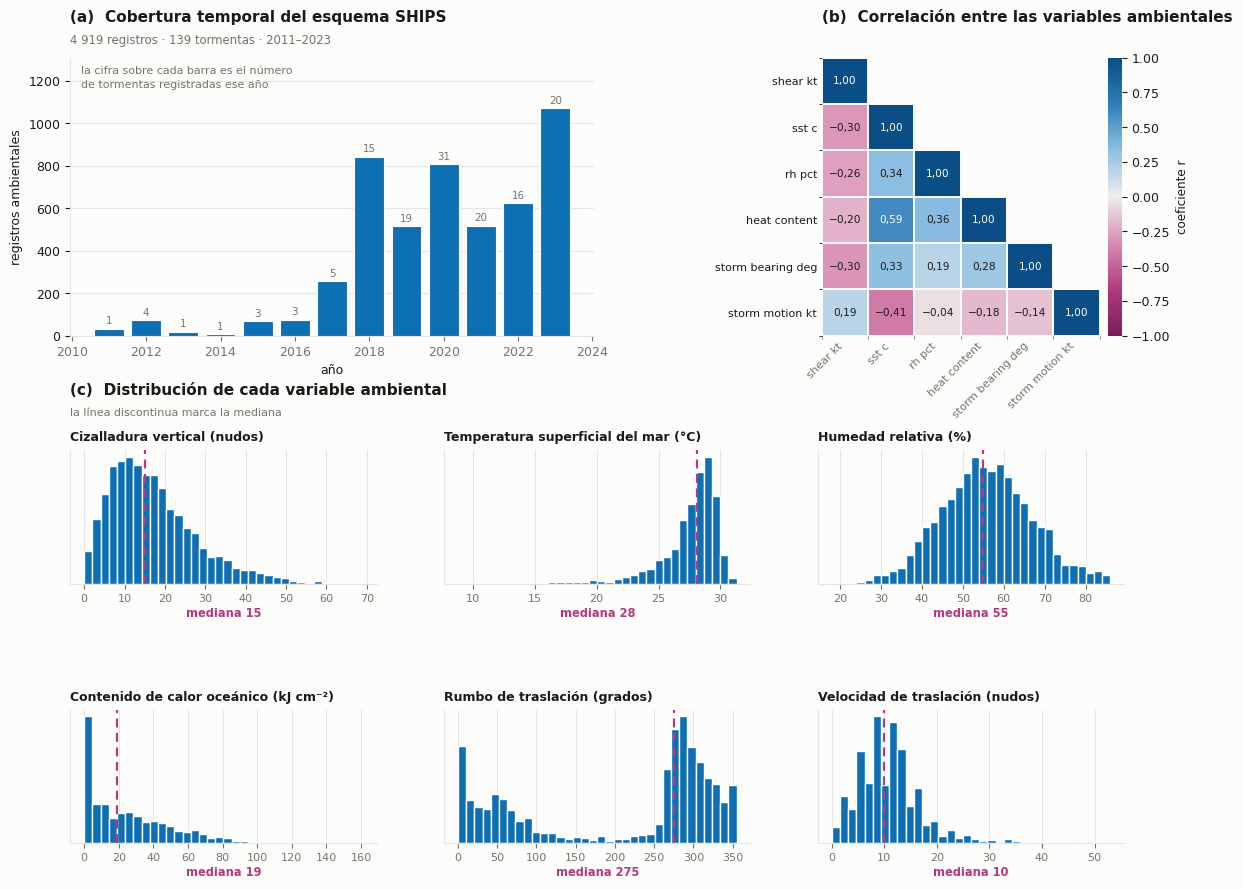

In [125]:
# Ruta del fichero de SHIPS: la misma que se usa más adelante al unirlo
RUTA_SHIPS = "datos/ships_filter.csv"
sh_eda = pd.read_csv(RUTA_SHIPS, sep=";")

VARS_SHIPS = ["shear_kt", "sst_c", "rh_pct", "heat_content",
              "storm_bearing_deg", "storm_motion_kt"]
ETIQ_SHIPS = {"shear_kt": "Cizalladura vertical\n(nudos)",
              "sst_c": "Temperatura superficial\ndel mar (°C)",
              "rh_pct": "Humedad relativa\n(%)",
              "heat_content": "Contenido de calor\noceánico (kJ cm⁻²)",
              "storm_bearing_deg": "Rumbo de traslación\n(grados)",
              "storm_motion_kt": "Velocidad de traslación\n(nudos)"}
DIV = LinearSegmentedColormap.from_list(
    "div", ["#7A1F55", "#B33A7D", "#D98CB4", "#EDEDEC", "#8FC0E2", "#2F7EBB", "#0A4E85"])


def figura_ships(sh):
    sh = sh.copy()
    sh["anio"] = sh["storm_code"].str[-4:].astype(int)

    fig = plt.figure(figsize=(13.6, 10.2))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.28, 1.0],
                          height_ratios=[1.0, 0.50, 0.50], wspace=0.26, hspace=0.62)

    # (a) cobertura temporal
    ax = fig.add_subplot(gs[0, 0])
    cob = sh.groupby("anio").agg(tormentas=("storm_code", "nunique"),
                                 registros=("storm_code", "size"))
    ax.bar(cob.index, cob.registros, color=AZUL, edgecolor="white", lw=0.8, zorder=3)
    ax.set_xlabel("año"); ax.set_ylabel("registros ambientales")
    ax.set_title("(a)  Cobertura temporal del esquema SHIPS", fontsize=11,
                 fontweight="bold", loc="left", color=INK, pad=26)
    ax.text(0, 1.05, f"{len(sh):,}".replace(",", " ") +
            f" registros · {sh.storm_code.nunique()} tormentas · "
            f"{cob.index.min()}–{cob.index.max()}",
            transform=ax.transAxes, fontsize=8.4, color=MUTED)
    ax.grid(axis="y", color=LINEA, lw=0.8); ax.set_axisbelow(True)
    ax.set_ylim(0, cob.registros.max() * 1.22)
    for a in cob.index:
        ax.text(a, cob.registros[a] + cob.registros.max() * 0.02, str(cob.tormentas[a]),
                ha="center", fontsize=7.4, color=MUTED)
    ax.text(0.02, 0.97, "la cifra sobre cada barra es el número\n"
            "de tormentas registradas ese año",
            transform=ax.transAxes, ha="left", va="top", fontsize=8, color=MUTED,
            linespacing=1.5)

    # (b) correlación entre variables ambientales
    ax2 = fig.add_subplot(gs[0, 1])
    M = sh[VARS_SHIPS].corr()
    mask = np.triu(np.ones_like(M, dtype=bool), k=1)
    im = ax2.imshow(np.ma.masked_where(mask, M.values), cmap=DIV, vmin=-1, vmax=1)
    for i in range(len(VARS_SHIPS)):
        for j in range(i + 1):
            v = M.values[i, j]
            ax2.text(j, i, f"{v:.2f}".replace("-", "−").replace(".", ","),
                     ha="center", va="center", fontsize=7.6,
                     color="white" if abs(v) > 0.55 else INK)
    et = [v.replace("_", " ") for v in VARS_SHIPS]
    ax2.set_xticks(range(len(et))); ax2.set_yticks(range(len(et)))
    ax2.set_xticklabels(et, rotation=45, ha="right", fontsize=8)
    ax2.set_yticklabels(et, fontsize=8)
    ax2.set_title("(b)  Correlación entre las variables ambientales",
                  fontsize=11, fontweight="bold", loc="left", color=INK, pad=26)
    ax2.spines[:].set_visible(False); ax2.tick_params(length=0)
    ax2.set_xticks(np.arange(-.5, len(et), 1), minor=True)
    ax2.set_yticks(np.arange(-.5, len(et), 1), minor=True)
    ax2.grid(which="minor", color=SURF, lw=1.4)
    cb = fig.colorbar(im, ax=ax2, fraction=0.040, pad=0.02)
    cb.set_label("coeficiente r", fontsize=8.6); cb.outline.set_visible(False)

    # (c) distribución de cada variable
    sub = gs[1:, :].subgridspec(2, 3, wspace=0.22, hspace=0.95)
    for k, v in enumerate(VARS_SHIPS):
        a = fig.add_subplot(sub[k // 3, k % 3])
        x = sh[v].dropna()
        a.hist(x, bins=34, color=AZUL, edgecolor="white", lw=0.4)
        a.axvline(x.median(), color=MAGENTA, lw=1.6, ls=(0, (4, 2.5)))
        a.set_title(ETIQ_SHIPS[v].replace("\n", " "), fontsize=9, fontweight="bold",
                    loc="left", color=INK, pad=7)
        a.tick_params(labelsize=8); a.set_yticks([])
        a.set_xlabel(f"mediana {x.median():.0f}", fontsize=8.2, color=MAGENTA,
                     fontweight="bold", labelpad=3)
        a.grid(axis="x", color=LINEA, lw=0.7); a.set_axisbelow(True)
        if k == 0:
            a.text(0, 1.42, "(c)  Distribución de cada variable ambiental",
                   transform=a.transAxes, fontsize=11, fontweight="bold", color=INK)
            a.text(0, 1.26, "la línea discontinua marca la mediana",
                   transform=a.transAxes, fontsize=8, color=MUTED)
    plt.show()


figura_ships(sh_eda)

Tres cosas quedan a la vista.

**La cobertura es corta.** El esquema solo cubre los años más recientes, y con muy pocos registros en los primeros. Exigir estas variables restringe el conjunto de modelado a ese período.

**Las variables ambientales están poco correlacionadas entre sí.** La asociación más fuerte se da entre la temperatura del mar y el contenido de calor oceánico, que miden aspectos relacionados del mismo reservorio energético. El resto aporta información en buena medida independiente.

**El entorno tiene una estructura latitudinal clara.** Al alejarse del trópico el mar se enfría y la cizalladura aumenta, que son las dos condiciones que inhiben la intensificación. Esto anticipa que parte de lo que aportan estas variables podría estar ya contenido en la latitud, cuestión que se retoma en el análisis de colinealidad.

## 3.5 Exploración del índice de la Oscilación del Atlántico Norte

La NAO describe el contraste de presión entre el anticiclón de las Azores y la baja de Islandia. Su fase modula la posición e intensidad del anticiclón subtropical, que es el principal rector del flujo de conducción de los ciclones en el Atlántico. Es la única variable del conjunto que describe el estado de la circulación de gran escala y no el estado del propio sistema.

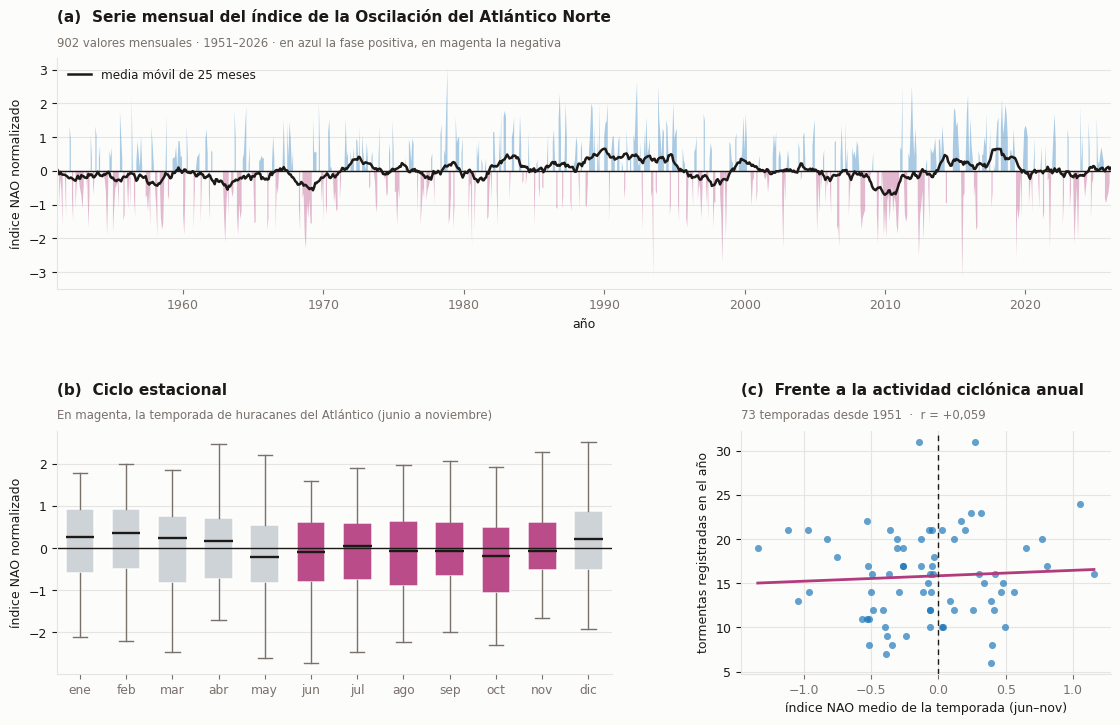

In [126]:
# Ruta del fichero de la NAO: la misma que se usa más adelante al unirlo
RUTA_NAO = "datos/norm_nao_monthly_b5001_current_ascii.txt"
df_nao_eda = pd.read_csv(RUTA_NAO, sep=r"\s+", skiprows=2, header=None,
                         names=["year"] + [f"m{k}" for k in range(1, 13)])
nao_largo = df_nao_eda.melt(id_vars=["year"], var_name="_mk", value_name="nao")
nao_largo["month"] = nao_largo["_mk"].str.replace("m", "", regex=False).astype(int)
nao_largo["nao"] = pd.to_numeric(nao_largo["nao"], errors="coerce")
nao_largo.loc[nao_largo["nao"] <= -900, "nao"] = np.nan

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
TEMPORADA = [6, 7, 8, 9, 10, 11]

def figura_nao(nao_largo, d):
    fig = plt.figure(figsize=(13.6, 8.0))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1.0], height_ratios=[1.0, 1.05],
                          wspace=0.28, hspace=0.60)

    # (a) serie mensual
    ax = fig.add_subplot(gs[0, :])
    s = nao_largo.dropna(subset=["nao"]).sort_values(["year", "month"])
    t = s.year + (s.month - 1) / 12
    ax.axhline(0, color=INK, lw=1.0)
    ax.fill_between(t, 0, s.nao, where=s.nao >= 0, color=AZUL, alpha=0.35, lw=0)
    ax.fill_between(t, 0, s.nao, where=s.nao < 0, color=MAGENTA, alpha=0.35, lw=0)
    suave = s.nao.rolling(25, center=True, min_periods=13).mean()
    ax.plot(t, suave, color=INK, lw=1.8, label="media móvil de 25 meses")
    ax.set_xlim(t.min(), t.max()); ax.set_xlabel("año"); ax.set_ylabel("índice NAO normalizado")
    ax.set_title("(a)  Serie mensual del índice de la Oscilación del Atlántico Norte",
                 fontsize=11, fontweight="bold", loc="left", color=INK, pad=26)
    ax.text(0, 1.05, f"{len(s):,}".replace(",", " ") +
            f" valores mensuales · {int(s.year.min())}–{int(s.year.max())} · "
            "en azul la fase positiva, en magenta la negativa",
            transform=ax.transAxes, fontsize=8.4, color=MUTED)
    ax.legend(frameon=False, fontsize=8.6, loc="upper left")
    ax.grid(axis="y", color=LINEA, lw=0.8); ax.set_axisbelow(True)

    # (b) ciclo estacional
    ax2 = fig.add_subplot(gs[1, 0])
    datos = [nao_largo.loc[nao_largo.month == m, "nao"].dropna().values for m in range(1, 13)]
    bp = ax2.boxplot(datos, patch_artist=True, showfliers=False, widths=0.62,
                     medianprops=dict(color=INK, lw=1.7),
                     whiskerprops=dict(color=MUTED, lw=1.0), capprops=dict(color=MUTED, lw=1.0))
    for i, caja in enumerate(bp["boxes"], start=1):
        caja.set(facecolor=MAGENTA if i in TEMPORADA else "#C9CFD4",
                 edgecolor="white", lw=1.1, alpha=0.9)
    ax2.axhline(0, color=INK, lw=1.0)
    ax2.set_xticks(range(1, 13)); ax2.set_xticklabels(MESES, fontsize=8.8)
    ax2.set_ylabel("índice NAO normalizado")
    ax2.set_title("(b)  Ciclo estacional", fontsize=11, fontweight="bold",
                  loc="left", color=INK, pad=26)
    ax2.text(0, 1.05, "En magenta, la temporada de huracanes del Atlántico (junio a noviembre)",
             transform=ax2.transAxes, fontsize=8.4, color=MUTED)
    ax2.grid(axis="y", color=LINEA, lw=0.8); ax2.set_axisbelow(True)

    # (c) NAO de temporada frente a la actividad ciclónica del año
    ax3 = fig.add_subplot(gs[1, 1])
    temporada = (nao_largo[nao_largo.month.isin(TEMPORADA)]
                 .groupby("year")["nao"].mean().rename("nao_temporada"))
    actividad = d.groupby("year")["Code_storm"].nunique().rename("tormentas")
    j = pd.concat([temporada, actividad], axis=1).dropna()
    j = j[j.index >= 1950]
    ax3.scatter(j.nao_temporada, j.tormentas, s=26, color=AZUL, alpha=0.65, lw=0)
    b, a = np.polyfit(j.nao_temporada, j.tormentas, 1)
    xx = np.linspace(j.nao_temporada.min(), j.nao_temporada.max(), 50)
    r = np.corrcoef(j.nao_temporada, j.tormentas)[0, 1]
    ax3.plot(xx, a + b * xx, color=MAGENTA, lw=2.0)
    ax3.axvline(0, color=INK, lw=1.0, ls=(0, (4, 3)))
    ax3.set_xlabel("índice NAO medio de la temporada (jun–nov)")
    ax3.set_ylabel("tormentas registradas en el año")
    ax3.set_title("(c)  Frente a la actividad ciclónica anual", fontsize=11,
                  fontweight="bold", loc="left", color=INK, pad=26)
    ax3.text(0, 1.05, (f"{len(j)} temporadas desde {int(j.index.min())}  ·  "
                       f"r = {r:+.3f}").replace(".", ","),
             transform=ax3.transAxes, fontsize=8.4, color=MUTED)
    ax3.grid(color=LINEA, lw=0.8); ax3.set_axisbelow(True)
    plt.show()

figura_nao(nao_largo, df_ETL)

El índice oscila en torno a cero sin tendencia marcada, con episodios persistentes de una y otra fase que duran varios años. Su variabilidad es menor durante la temporada de huracanes que en invierno, que es cuando el patrón alcanza su máxima amplitud.

La relación con el número de tormentas del año es prácticamente nula. Eso **no** descarta la variable: la influencia documentada de la NAO no opera sobre cuántos sistemas se forman, sino sobre por dónde circulan, al desplazar el anticiclón subtropical y con él el flujo que los conduce. Por esa razón se incorpora al nivel de cada observación y no como resumen de temporada.

# 4. IMPUTACIONES

## 4.0 Ventana temporal de trabajo

El registro de HURDAT2 arranca en 1851, pero la presión central no se midió de forma sistemática hasta bien entrado el siglo XX. La sección 3.1 ya mostró el patrón; en cifras, la presión falta en más del 94 % de los registros anteriores a 1950 y en el 74,6 % de los de 1950-1969.

Conservar esos años obligaría a imputar la variable objetivo del modelo de intensidad en la mayor parte de la muestra, que es fabricar precisamente el dato que se quiere predecir. Además, las posiciones anteriores a la era del satélite se reconstruyeron a partir de avistamientos y reportes de barcos, con una precisión que no es comparable a la del registro moderno, de modo que también la trayectoria arrastraría un error de medición mucho mayor.

El trabajo se restringe por tanto a **1970 en adelante**. La constante `ANIO_INICIO` deja el criterio en un solo lugar por si conviene revisarlo: llevarlo a 1990 dejaría la presión prácticamente completa, a costa de la mitad de las tormentas restantes.

El recorte se aplica aquí, antes de imputar, para que las medianas por tipo de tormenta se calculen sobre el período de trabajo y no sobre un registro histórico que no se va a usar.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  4.0 Ventana temporal de trabajo
# ══════════════════════════════════════════════════════════════════════════
# El registro de HURDAT2 arranca en 1851, pero la presión central no se midió de
# forma sistemática hasta bien entrado el siglo XX: antes de 1950 falta en más
# del 94 % de los registros. Conservar esos años obligaría a imputar la variable
# objetivo del modelo de intensidad en la mayor parte de la muestra, que es
# fabricar el dato que se quiere predecir.
ANIO_INICIO = 1970

antes = {"filas": len(df_EDA), "tormentas": df_EDA.Code_storm.nunique(),
         "falta_minpress": df_EDA.MinPress.isna().mean()}

print("presión central ausente por período, antes de recortar:")
for lo in range(1850, 2030, 20):
    s = df_EDA[(df_EDA.year >= lo) & (df_EDA.year < lo + 20)]
    if len(s):
        print(f"   {lo}-{lo+19}: {len(s):6d} filas · ausente {s.MinPress.isna().mean()*100:5.1f} %")

df_EDA = df_EDA[df_EDA["year"] >= ANIO_INICIO].reset_index(drop=True)

print(f"\nrecorte en {ANIO_INICIO}")
print(f"   antes:   {antes['filas']:6d} filas · {antes['tormentas']:5d} tormentas · "
      f"presión ausente {antes['falta_minpress']*100:.1f} %")
print(f"   después: {len(df_EDA):6d} filas · {df_EDA.Code_storm.nunique():5d} tormentas · "
      f"presión ausente {df_EDA.MinPress.isna().mean()*100:.1f} %")
print(f"   se retira el {100*(1-len(df_EDA)/antes['filas']):.1f} % de las filas y el "
      f"{100*(1-df_EDA.Code_storm.nunique()/antes['tormentas']):.1f} % de las tormentas")
print("\nEl recorte reduce la imputación de la presión de más de la mitad de la muestra")
print("a una fracción pequeña, y esa fracción se concentra en los años setenta y ochenta.")

## 4.0.1 Imputacion presion minima

In [127]:
# Ver valores faltantes antes de imputar
print("Valores faltantes antes de imputar:")
print(df_EDA['MinPress'].isnull().sum())

# Diccionario con las medianas por tipo de tormenta
medianas_por_tipo = {
    'Cat 1': 983.0,
    'Cat 2': 968.0,
    'Cat 3': 955.0,
    'Cat 4': 941.0,
    'Cat 5': 918.1, # Para esta categoria se usa el promedio y no la mediana.
    'DB': 1010.0,
    'EX': 995.0,
    'LO': 1009.0,
    'SD': 1008.0,
    'SS': 998.0,
    'TD': 1008.0,
    'TS': 1000.0,
    'WV': 1009.0
}

# Imputar directamente en la variable MinPress
df_EDA['MinPress'] = df_EDA['MinPress'].fillna(df_EDA['type_storm'].map(medianas_por_tipo))

# Verificar valores faltantes después de imputar
print(f"\nValores faltantes después de imputar: {df_EDA['MinPress'].isnull().sum()}")

# Mostrar filas que aún tienen valores faltantes
filas_con_nan = df_EDA[df_EDA['MinPress'].isnull()]
print(f"\nFilas que quedaron con valores faltantes después de imputar:")
print(f"Total de filas con NaN: {len(filas_con_nan)}")

if len(filas_con_nan) > 0:
    print("\nDetalle de las filas con valores faltantes:")
    print(filas_con_nan[['type_storm', 'MinPress']].head(20))
else:
    print("No quedaron valores faltantes después de la imputación.")

Valores faltantes antes de imputar:
30946

Valores faltantes después de imputar: 0

Filas que quedaron con valores faltantes después de imputar:
Total de filas con NaN: 0
No quedaron valores faltantes después de la imputación.


## 4.0 Longitud negativa

In [128]:
df_EDA["Lon_W"] = -df_EDA["Lon_W"]

## 4.1 Cálculo de vector de longitud

In [129]:
# Crear columnas para vectores
df_EDA["vec_x"] = np.nan
df_EDA["vec_y"] = np.nan

# Diccionario para almacenar vectores
vecs = {"vec_x": [], "vec_y": [], "id": []}

# Procesar cada tormenta por separado
for storm_id in df_EDA["Code_storm"].unique():
    # Filtrar datos de la tormenta y ordenar por fecha
    storm_data = df_EDA[df_EDA["Code_storm"] == storm_id].copy()
    storm_data = storm_data.sort_values(['year', 'month', 'day', 'hour']).reset_index()
    
    # Inicializar variables
    last_x = None
    last_y = None
    
    # Calcular vectores para cada punto de la tormenta
    for i, row in storm_data.iterrows():
        current_x = row["Lon_W"]
        current_y = row["Lat_N"]
        
        # Si no es el primer punto, calcular vector
        if last_x is not None and last_y is not None:
            vec_x = current_x - last_x
            vec_y = current_y - last_y
            
            # Guardar vector y índice original
            vecs["vec_x"].append(vec_x)
            vecs["vec_y"].append(vec_y)
            vecs["id"].append(row["index"])  # Índice original en df
        
        # Actualizar coordenadas para siguiente iteración
        last_x = current_x
        last_y = current_y

# Asignar vectores al DataFrame original
df_EDA.loc[vecs["id"], "vec_x"] = vecs["vec_x"]
df_EDA.loc[vecs["id"], "vec_y"] = vecs["vec_y"]

Manejado la ecuación de calculo de un vector a partir de grados decimales. 

* Vector_Longitud = ((vec_x)"2 + (vec_y)"2)"-2

In [130]:
df_EDA["vec_len"] = np.sqrt((df_EDA["vec_x"]**2)+(df_EDA["vec_y"]**2))

Hubo valores de 354 a 356 de vec_len que no permitía graficar un buen histograma, así que eliminamos la ficha que corresponde a ese valor de 356. Sucedió porque se registró una tormenta en dos punto muy distantes y en las etapas finales de la tormenta cuando sale de la zona de los trópicos y gana mas velocidad

In [131]:
# Ver cuántos se eliminarán
print(f"Filas a eliminar: {(df_EDA['vec_len'] >= 354).sum()}")

# Eliminar
df_EDA = df_EDA[df_EDA["vec_len"] < 354]

Filas a eliminar: 4


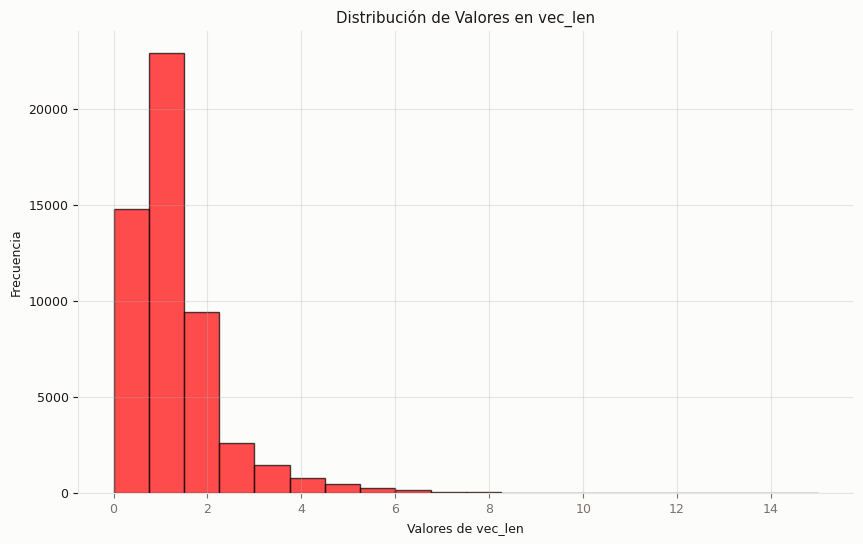

In [132]:
# Histograma de valores mayores a 5.5
plt.figure(figsize=(10, 6))
plt.hist(df_EDA['vec_len'], bins=20, alpha=0.7, color='red', edgecolor='black')
plt.title('Distribución de Valores en vec_len')
plt.xlabel('Valores de vec_len')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

## 4.2 Calculo de la dirección de la tormenta

La ecuación usada para el cálculo de la dirección es:

* Dirección = Arctg( vector_x / vector_y)

In [133]:
def calculate_direction(vec_x, vec_y):
    # atan2 devuelve el ángulo en radianes en el rango [-π, π]
    # (x, y) para que 0 rad apunte al norte
    #return np.arctan2(vec_y, -vec_x)
    
    # (x, y) para que 0 rad apunte al este
    return np.arctan2(vec_x, vec_y)


# Aplicar al DataFrame
df_EDA["vec_direction"] = df_EDA.apply(lambda x: calculate_direction(x.vec_x, x.vec_y), axis=1)

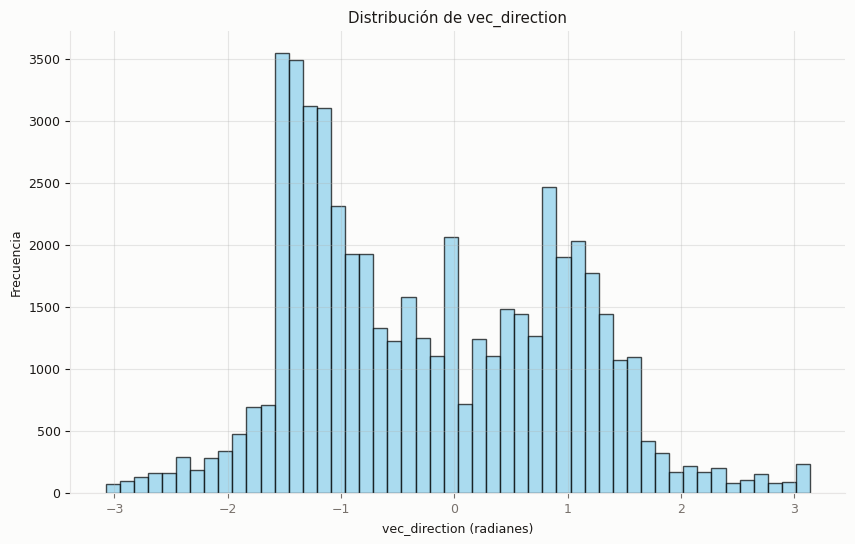

In [134]:
# Histograma de vec_direction
plt.figure(figsize=(10, 6))
plt.hist(df_EDA["vec_direction"], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.title("Distribución de vec_direction")
plt.xlabel("vec_direction (radianes)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

## 4.3 UNIR DATOS SHIPS (CONDICIONES FÍSICAS DEL AMBIENTE) A LOS DATOS HURDAT (TRACKS DE HURACANES)

SHIPS la calcula como la magnitud de la diferencia vectorial del viento entre 850 y 200 hPa, promediada en un radio de 0 a 500 km del centro, en nudos. Es el predictor SHRD del esquema. Los 850 hPa quedan cerca de la cima de la capa límite y los 200 hPa cerca de la tropopausa, así que mide el cizallamiento de toda la troposfera. Puse esa descripción en el título del panel.

In [135]:
#df_ships = pd.read_csv("/Users/mauriciohurtado/modelo_clasificacion/datos_ships/datos_ships.csv")

df_ships = pd.read_csv("datos/ships_filter.csv", sep= ';')

In [136]:
print("Columnas numéricas:")
print(df_ships.select_dtypes(include=['float64', 'int64']).columns.tolist())
print("\nColumnas de texto:")
print(df_ships.select_dtypes(include=['object']).columns.tolist())

Columnas numéricas:
['Unnamed: 0', 'shear_kt', 'sst_c', 'rh_pct', 'heat_content', 'storm_bearing_deg', 'storm_motion_kt', 'lat_hurdat2', 'lon_hurdat2', 'lat_s', 'lon_s']

Columnas de texto:
['storm_code']


In [137]:
print("Columnas numéricas:")
print(df_EDA.select_dtypes(include=['float64', 'int64']).columns.tolist())
print("\nColumnas de texto:")
print(df_EDA.select_dtypes(include=['object']).columns.tolist())

Columnas numéricas:
['hour', 'Max_wind', 'MinPress', 'NE34', 'SE34', 'SW34', 'NW34', 'NE50', 'SE50', 'SW50', 'NW50', 'NE64', 'SE64', 'SW64', 'NW64', 'Lat_N', 'Lon_W', 'type_storm_n', 'vec_x', 'vec_y', 'vec_len', 'vec_direction']

Columnas de texto:
['Code_storm', 'Name_storm', 'type_storm']


In [138]:
# filtrar el df_ships con las columnas a usar
ships_filter = df_ships[['storm_code', 'shear_kt', 'sst_c', 'rh_pct', 'heat_content', 'storm_bearing_deg', 'storm_motion_kt', 'lat_hurdat2', 'lon_hurdat2', 'lat_s', 'lon_s']]

In [139]:
print("Columnas numéricas:")
print(ships_filter.select_dtypes(include=['float64', 'int64']).columns.tolist())
print("\nColumnas de texto:")
print(ships_filter.select_dtypes(include=['object']).columns.tolist())

Columnas numéricas:
['shear_kt', 'sst_c', 'rh_pct', 'heat_content', 'storm_bearing_deg', 'storm_motion_kt', 'lat_hurdat2', 'lon_hurdat2', 'lat_s', 'lon_s']

Columnas de texto:
['storm_code']


In [140]:
# ===============================
# 1. Copias de seguridad
# ===============================
df1 = df_EDA.copy()         # df principal
df2 = ships_filter.copy()   # df con variables adicionales


# ===============================
# 2. Renombrar columnas equivalentes
# ===============================
df2 = df2.rename(columns={
    'storm_code': 'Code_storm',
    'lat_hurdat2': 'Lat_N',
    'lon_hurdat2': 'Lon_W'
})


# ===============================
# 3. Columnas que sirven como llave
# ===============================
columnas_llave = ['Code_storm', 'Lat_N', 'Lon_W']


# ===============================
# 4. Columnas numéricas y de texto
#    que quieres traer desde ships_filter
# ===============================

columnas_ships_numericas = [
    'shear_kt', 
    'sst_c', 
    'rh_pct', 
    'heat_content', 
    'storm_bearing_deg',
    'storm_motion_kt',
    'lat_s',
    'lon_s'
]

columnas_ships_texto = [
    # storm_code ya se renombró → Code_storm
    # agrega otras columnas de texto si existen
]

columnas_ships_agregar = columnas_ships_numericas + columnas_ships_texto


# ===============================
# 5. Unir los dataframes
# ===============================
df_combinado = df1.merge(
    df2[columnas_llave + columnas_ships_agregar],
    on=columnas_llave,
    how='left'
)


# ===============================
# 6. Mostrar información final
# ===============================
print("\nColumnas nuevas incorporadas:")
for col in columnas_ships_agregar:
    print(" -", col)

print(f"\nFilas de df_EDA: {len(df_EDA)}")
print(f"Filas de resultado: {len(df_combinado)}")

# Validar coincidencias
coincidencias = df_combinado['shear_kt'].notnull().sum()
print(f"\nCoincidencias encontradas: {coincidencias}")


# ===============================
# 7. df final listo
# ===============================
df_combinado


Columnas nuevas incorporadas:
 - shear_kt
 - sst_c
 - rh_pct
 - heat_content
 - storm_bearing_deg
 - storm_motion_kt
 - lat_s
 - lon_s

Filas de df_EDA: 52770
Filas de resultado: 52776

Coincidencias encontradas: 3013


,Code_storm,Name_storm,year,month,day,hour,type_storm,Max_wind,MinPress,NE34,...,vec_len,vec_direction,shear_kt,sst_c,rh_pct,heat_content,storm_bearing_deg,storm_motion_kt,lat_s,lon_s
0,AL011851,UNNAMED,1851,6,25,6,Cat 1,80.0,983.0,NaN,...,0.600000,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL011851,UNNAMED,1851,6,25,12,Cat 1,80.0,983.0,NaN,...,0.600000,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL011851,UNNAMED,1851,6,25,18,Cat 1,80.0,983.0,NaN,...,0.509902,-1.373401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL011851,UNNAMED,1851,6,25,21,Cat 1,80.0,983.0,NaN,...,0.316228,-1.249046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL011851,UNNAMED,1851,6,26,0,Cat 1,70.0,983.0,NaN,...,0.200000,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52771,AL212023,TWENTY-ONE,2023,10,23,18,TD,25.0,1007.0,0.0,...,0.608276,-1.405648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52772,AL212023,TWENTY-ONE,2023,10,24,0,TD,25.0,1007.0,0.0,...,0.728011,-0.278300,4.0,29.4,76.0,28.0,305.0,5.0,12.2,-83.3
52773,AL212023,TWENTY-ONE,2023,10,24,1,TD,25.0,1007.0,0.0,...,0.223607,-0.463648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52774,AL212023,TWENTY-ONE,2023,10,24,6,TD,25.0,1007.0,0.0,...,0.670820,-0.463648,5.0,29.9,77.0,40.0,335.0,7.0,13.0,-83.8


In [141]:
df_EDA = df_combinado.copy()

In [142]:
df_EDA.head(3)

,Code_storm,Name_storm,year,month,day,hour,type_storm,Max_wind,MinPress,NE34,...,vec_len,vec_direction,shear_kt,sst_c,rh_pct,heat_content,storm_bearing_deg,storm_motion_kt,lat_s,lon_s
0,AL011851,UNNAMED,1851,6,25,6,Cat 1,80.0,983.0,NaN,...,0.600000,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL011851,UNNAMED,1851,6,25,12,Cat 1,80.0,983.0,NaN,...,0.600000,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL011851,UNNAMED,1851,6,25,18,Cat 1,80.0,983.0,NaN,...,0.509902,-1.373401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.3.1 Tamaño y asimetría del campo de viento

Los doce radios no son doce variables independientes: son cuatro cuadrantes por cada uno de los tres umbrales, y los cuatro cuadrantes de un mismo umbral describen un solo contorno. Un contorno tiene dos propiedades independientes —cuánto se extiende y cuánto se aparta de la simetría—, de modo que describirlo con cuatro números repite información: la correlación media entre cuadrantes del mismo umbral es de 0,73 a 0,75, y ningún par alcanza el umbral de 0,90 que definiría una redundancia evidente, así que la depuración por VIF acaba retirando cuadrantes sueltos sin una lógica interpretable.

Se sustituyen por dos variables derivadas por umbral:

- **`radio_medio_u`** — promedio de los cuatro cuadrantes, en millas náuticas. Es el tamaño del campo de viento de *u* nudos.
- **`asimetria_u`** — magnitud del vector (NE−SO, NO−SE) dividida por la suma de los cuatro radios. Adimensional, entre 0 y 1: vale 0 en un campo perfectamente circular y 1 cuando toda la extensión se concentra en un solo cuadrante. La división por la suma la hace independiente del tamaño, de modo que un sistema grande no aparece automáticamente como más asimétrico que uno pequeño.

Se añade además **`cuadrantes_u`**, que registra cuántos cuadrantes alcanzan el umbral. No es un predictor: sirve para detectar los campos parciales, en los que la asimetría se dispara por construcción, y se emplea en el EDA posterior a la imputación.

Cuando el sistema no alcanza el umbral los cuatro radios valen cero y la asimetría queda indefinida; se fija en cero, porque `radio_medio_u = 0` ya informa de que no hay campo y la pareja (0, 0) no es ambigua. Mantenerla como ausente costaría cerca del 70 % de los registros al exigir los tres umbrales a la vez.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  4.3.1  Tamaño y asimetría del campo de viento
# ══════════════════════════════════════════════════════════════════════════
# Los doce radios son cuatro cuadrantes por cada uno de los tres umbrales, y
# los cuatro cuadrantes de un mismo umbral describen un solo contorno. Un
# contorno tiene dos propiedades independientes —cuánto se extiende y cuánto
# se desvía de la simetría— de modo que cuatro números para describirlo
# repiten información: la correlación media entre cuadrantes del mismo umbral
# es de 0,73 a 0,75.
#
#   radio_medio_u : promedio de los cuatro cuadrantes, en millas náuticas.
#                   Es el tamaño del campo de viento de u nudos.
#   asimetria_u   : magnitud del vector (NE−SO, NO−SE) dividida por la suma de
#                   los cuatro radios. Adimensional, entre 0 y 1. Vale 0 en un
#                   campo perfectamente circular y 1 cuando toda la extensión
#                   se concentra en un solo cuadrante. La división por la suma
#                   la hace independiente del tamaño.
#   cuadrantes_u  : cuántos de los cuatro cuadrantes alcanzan el umbral. No es
#                   un predictor: sirve para detectar los campos parciales, en
#                   los que la asimetría se dispara por construcción.

UMBRALES = [34, 50, 64]
CUADRANTES = ["NE", "SE", "SW", "NW"]

for u in UMBRALES:
    q = [f"{c}{u}" for c in CUADRANTES]
    completo = df_EDA[q].notna().all(axis=1)
    suma = df_EDA[q].sum(axis=1, min_count=4)

    df_EDA[f"radio_medio_{u}"] = df_EDA[q].mean(axis=1).where(completo)

    eje_ne_so = df_EDA[f"NE{u}"] - df_EDA[f"SW{u}"]
    eje_no_se = df_EDA[f"NW{u}"] - df_EDA[f"SE{u}"]
    # Cuando el sistema no alcanza el umbral los cuatro radios valen 0 y la
    # asimetría es indefinida: se fija en 0, porque `radio_medio_u = 0` ya
    # informa de que no hay campo y la pareja (0, 0) no es ambigua. Mantenerla
    # como ausente costaría el 70 % de los registros al exigir los tres umbrales.
    df_EDA[f"asimetria_{u}"] = np.where(
        suma > 0, np.hypot(eje_ne_so, eje_no_se) / suma.replace(0, np.nan), 0.0)
    df_EDA[f"asimetria_{u}"] = df_EDA[f"asimetria_{u}"].where(completo)

    df_EDA[f"cuadrantes_{u}"] = (df_EDA[q] > 0).sum(axis=1).where(completo)

COLS_DERIVADAS = ([f"radio_medio_{u}" for u in UMBRALES] +
                  [f"asimetria_{u}" for u in UMBRALES])

resumen = df_EDA[COLS_DERIVADAS].describe().T[["count", "mean", "50%", "std", "min", "max"]]
resumen.columns = ["n", "media", "mediana", "desv.", "mín.", "máx."]
print(resumen.round(3).to_string())

print("\ncobertura del campo de viento, entre los registros que sí lo tienen:")
for u in UMBRALES:
    c = df_EDA.loc[df_EDA[f"cuadrantes_{u}"] > 0, f"cuadrantes_{u}"]
    if len(c):
        print(f"   {u} nudos: {len(c):5d} registros con campo · "
              f"{(c < 4).mean() * 100:4.1f} % parciales · "
              f"{(c == 1).mean() * 100:4.1f} % en un solo cuadrante")

## 4.4 Unir valores de NAO

In [143]:
import pandas as pd

# Saltar título (línea 1) y fila "Jan Feb ... Dec" (línea 2); leer solo números
df_nao = pd.read_csv(
    "datos/norm_nao_monthly_b5001_current_ascii.txt",
    sep=r"\s+",
    skiprows=2,
    header=None,
    names=[
        "year", "m1", "m2", "m3", "m4", "m5", "m6",
        "m7", "m8", "m9", "m10", "m11", "m12",
    ],
)

df_nao_long = df_nao.melt(
    id_vars=["year"],
    value_vars=[f"m{k}" for k in range(1, 13)],
    var_name="_mk",
    value_name="nao",
)
df_nao_long["month"] = df_nao_long["_mk"].str.replace("m", "", regex=False).astype(int)
df_nao_long = df_nao_long.drop(columns=["_mk"])

df_nao_long["nao"] = pd.to_numeric(df_nao_long["nao"], errors="coerce")
df_nao_long.loc[df_nao_long["nao"] <= -900, "nao"] = pd.NA

df_EDA["year"] = df_EDA["year"].astype(int)
df_EDA["month"] = df_EDA["month"].astype(int)

df_EDA = df_EDA.merge(
    df_nao_long[["year", "month", "nao"]],
    on=["year", "month"],
    how="left",
)

In [144]:
df_EDA

,Code_storm,Name_storm,year,month,day,hour,type_storm,Max_wind,MinPress,NE34,...,vec_direction,shear_kt,sst_c,rh_pct,heat_content,storm_bearing_deg,storm_motion_kt,lat_s,lon_s,nao
0,AL011851,UNNAMED,1851,6,25,6,Cat 1,80.0,983.0,NaN,...,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL011851,UNNAMED,1851,6,25,12,Cat 1,80.0,983.0,NaN,...,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL011851,UNNAMED,1851,6,25,18,Cat 1,80.0,983.0,NaN,...,-1.373401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL011851,UNNAMED,1851,6,25,21,Cat 1,80.0,983.0,NaN,...,-1.249046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL011851,UNNAMED,1851,6,26,0,Cat 1,70.0,983.0,NaN,...,-1.570796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52771,AL212023,TWENTY-ONE,2023,10,23,18,TD,25.0,1007.0,0.0,...,-1.405648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.03
52772,AL212023,TWENTY-ONE,2023,10,24,0,TD,25.0,1007.0,0.0,...,-0.278300,4.0,29.4,76.0,28.0,305.0,5.0,12.2,-83.3,-2.03
52773,AL212023,TWENTY-ONE,2023,10,24,1,TD,25.0,1007.0,0.0,...,-0.463648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.03
52774,AL212023,TWENTY-ONE,2023,10,24,6,TD,25.0,1007.0,0.0,...,-0.463648,5.0,29.9,77.0,40.0,335.0,7.0,13.0,-83.8,-2.03


## 4.5 Análisis de colinealidad

Dos predictores fuertemente correlacionados **entre sí** no aportan información independiente. En los modelos de árbol la colinealidad no degrada la predicción, pero reparte de forma arbitraria la importancia entre las variables redundantes y hace inestable su interpretación —lo que aquí importa, porque el trabajo reporta importancias—; en los modelos lineales infla además la varianza de los coeficientes.

Conviene delimitar el término. La colinealidad es una relación **entre predictores** y se mide con el factor de inflación de la varianza: para cada variable se regresa esa variable sobre todas las demás predictoras y se calcula 1/(1−R²). La variable objetivo no interviene en ningún punto de ese cálculo. La correlación de un predictor con el objetivo es otra cosa y no es un defecto: es lo que se le pide a un predictor.

### Dos conjuntos, dos diagnósticos

El VIF de una variable depende de con qué otras convive y sobre qué filas se mide, de modo que un solo diagnóstico no puede servir para los dos conjuntos de entrenamiento. El conjunto A no contiene ninguna variable del esquema SHIPS ni el campo de viento; el conjunto B las contiene todas, pero se mide sobre una fracción pequeña de las tormentas. Diagnosticar A con la matriz de B sería decidir qué se retira de 1 942 tormentas mirando 133.

Los dos comparten el mismo núcleo de HURDAT2 —`vec_len`, `vec_direction`, `Lat_N`, `Lon_W`, `Max_wind`, `MinPress` y `type_storm_n`, esta última como candidata que la depuración acaba retirando— y B añade las cuatro variables termodinámicas del esquema SHIPS, el rumbo y la velocidad de traslación, y el campo de viento en su forma derivada.

### Por qué la NAO queda fuera de los dos

El índice de la Oscilación del Atlántico Norte es un valor **mensual**, y la ventana de entrada de los modelos abarca 72 horas. Dentro de una misma secuencia el valor es prácticamente constante: la correlación entre el primer y el duodécimo paso es de 0,950. Repetir doce veces el mismo número no añade información y sí deteriora el condicionamiento de la matriz aplanada que reciben los modelos clásicos. Se conserva unida al marco de datos, porque es útil para la exploración y para relacionar la actividad de la temporada con el índice, pero no entra como predictor.

### Tres pasos que responden a preguntas distintas

**Paso 0 · redundancia por construcción.** Algunas variables son una transformación determinista de otra que ya está en el conjunto, y no hace falta estimar nada para descartarlas. Es el caso de `type_storm_n`: la categoría de la tormenta se asigna a partir de `Max_wind` por umbrales de intensidad, de modo que no es una medición independiente sino la misma variable discretizada. El VIF no la detecta porque los códigos que reciben los estados no tropicales son números arbitrarios que rompen la escala e introducen ruido.

**Paso 1 · reintroducción del objetivo excluido.** El esquema de exclusión cruzada retira de cada modelo su propia variable objetivo, pero no retira las variables que la reproducen bajo otro nombre. `storm_motion_kt` correlaciona 0,918 con `vec_len`, así que entraba al modelo de magnitud pese a que `vec_len` se excluía. El VIF no puede detectarlo: como el objetivo ya no está en la matriz, su duplicado no aparece correlacionado con nada. Esto no es colinealidad, es una incoherencia del diseño, y por eso se trata aparte.

**Paso 2 · colinealidad propiamente dicha**, entre los predictores que quedan: redundancia angular, correlación por pares y depuración iterativa por VIF.

La redundancia angular merece una nota. El rumbo de traslación de SHIPS y la dirección del vector de desplazamiento son la misma cantidad física expresada de dos formas, pero la correlación lineal no lo detecta porque una variable angular envuelta rompe la linealidad en el salto de 360° a 0°; se compara por tanto la diferencia angular. Y `storm_bearing_deg` cae por motivos distintos según el modelo: frente al de dirección es una reintroducción del objetivo, porque `vec_direction` es la variable excluida; frente a los de magnitud y presión es colinealidad, porque allí `vec_direction` es un predictor más.

### Qué se puede retirar y qué no

Solo se protegen de la depuración las cuatro variables que son objetivo de alguno de los tres modelos: `MinPress`, `Max_wind`, `vec_len` y `vec_direction`. No es una preferencia por HURDAT2, es una restricción del diseño: si desaparecieran del sistema, la exclusión cruzada dejaría de tener sentido. Todo lo demás, incluidas la latitud y la longitud, puede retirarse si el VIF lo justifica.

Esto importa por una razón concreta. `MinPress` y `Max_wind` correlacionan −0,93 por la relación viento-presión, y un análisis sobre la lista completa señalaría a una de las dos como redundante. La exclusión cruzada las separa: nunca coinciden en el mismo modelo, y dentro de cada uno la que queda resulta casi ortogonal al resto. Por eso el diagnóstico se hace **modelo a modelo** y no sobre la lista global.


### 4.5.1 Los dos conjuntos sobre los que se diagnostica


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Los dos conjuntos sobre los que se diagnostica
# ══════════════════════════════════════════════════════════════════════════
# El diagnóstico de colinealidad depende de la matriz que cada modelo recibe,
# así que hay que hacerlo por separado para cada conjunto de entrenamiento.

# Núcleo de HURDAT2, idéntico en los dos conjuntos
NUCLEO = ["vec_len", "vec_direction", "Lat_N", "Lon_W",
          "Max_wind", "MinPress", "type_storm_n"]

# Variables ambientales del esquema SHIPS
AMBIENTALES = ["shear_kt", "sst_c", "rh_pct", "heat_content",
               "storm_bearing_deg", "storm_motion_kt"]

# Campo de viento, en su forma derivada (apartado 4.3.1)
CAMPO_VIENTO = ([f"radio_medio_{u}" for u in UMBRALES] +
                [f"asimetria_{u}"   for u in UMBRALES])

PREDICTORES_A = NUCLEO
PREDICTORES_B = NUCLEO + AMBIENTALES + CAMPO_VIENTO

datos_A = df_EDA.dropna(subset=PREDICTORES_A)
datos_B = df_EDA.dropna(subset=PREDICTORES_B)

# La NAO no entra en ninguno de los dos. Es un índice mensual y la ventana de
# entrada abarca 72 horas, de modo que dentro de una misma secuencia el valor es
# constante: la correlación entre el paso 1 y el paso 12 es de 0,950. Doce copias
# del mismo número no aportan información y sí deterioran el condicionamiento de
# la matriz aplanada. Se conserva unida al marco de datos para la exploración,
# pero queda fuera del conjunto de predictores.

resumen = pd.DataFrame([
    {"conjunto": "A · HURDAT2",
     "filas": len(datos_A), "tormentas": datos_A.Code_storm.nunique(),
     "predictores": len(PREDICTORES_A),
     "período": f"{int(datos_A.year.min())}–{int(datos_A.year.max())}"},
    {"conjunto": "B · HURDAT2 + SHIPS + campo de viento",
     "filas": len(datos_B), "tormentas": datos_B.Code_storm.nunique(),
     "predictores": len(PREDICTORES_B),
     "período": f"{int(datos_B.year.min())}–{int(datos_B.year.max())}"},
])
print(resumen.to_string(index=False))
print(f"\nB conserva el {100*len(datos_B)/len(datos_A):.1f} % de las filas de A y el "
      f"{100*datos_B.Code_storm.nunique()/datos_A.Code_storm.nunique():.1f} % de las tormentas.")
print("Por eso el diagnóstico no puede ser uno solo: el VIF de una variable depende")
print("de con qué otras convive y sobre qué filas se mide.")

### 4.5.2 Funciones y criterios


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from numpy.linalg import cond

UMBRAL_VIF     = 5.0     # a partir de aquí se considera colinealidad
UMBRAL_CORR    = 0.90    # correlación absoluta que define un par redundante
UMBRAL_ANGULAR = 20.0    # grados: por debajo, dos variables angulares son la misma

# Variables que no pueden retirarse del sistema porque son la variable objetivo
# de otro de los tres modelos: si desaparecieran, la exclusión cruzada dejaría de
# tener sentido. No es una preferencia por HURDAT2, es una restricción del diseño.
OBJETIVOS = ["MinPress", "Max_wind", "vec_len", "vec_direction"]

# Variables que son una transformación determinista de otra que ya está en el
# conjunto. No hace falta un VIF para descartarlas: la redundancia es de
# construcción, no una regularidad empírica que haya que estimar. Y el VIF no
# las detecta cuando la transformación es una discretización con códigos
# arbitrarios para las clases que quedan fuera de la escala.
REDUNDANTES_POR_CONSTRUCCION = {
    # `type_storm_n` es la categoría de la tormenta codificada, y la categoría se
    # asigna a partir de `Max_wind` por umbrales de intensidad. Entre sistemas
    # tropicales r = +0,96 con Max_wind y −0,96 con MinPress, y una regresión
    # sobre las dos explica el 94 % de su varianza. Sobre el registro completo
    # esas correlaciones caen a 0,13 y −0,21, pero no porque la variable deje de
    # ser redundante: los códigos 8 a 13 (EX, SS, SD, LO, WV, DB) son números sin
    # orden físico que rompen la escala e introducen ruido. El VIF mide ese ruido
    # y da la variable por buena, que es justo por lo que no basta con el VIF.
    "type_storm_n": "redundante por construcción: es Max_wind discretizada",
}
NOMBRE_OBJ = {"dir": "dirección", "len": "magnitud", "minP": "presión mínima"}
OBJETIVO = {"dir": "vec_direction", "len": "vec_len", "minP": "MinPress"}


def matriz_vif(d, columnas):
    """VIF de cada predictor frente a TODOS LOS DEMÁS PREDICTORES.

    Para cada columna j se regresa X_j sobre el resto de las X y se calcula
    1/(1-R²). La variable objetivo no interviene en ningún punto: la colinealidad
    es una relación entre predictores, no entre predictor y objetivo.
    """
    X = d[columnas].dropna()
    X = (X - X.mean()) / X.std()
    X = X.loc[:, X.std().notna()]
    X.insert(0, "_const", 1.0)
    cols = [c for c in X.columns if c != "_const"]
    return pd.Series([variance_inflation_factor(X.values, X.columns.get_loc(c))
                      for c in cols], index=cols).sort_values(ascending=False)


def diferencia_angular(d, grados, radianes):
    """Diferencia angular mediana entre una variable en grados y otra en radianes.

    La correlación lineal no sirve para comparar dos ángulos: una variable angular
    envuelta rompe la linealidad en el salto de 360° a 0°, y dos medidas idénticas
    pueden dar una correlación solo moderada.
    """
    if grados not in d.columns or radianes not in d.columns:
        return None
    s = d.dropna(subset=[grados, radianes])
    if len(s) == 0:
        return None
    dif = np.abs((np.degrees(s[radianes]) % 360 - s[grados] + 180) % 360 - 180)
    return {"n": len(s), "mediana": float(np.median(dif)),
            "p90": float(np.percentile(dif, 90)),
            "redundante": bool(np.median(dif) < UMBRAL_ANGULAR)}


def reintroducen_el_objetivo(d, columnas, objetivo, umbral=UMBRAL_CORR,
                             protegidas=OBJETIVOS):
    """Predictores que reproducen el objetivo que la exclusión cruzada retiró.

    Esto NO es colinealidad y por eso va en un paso aparte. La colinealidad es una
    relación entre predictores y se mide con el VIF; correlacionar con el objetivo
    no es un defecto, es lo que se le pide a un predictor. Lo que esta regla vigila
    es la coherencia del diseño: si el esquema retira `vec_len` del modelo de
    magnitud, no puede entrar `storm_motion_kt`, que es la misma cantidad calculada
    sobre las mismas posiciones. El VIF no puede detectarlo porque el objetivo ya
    no está en la matriz y su duplicado no aparece correlacionado con nada.

    La regla se aplica solo a variables ajenas al registro primario. La distinción
    es sustantiva: `storm_motion_kt` ES `vec_len` reexpresada; `Max_wind` es una
    medición independiente que se relaciona con `MinPress` por la relación
    viento-presión, y es el predictor más informativo del modelo de presión.
    """
    fuera = []
    for c in columnas:
        if c in protegidas or c == objetivo:
            continue
        s = d[[c, objetivo]].dropna()
        if len(s) == 0:
            continue
        r = abs(s.corr().iloc[0, 1])
        if r >= umbral:
            fuera.append((c, f"reintroduce el objetivo excluido: r = {r:+.3f} con {objetivo}"))
    return fuera


def pares_redundantes(d, columnas, umbral=UMBRAL_CORR, protegidas=OBJETIVOS):
    """Pares de predictores por encima del umbral. Retira el segundo del par,
    salvo que esté protegido por ser objetivo de otro modelo."""
    c = d[columnas].dropna().corr().abs()
    fuera = []
    for i in range(len(columnas)):
        for j in range(i + 1, len(columnas)):
            if c.iloc[i, j] < umbral:
                continue
            a, b = columnas[i], columnas[j]
            victima = b if b not in protegidas else (a if a not in protegidas else None)
            if victima is not None and victima not in [v for v, _ in fuera]:
                otra = a if victima == b else b
                fuera.append((victima, f"par redundante con {otra}: r = {c.iloc[i, j]:+.3f}"))
    return fuera


def depurar_por_vif(d, columnas, umbral=UMBRAL_VIF, protegidas=OBJETIVOS):
    """Elimina iterativamente el predictor con mayor VIF que no esté protegido."""
    actuales, eliminadas = list(columnas), []
    while True:
        v = matriz_vif(d, actuales)
        candidatas = v[[c for c in v.index if c not in protegidas]]
        if len(candidatas) == 0 or candidatas.iloc[0] < umbral:
            break
        eliminadas.append((candidatas.index[0], f"VIF = {candidatas.iloc[0]:.2f}"))
        actuales.remove(candidatas.index[0])
    return actuales, eliminadas, matriz_vif(d, actuales)


def variables_por_objetivo(predictores):
    """Exclusión cruzada: conjunto real de predictores de cada modelo."""
    return {
        "dir":  [f for f in predictores if f not in ("vec_direction", "Max_wind")],
        "len":  [f for f in predictores if f not in ("vec_len", "Max_wind")],
        "minP": [f for f in predictores if f != "MinPress"],
    }


def diagnosticar(datos, predictores, etiqueta):
    """Diagnóstico completo de un conjunto: los dos pasos, modelo a modelo."""
    print(f"╔═ {etiqueta}")
    print(f"║  n = {len(datos)} observaciones · {datos.Code_storm.nunique()} tormentas · "
          f"{len(predictores)} predictores candidatos\n")
    ang = diferencia_angular(datos, "storm_bearing_deg", "vec_direction")
    conservadas, eliminadas = {}, {}

    for target, cols in variables_por_objetivo(predictores).items():
        cols, elim = list(cols), []
        obj = OBJETIVO[target]
        print(f"── modelo de {NOMBRE_OBJ[target]}  "
              f"({len(cols)} predictores tras la exclusión cruzada)")

        # PASO 0 · redundancia por construcción. No requiere estimación: la
        # variable ES una transformación de otra que ya está en el conjunto.
        for c, motivo in REDUNDANTES_POR_CONSTRUCCION.items():
            if c in cols:
                print(f"   [constr] se elimina {c:20s} {motivo}")
                cols.remove(c); elim.append((c, motivo))

        # PASO 1 · reintroducción del objetivo excluido. No es colinealidad.
        if obj == "vec_direction" and "storm_bearing_deg" in cols and ang and ang["redundante"]:
            motivo = (f"reintroduce el objetivo excluido: {ang['mediana']:.1f}° "
                      f"de diferencia angular con vec_direction")
            print(f"   [diseño] se elimina storm_bearing_deg    {motivo}")
            cols.remove("storm_bearing_deg"); elim.append(("storm_bearing_deg", motivo))
        for c, motivo in reintroducen_el_objetivo(datos, cols, obj):
            print(f"   [diseño] se elimina {c:20s} {motivo}")
            cols.remove(c); elim.append((c, motivo))

        # PASO 2 · colinealidad entre los predictores que quedan.
        if ("storm_bearing_deg" in cols and "vec_direction" in cols
                and ang and ang["redundante"]):
            motivo = f"colineal con vec_direction: {ang['mediana']:.1f}° de diferencia angular"
            print(f"   [colin]  se elimina storm_bearing_deg    {motivo}")
            cols.remove("storm_bearing_deg"); elim.append(("storm_bearing_deg", motivo))
        for c, motivo in pares_redundantes(datos, cols):
            print(f"   [colin]  se elimina {c:20s} {motivo}")
            cols.remove(c); elim.append((c, motivo))

        v0 = matriz_vif(datos, cols)
        print("   VIF inicial: " + "  ".join(f"{k}={x:.1f}" for k, x in v0.items()))
        limpio, elim_vif, v1 = depurar_por_vif(datos, cols)
        for c, motivo in elim_vif:
            print(f"   [colin]  se elimina {c:20s} {motivo}")
        elim += elim_vif
        if not elim:
            print("   -> no se elimina ninguna variable")
        print("   VIF final:   " + "  ".join(f"{k}={x:.1f}" for k, x in v1.items()))
        print(f"   conserva ({len(limpio)}): {', '.join(limpio)}\n")
        conservadas[target], eliminadas[target] = limpio, elim

    Z = datos[predictores].dropna()
    Z = (Z - Z.mean()) / Z.std()
    print(f"║  número de condición de la matriz completa: {cond(Z.values):.1f}")
    print("╚" + "─" * 60 + "\n")
    return conservadas, eliminadas

print("funciones de colinealidad definidas")

### 4.5.3 Conjunto A · HURDAT2

Siete predictores candidatos sobre 1 942 tormentas.


In [ ]:
CONSERVADAS_A, ELIMINADAS_A = diagnosticar(
    datos_A, PREDICTORES_A, "CONJUNTO A · HURDAT2")

**La única eliminación es `type_storm_n`, y no la decide el VIF.** Se retira en el paso 0 por redundancia de construcción: la categoría de la tormenta se asigna a partir de `Max_wind` por umbrales de intensidad, así que no es una medición independiente. Después de eso, el VIF más alto es 1,8 y el número de condición de la matriz completa es 5,8. No queda nada más que depurar.

El resultado no es trivial. Sobre la lista completa `MinPress` da 7,57 y `Max_wind` 7,33, porque correlacionan −0,926 entre sí. La exclusión cruzada las separa antes de que el VIF las vea, y con eso desaparece la única colinealidad real del conjunto. Es la demostración empírica de por qué el diagnóstico debe hacerse modelo a modelo: sobre la lista global se habría retirado una de las dos, y `Max_wind` es el predictor más informativo del modelo de presión.

El conjunto A queda con seis predictores —posición, desplazamiento e intensidad— y cuatro o cinco por modelo tras la exclusión cruzada. Es un conjunto pequeño, pero cada variable aporta algo que ninguna otra aporta.


### 4.5.4 Conjunto B · HURDAT2 + SHIPS + campo de viento

Diecinueve predictores candidatos, pero sobre 133 tormentas.


In [ ]:
CONSERVADAS_B, ELIMINADAS_B = diagnosticar(
    datos_B, PREDICTORES_B, "CONJUNTO B · HURDAT2 + SHIPS + campo de viento")

Aquí las eliminaciones son de los tres tipos.

`type_storm_n` sale por construcción, igual que en A.

`storm_bearing_deg` y `storm_motion_kt` salen de los tres modelos: son el rumbo y la velocidad de traslación calculados por SHIPS sobre las mismas posiciones de HURDAT2 de las que salen `vec_direction` y `vec_len`. La diferencia angular mediana entre `storm_bearing_deg` y `vec_direction` es de 5,2°, y la correlación entre `storm_motion_kt` y `vec_len` es de 0,918. Frente al modelo de dirección la primera se clasifica como reintroducción del objetivo excluido; frente a los otros dos, como colinealidad.

`radio_medio_50` cae en los tres modelos por VIF, alrededor de 11. Queda atrapado entre el campo de 34 y el de 64 nudos: es casi interpolable a partir de los otros dos. Los tamaños de 34 y 64 sobreviven, y **las tres asimetrías sobreviven con VIF de 1,2 a 1,4** — son la parte del campo de viento que ninguna otra variable del conjunto estaba aportando.

Ninguna de las cuatro variables termodinámicas se retira: `shear_kt`, `sst_c`, `rh_pct` y `heat_content` quedan por debajo de 3,3. Miden aspectos distintos del entorno y no se solapan entre sí.


### 4.5.5 Resumen y listas finales


In [ ]:
# ── Resumen de las dos depuraciones ─────────────────────────────────────────
filas = []
for etiqueta, elim in [("A · HURDAT2", ELIMINADAS_A),
                       ("B · HURDAT2 + SHIPS", ELIMINADAS_B)]:
    for target, lista in elim.items():
        for v, motivo in lista:
            filas.append({"conjunto": etiqueta, "modelo de": NOMBRE_OBJ[target],
                          "variable eliminada": v, "motivo": motivo})
resumen_col = pd.DataFrame(filas)
print(resumen_col.to_string(index=False) if len(resumen_col)
      else "no se eliminó ninguna variable en ningún conjunto")

# ── Listas que consumen los modelos ─────────────────────────────────────────
# Unión de los tres conjuntos depurados más las variables objetivo, que
# `create_sequences_separated` se encarga de excluir modelo a modelo.
def lista_final(predictores, conservadas):
    return [v for v in predictores
            if any(v in cols for cols in conservadas.values()) or v in OBJETIVOS]

FEATURES_A = lista_final(PREDICTORES_A, CONSERVADAS_A)
FEATURES_B = lista_final(PREDICTORES_B, CONSERVADAS_B)

print("\nconjunto de predictores por modelo")
for etiqueta, cons in [("A", CONSERVADAS_A), ("B", CONSERVADAS_B)]:
    print(f"\n  ── {etiqueta} ──")
    for target, cols in cons.items():
        print(f"     {NOMBRE_OBJ[target]:16s} ({len(cols)}) {', '.join(cols)}")

print(f"\nFEATURES_A ({len(FEATURES_A)}) = {FEATURES_A}")
print(f"FEATURES_B ({len(FEATURES_B)}) = {FEATURES_B}")

# Comprobación: ninguna variable descartada puede sobrevivir en las listas
# finales por la vía de estar protegida como objetivo de otro modelo.
descartadas = set(REDUNDANTES_POR_CONSTRUCCION)
for nombre, lista in [("FEATURES_A", FEATURES_A), ("FEATURES_B", FEATURES_B)]:
    intrusas = descartadas & set(lista)
    assert not intrusas, f"{nombre} conserva {intrusas}"
print("\ncomprobación: ninguna variable redundante por construcción "
      "sobrevive en las listas finales")

In [ ]:
# ── Figura: correlación entre los predictores finales de cada conjunto ──────
DIV = LinearSegmentedColormap.from_list(
    "div", ["#0A4E85", "#5B9CCD", "#DCEBF7", SURF, "#F0D2E3", "#D07FAE", "#8E2960"])

fig, axes = plt.subplots(1, 2, figsize=(14.6, 6.6),
                         gridspec_kw={"width_ratios": [1.0, 2.0], "wspace": 0.30})
for ax, (etiqueta, datos, cols) in zip(axes, [
        ("A · HURDAT2", datos_A, FEATURES_A),
        ("B · HURDAT2 + SHIPS + campo de viento", datos_B, FEATURES_B)]):
    M = datos[cols].dropna().corr()
    mask = np.triu(np.ones_like(M, dtype=bool), k=1)
    ax.imshow(np.ma.masked_where(mask, M.values), cmap=DIV, vmin=-1, vmax=1)
    peq = len(cols) > 10
    for i in range(len(cols)):
        for j in range(i + 1):
            v = M.values[i, j]
            ax.text(j, i, f"{v:.2f}".replace("-", "−").replace(".", ","),
                    ha="center", va="center", fontsize=5.6 if peq else 7.4,
                    color="white" if abs(v) > 0.55 else INK)
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=7.2)
    ax.set_yticklabels(cols, fontsize=7.2)
    ax.set_title(f"{etiqueta}   ({len(cols)} predictores)",
                 fontsize=11, fontweight="bold", loc="left", color=INK, pad=12)
    ax.spines[:].set_visible(False); ax.tick_params(length=0)
    ax.set_xticks(np.arange(-.5, len(cols), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(cols), 1), minor=True)
    ax.grid(which="minor", color=SURF, lw=1.4)
    ax.set_anchor("N")
plt.suptitle("Correlación entre los predictores que sobreviven a la depuración",
             fontsize=12.5, fontweight="bold", x=0.02, ha="left", y=1.02)
plt.show()

### 4.5.6 Dos advertencias sobre lo que el VIF no ve

Ninguna de las dos invalida el análisis, pero las dos condicionan cómo debe leerse.


In [ ]:
# ── Por qué `type_storm_n` no podía quedarse ────────────────────────────────
# La variable se retira en el paso 0, sin pasar por el VIF, y conviene dejar el
# número que lo justifica: la redundancia solo es visible dentro de los estados
# tropicales, que es donde la escala de la categoría significa algo.
import statsmodels.api as sm

TROPICALES = ["TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
filas = []
for etiqueta, d in [("A · HURDAT2", datos_A), ("B · HURDAT2 + SHIPS", datos_B)]:
    t = d[d.type_storm.isin(TROPICALES)]
    X = sm.add_constant(t[["Max_wind", "MinPress"]])
    filas.append({
        "conjunto": etiqueta,
        "n": len(d), "n tropicales": len(t),
        "r con Max_wind (todos)": d[["type_storm_n", "Max_wind"]].corr().iloc[0, 1],
        "r con Max_wind (tropicales)": t[["type_storm_n", "Max_wind"]].corr().iloc[0, 1],
        "r con MinPress (tropicales)": t[["type_storm_n", "MinPress"]].corr().iloc[0, 1],
        "R² ~ Max_wind + MinPress": sm.OLS(t["type_storm_n"], X).fit().rsquared})
print(pd.DataFrame(filas).set_index("conjunto").round(3).to_string())

print("\nEntre sistemas tropicales, `Max_wind` y `MinPress` explican el 93-94 % de la")
print("varianza de `type_storm_n`: la categoría se asigna por umbrales de viento, así")
print("que la variable no es una medición independiente sino una discretización de una")
print("que ya está en el conjunto. Sobre el registro completo la correlación cae a 0,13,")
print("pero eso no es independencia: los códigos 8 a 13 (EX, SS, SD, LO, WV, DB) son")
print("números arbitrarios que rompen la escala. El VIF mide ese ruido y da la variable")
print("por buena, y por eso la depuración no puede apoyarse solo en el VIF.")

In [ ]:
# ── Colinealidad de la matriz que el modelo recibe realmente ────────────────
# Los modelos no reciben filas sueltas: reciben ventanas de 12 pasos aplanadas,
# es decir 12 copias de cada variable. El VIF fila a fila no ve esa redundancia
# temporal, que es la que domina el condicionamiento del problema.
def condicion_aplanada(d, columnas, timesteps=12, horizon=12):
    ventanas = []
    for _, s in d.sort_values(["Code_storm", "fecha"]).groupby("Code_storm"):
        s = s[columnas].dropna()
        for i in range(len(s) - timesteps - horizon + 1):
            ventanas.append(s.iloc[i:i + timesteps].values.ravel())
    if len(ventanas) < len(columnas) * timesteps:
        return None
    X = np.array(ventanas)
    Z = (X - X.mean(0)) / np.where(X.std(0) > 0, X.std(0), 1)
    return X.shape, float(cond(Z))


def persistencia(d, columnas, timesteps=12, horizon=12):
    """Correlación entre el primer y el último paso de cada variable dentro de
    la ventana. Cuanto más alta, más redundante es repetir la variable 12 veces."""
    ventanas = []
    for _, s in d.sort_values(["Code_storm", "fecha"]).groupby("Code_storm"):
        s = s[columnas].dropna()
        for i in range(len(s) - timesteps - horizon + 1):
            ventanas.append(s.iloc[i:i + timesteps].values.ravel())
    X = np.array(ventanas)
    k = len(columnas)
    return pd.Series({c: np.corrcoef(X[:, j], X[:, (timesteps - 1) * k + j])[0, 1]
                      for j, c in enumerate(columnas)}).sort_values(ascending=False)


for etiqueta, d, cols in [("A", datos_A, FEATURES_A), ("B", datos_B, FEATURES_B)]:
    r = condicion_aplanada(d, cols)
    Z = d[cols].dropna(); Z = (Z - Z.mean()) / Z.std()
    if r is None:
        print(f"conjunto {etiqueta}: ventanas insuficientes")
        continue
    forma, kappa = r
    print(f"conjunto {etiqueta}:  número de condición fila a fila = {cond(Z.values):6.1f}   ·   "
          f"matriz aplanada {forma} = {kappa:8.1f}")

print("\npersistencia dentro de la ventana (correlación entre el paso 1 y el 12), conjunto B:")
p = persistencia(datos_B, FEATURES_B)
for k, v in p.items():
    print(f"   {k:20s} r = {v:+.3f}")
print("\nUna variable con persistencia alta ocupa doce columnas de la matriz aplanada")
print("para aportar prácticamente un solo número. Es el argumento que deja fuera a la")
print("NAO, y conviene tenerlo presente al interpretar las importancias de los modelos.")

**Sobre `type_storm_n`.** Se retira en el paso 0 y no por el VIF, que la daba por buena con valores de 1,1 a 1,3. El motivo es que la redundancia solo es visible dentro de los estados tropicales, donde el orden de la escala significa algo: allí correlaciona **0,96 con `Max_wind`** y **−0,96 con `MinPress`**, y una regresión sobre las dos explica el 93-94 % de su varianza. La categoría se asigna por umbrales de viento, así que es `Max_wind` discretizada. Sobre el registro completo la correlación cae a 0,13, pero eso no es independencia: los códigos 8 a 13 —EX, SS, SD, LO, WV, DB— son números sin orden físico que rompen la escala, y el VIF mide ese ruido. Es la razón de que la depuración no pueda apoyarse solo en el VIF.

**Sobre la matriz que los modelos reciben.** El VIF calculado fila a fila no es el que gobierna el problema. Los modelos clásicos reciben ventanas de doce pasos aplanadas, es decir doce copias de cada variable, y ahí el número de condición pasa de 5,8 a alrededor de 1 200 en el conjunto A y de 11,8 a unos 2 400 en el B. La responsable es la persistencia temporal: `Lon_W` y `Lat_N` conservan una correlación de 0,88 y 0,85 entre el primer y el duodécimo paso, y `sst_c` de 0,72. Una variable con persistencia alta ocupa doce columnas para aportar casi un solo número.

Este es el argumento que deja fuera a la NAO, y el mismo que conviene tener presente al interpretar las importancias: cuando una variable persistente aparece repartida en doce columnas, su importancia individual queda diluida y puede parecer menor de lo que es.


# EDA post - imputación


In [150]:
# ══════════════════════════════════════════════════════════════════
#  EDA post-imputación · 1. Tipos de trayectoria en el registro completo
# ══════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

SAN_ANDRES = (12.58, -81.70)     # latitud, longitud
RADIO_KM   = 300.0               # distancia que define "pasa cerca"

ZONAS = [("Golfo de México",      lambda la, lo: (lo <= -82) & (la >= 18)),
         ("Caribe",               lambda la, lo: (lo > -88) & (lo <= -60) & (la < 22)),
         ("Atlántico occidental", lambda la, lo: (lo > -82) & (la >= 22)),
         ("Atlántico central",    lambda la, lo: (lo > -60) & (lo <= -40) & (la < 22)),
         ("Atlántico oriental",   lambda la, lo: (lo > -40) & (la < 22))]

COLOR_ZONA = {"Atlántico oriental": "#0A4E85", "Atlántico central": "#2F7EBB",
              "Atlántico occidental": "#9CC7E6", "Caribe": "#B33A7D",
              "Golfo de México": "#E0A0C4", "Otras": "#C9CFD4"}


def media_circular(a):
    a = np.asarray(a)
    return np.arctan2(np.sin(a).mean(), np.cos(a).mean())


def distancia_km(la1, lo1, la2, lo2):
    """Distancia sobre la esfera, en kilómetros."""
    R = 6371.0
    p1, p2 = np.radians(la1), np.radians(la2)
    dp, dl = np.radians(la2 - la1), np.radians(lo2 - lo1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def clasificar_trayectorias(d, radio_km=RADIO_KM):
    """Una fila por tormenta: zona de génesis, recurvatura y cercanía al archipiélago."""
    filas = []
    for sid, s in d.groupby("Code_storm", sort=False):
        s = s.sort_values("fecha")
        if len(s) < 6:
            continue
        la0, lo0 = s.Lat_N.iloc[0], s.Lon_W.iloc[0]
        zona = "Otras"
        for nombre, cond in ZONAS:
            if bool(cond(la0, lo0)):
                zona = nombre
                break
        # recurvatura: el rumbo medio pasa del semiplano oeste al este ganando latitud
        t = max(2, len(s) // 3)
        ini = media_circular(s.vec_direction.dropna().iloc[:t])
        fin = media_circular(s.vec_direction.dropna().iloc[-t:])
        recurva = bool(np.sin(ini) < 0 and np.sin(fin) > 0
                       and s.Lat_N.iloc[-1] - s.Lat_N.iloc[0] > 5)
        dist = distancia_km(s.Lat_N.values, s.Lon_W.values, *SAN_ANDRES)
        filas.append({"Code_storm": sid, "anio": int(s.year.iloc[0]),
                      "zona_genesis": zona, "recurva": recurva,
                      "tipo": f"{zona} · {'recurvada' if recurva else 'rumbo sostenido'}",
                      "lat_genesis": la0, "lon_genesis": lo0,
                      "lat_max": s.Lat_N.max(), "duracion_h": 6 * (len(s) - 1),
                      "viento_max": s.Max_wind.max(), "presion_min": s.MinPress.min(),
                      "dist_min_san_andres_km": float(np.nanmin(dist)),
                      "afecta_san_andres": bool(np.nanmin(dist) <= radio_km)})
    return pd.DataFrame(filas)


tray = clasificar_trayectorias(df_EDA)

print(f"{len(tray)} tormentas clasificadas\n")
print(tray.groupby("zona_genesis").agg(
    tormentas=("Code_storm", "size"),
    recurvan_pct=("recurva", lambda s: round(100 * s.mean(), 1)),
    viento_max_mediano=("viento_max", "median"),
    duracion_mediana_h=("duracion_h", "median"),
    afectan_san_andres=("afecta_san_andres", "sum")).to_string())
print(f"\nrecurvan en total: {100*tray.recurva.mean():.1f} %")
print(f"pasan a menos de {RADIO_KM:.0f} km del archipiélago: "
      f"{tray.afecta_san_andres.sum()} de {len(tray)}")

1884 tormentas clasificadas

                      tormentas  recurvan_pct  viento_max_mediano  duracion_mediana_h  afectan_san_andres
zona_genesis                                                                                             
Atlántico central           301          53.5                85.0               204.0                  14
Atlántico occidental        586          32.9                60.0               108.0                   0
Atlántico oriental          286          46.5                70.0               210.0                   0
Caribe                      340          45.0                75.0               168.0                  81
Golfo de México             366          18.0                52.5                96.0                   2
Otras                         5          40.0                70.0               210.0                   0

recurvan en total: 37.6 %
pasan a menos de 300 km del archipiélago: 97 de 1884


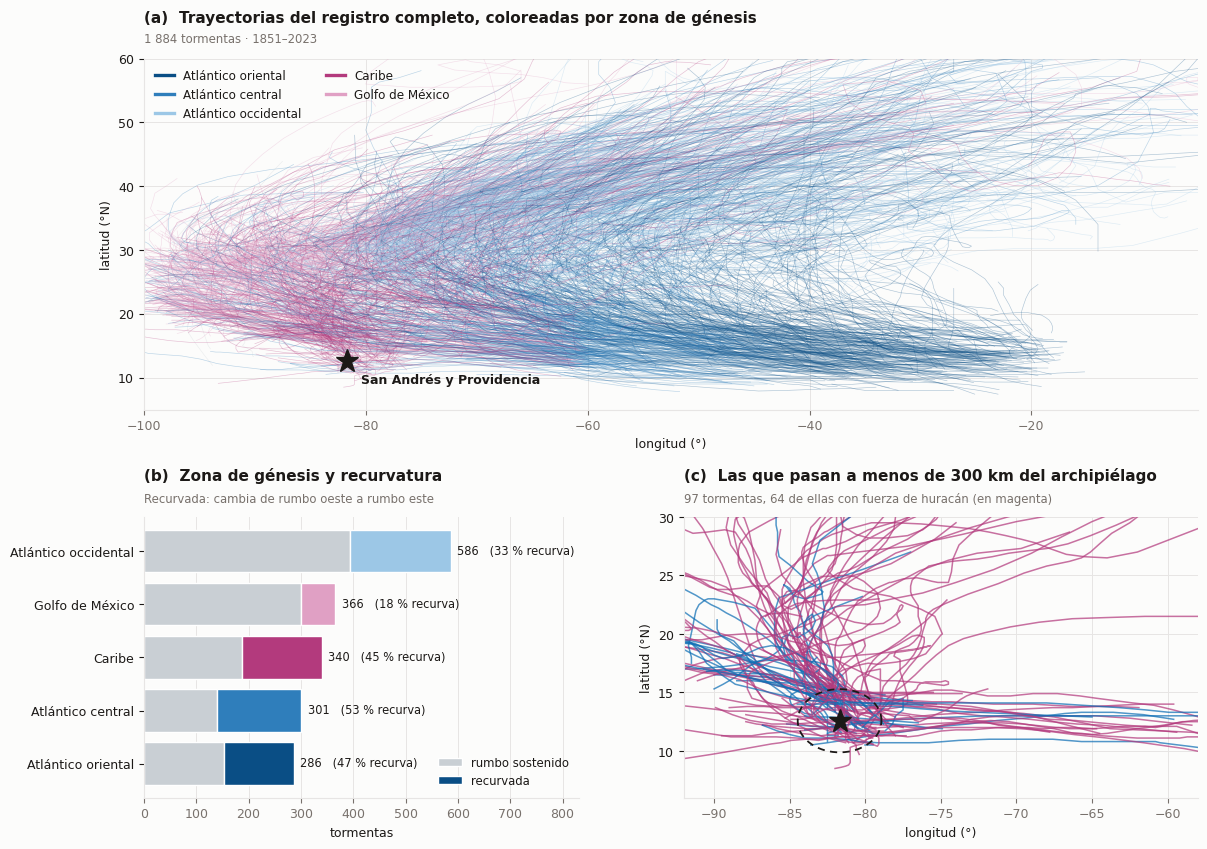

In [151]:
def figura_trayectorias(d, tray, radio_km=RADIO_KM):
    zona = dict(zip(tray.Code_storm, tray.zona_genesis))
    cerca = set(tray.loc[tray.afecta_san_andres, "Code_storm"])

    fig = plt.figure(figsize=(13.6, 9.6))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1.0], width_ratios=[1.0, 1.18],
                          hspace=0.34, wspace=0.22)

    # (a) todas las trayectorias
    ax = fig.add_subplot(gs[0, :])
    for sid, s in d.groupby("Code_storm", sort=False):
        z = zona.get(sid)
        if z is None:
            continue
        ax.plot(s.Lon_W, s.Lat_N, lw=0.45, alpha=0.32, color=COLOR_ZONA[z],
                solid_capstyle="round")
    ax.plot(*SAN_ANDRES[::-1], marker="*", ms=17, color=INK, zorder=6)
    ax.annotate("San Andrés y Providencia", SAN_ANDRES[::-1], xytext=(10, -16),
                textcoords="offset points", fontsize=9, fontweight="bold", color=INK)
    ax.set_xlim(-100, -5); ax.set_ylim(5, 60)
    ax.set_xlabel("longitud (°)"); ax.set_ylabel("latitud (°N)")
    ax.set_title("(a)  Trayectorias del registro completo, coloreadas por zona de génesis",
                 fontsize=11, fontweight="bold", loc="left", color=INK, pad=26)
    ax.text(0, 1.045, f"{len(tray):,}".replace(",", " ") +
            f" tormentas · {int(tray.anio.min())}–{int(tray.anio.max())}",
            transform=ax.transAxes, fontsize=8.4, color=MUTED)
    ax.grid(color=LINEA, lw=0.7); ax.set_axisbelow(True)
    ax.legend(handles=[Line2D([], [], color=c, lw=2.4, label=z)
                       for z, c in COLOR_ZONA.items() if z != "Otras"],
              frameon=False, fontsize=8.6, loc="upper left", ncol=2, handlelength=1.6)

    # (b) composición por zona y recurvatura
    ax2 = fig.add_subplot(gs[1, 0])
    r = (tray.groupby("zona_genesis")
             .agg(n=("Code_storm", "size"), recurva=("recurva", "sum"))
             .drop(index="Otras", errors="ignore").sort_values("n"))
    y = np.arange(len(r))
    ax2.barh(y, r.n - r.recurva, color="#C9CFD4", edgecolor="white",
             label="rumbo sostenido")
    ax2.barh(y, r.recurva, left=r.n - r.recurva,
             color=[COLOR_ZONA[z] for z in r.index], edgecolor="white", label="recurvada")
    for i, (n, rec) in enumerate(zip(r.n, r.recurva)):
        ax2.text(n + 12, i, f"{n}   ({100*rec/n:.0f} % recurva)", va="center",
                 fontsize=8.2, color=INK)
    ax2.set_yticks(y); ax2.set_yticklabels(r.index, fontsize=9)
    ax2.set_xlim(0, r.n.max() * 1.42); ax2.set_xlabel("tormentas")
    ax2.set_title("(b)  Zona de génesis y recurvatura", fontsize=11, fontweight="bold",
                  loc="left", color=INK, pad=26)
    ax2.text(0, 1.05, "Recurvada: cambia de rumbo oeste a rumbo este",
             transform=ax2.transAxes, fontsize=8.4, color=MUTED)
    ax2.legend(frameon=False, fontsize=8.4, loc="lower right")
    ax2.grid(axis="x", color=LINEA, lw=0.7); ax2.set_axisbelow(True)

    # (c) las que se acercan al archipiélago
    ax3 = fig.add_subplot(gs[1, 1])
    for sid, s in d[d.Code_storm.isin(cerca)].groupby("Code_storm", sort=False):
        col = MAGENTA if s.Max_wind.max() >= 64 else AZUL
        ax3.plot(s.Lon_W, s.Lat_N, lw=1.1, alpha=0.72, color=col)
    th = np.linspace(0, 2 * np.pi, 200)
    dlat = radio_km / 111.0
    ax3.plot(SAN_ANDRES[1] + dlat * np.cos(th) / np.cos(np.radians(SAN_ANDRES[0])),
             SAN_ANDRES[0] + dlat * np.sin(th), color=INK, lw=1.3, ls=(0, (4, 3)))
    ax3.plot(*SAN_ANDRES[::-1], marker="*", ms=17, color=INK, zorder=6)
    ax3.set_xlim(-92, -58); ax3.set_ylim(6, 30)
    ax3.set_xlabel("longitud (°)"); ax3.set_ylabel("latitud (°N)")
    ax3.set_title("(c)  Las que pasan a menos de 300 km del archipiélago",
                  fontsize=11, fontweight="bold", loc="left", color=INK, pad=26)
    n_hu = int((tray[tray.afecta_san_andres].viento_max >= 64).sum())
    ax3.text(0, 1.05, f"{len(cerca)} tormentas, {n_hu} de ellas con fuerza de huracán "
             "(en magenta)", transform=ax3.transAxes, fontsize=8.4, color=MUTED)
    ax3.grid(color=LINEA, lw=0.7); ax3.set_axisbelow(True)
    plt.show()


figura_trayectorias(df_EDA, tray)

In [152]:
# ══════════════════════════════════════════════════════════════════
#  EDA post-imputación · 2. Entorno e intensificación en 24 h
# ══════════════════════════════════════════════════════════════════
TROPICALES = ["TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
PASOS_24H  = 4        # 4 pasos de 6 h
UMBRAL_RI  = 30.0     # nudos en 24 h: definición operativa de intensificación rápida


def cambio_intensidad(d, pasos=PASOS_24H):
    """Añade el cambio de viento y de presión en las próximas 24 horas."""
    d = d.sort_values(["Code_storm", "fecha"]).copy()
    g = d.groupby("Code_storm")
    d["d_viento_24h"]  = g["Max_wind"].shift(-pasos) - d["Max_wind"]
    d["d_presion_24h"] = g["MinPress"].shift(-pasos) - d["MinPress"]
    # solo pares realmente separados 24 h: el registro tiene huecos
    horas = (g["fecha"].shift(-pasos) - d["fecha"]).dt.total_seconds() / 3600
    d.loc[~horas.between(23, 25), ["d_viento_24h", "d_presion_24h"]] = np.nan
    d["intensifica"]     = d["d_viento_24h"] > 0
    d["intensif_rapida"] = d["d_viento_24h"] >= UMBRAL_RI
    return d


# df_EDA aquí ya está restringido al subconjunto con SHIPS.
# Para la NAO conviene el registro completo: usar df_sin_filtrar si se creó
# (ver el bloque de los dos conjuntos de entrenamiento); si no, df_EDA sirve igual.
amb = cambio_intensidad(df_EDA[df_EDA.type_storm.isin(TROPICALES)])
try:
    todo = cambio_intensidad(df_sin_filtrar[df_sin_filtrar.type_storm.isin(TROPICALES)])
except NameError:
    todo = amb

print(f"pares de 24 h con SHIPS: {amb.d_viento_24h.notna().sum()}")
print(f"pares de 24 h en total : {todo.d_viento_24h.notna().sum()}")
print(f"intensificación rápida : {100*amb.intensif_rapida.mean():.1f} % de los casos")

pares de 24 h con SHIPS: 32230
pares de 24 h en total : 32230
intensificación rápida : 3.4 % de los casos


### ¿Cuándo se intensifican de verdad los ciclones?

La pregunta es doble: si el entorno afecta a la intensidad, y qué condiciones lo hacen. Un diagrama de puntos la responde de forma más directa que cualquier resumen: cada punto es una observación, con la condición ambiental en el eje horizontal y lo que hizo el viento en las 24 horas siguientes en el vertical. En magenta, los casos de intensificación rápida —30 nudos o más en 24 horas—, que es lo que interesa ver dónde caen.

La línea azul es el cambio medio en tramos de ancho fijo. Se descartan los tramos con menos de 25 observaciones: en los extremos hay tan pocos casos que su promedio saltaría por azar y aparentaría una tendencia que no está en los datos, de modo que la línea no llega hasta los bordes del eje.

El índice NAO queda fuera de este análisis. Es un valor mensual y la ventana es de 24 horas, así que no puede explicar la variación entre observaciones consecutivas de una misma tormenta.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  ¿Cuándo ocurren las intensificaciones fuertes?
# ══════════════════════════════════════════════════════════════════════════
# Un punto por observación: la condición ambiental en el eje horizontal y lo que
# hizo el viento en las 24 horas siguientes en el vertical. En magenta, los casos
# de intensificación rápida —30 nudos o más en 24 horas—, que es lo que interesa
# ver dónde caen.
from matplotlib.lines import Line2D

AMBIENTALES = [
    #  variable   eje                                límites  título  unidad  sentido  ancho del tramo
    ("shear_kt", "Cizalladura 850–200 hPa  (nudos)", (0, 45),
     "(a)  Con cizalladura baja", "nudos", "menos", 5.0),
    ("rh_pct",   "Humedad de capa media  (%)",       (30, 90),
     "(b)  Con la capa media húmeda", "%", "más", 5.0),
    ("sst_c",    "Temperatura del mar  (°C)",        (23, 31),
     "(c)  Con el mar cálido", "°C", "más", 0.5),
]
UMBRAL_RI = 30.0
GRIS = "#C3CBD1"

VARS = [v for v, *_ in AMBIENTALES]
ent = amb.dropna(subset=VARS + ["d_viento_24h"]).copy()
ent["rapida"] = ent.d_viento_24h >= UMBRAL_RI
print(f"{len(ent)} observaciones · {ent.Code_storm.nunique()} tormentas · "
      f"{ent.rapida.sum()} casos de intensificación rápida ({100*ent.rapida.mean():.1f} %)")


def media_por_tramos(x, y, ancho, minimo=25):
    """Cambio medio del viento en tramos de ancho fijo de la variable ambiental.

    Los tramos con menos de `minimo` observaciones se descartan: en los extremos
    hay tan pocos casos que su promedio saltaría por puro azar y daría la
    impresión de una tendencia que no está en los datos.
    """
    borde = np.floor(x.min() / ancho) * ancho
    bordes = np.arange(borde, x.max() + ancho, ancho)
    tramo = pd.cut(x, bordes)
    g = pd.DataFrame({"x": x, "y": y}).groupby(tramo, observed=True).agg(
        centro=("x", "mean"), media=("y", "mean"), n=("y", "size"))
    g = g[g.n >= minimo]
    return g.centro.values, g.media.values


# El viento de HURDAT2 se registra en escalones de 5 nudos, así que los puntos
# caerían sobre una rejilla y taparían la densidad real. Un desplazamiento
# aleatorio pequeño en el eje vertical la deja a la vista.
rng = np.random.default_rng(3)
ent["y_disperso"] = ent.d_viento_24h + rng.uniform(-2.0, 2.0, len(ent))

# El eje vertical se recorta en ±60 nudos. Fuera quedan 17 observaciones de 1 785
# —el 0,95 %—, casi todas debilitamientos bruscos por entrada a tierra, que
# estirarían la escala y aplastarían la zona donde está todo lo demás.
LIMITE_Y = (-62, 80)
fuera = (ent.d_viento_24h < LIMITE_Y[0]) | (ent.d_viento_24h > LIMITE_Y[1])
print(f"quedan fuera del recorte vertical {fuera.sum()} observaciones "
      f"({100*fuera.mean():.1f} %)")


fig, axes = plt.subplots(2, 2, figsize=(13.4, 9.0))
fig.subplots_adjust(hspace=0.52, wspace=0.26)

normal, rapida = ent[~ent.rapida], ent[ent.rapida]
for ax, (v, etiqueta, limites, titulo, unidad, sentido, ancho) in zip(axes.ravel(), AMBIENTALES):
    ax.axhline(0, color=INK, lw=1.0, zorder=2)
    ax.axhline(UMBRAL_RI, color=MAGENTA, lw=1.0, ls=(0, (5, 4)), zorder=2)
    ax.scatter(normal[v], normal.y_disperso, s=10, color=GRIS, lw=0, alpha=0.7, zorder=3)
    ax.scatter(rapida[v], rapida.y_disperso, s=24, color=MAGENTA, lw=0, alpha=0.85, zorder=4)
    mx, my = media_por_tramos(ent[v], ent.d_viento_24h, ancho)
    ax.plot(mx, my, "-", lw=2.8, color=AZUL, zorder=5)
    ax.set_xlim(*limites)
    ax.set_ylim(*LIMITE_Y)
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("cambio del viento en las 24 h siguientes  (nudos)")
    ax.grid(color=LINEA, lw=0.7); ax.set_axisbelow(True)
    ax.set_title(titulo, fontsize=11, fontweight="bold", loc="left", color=INK, pad=26)
    p50 = rapida[v].median()
    ax.text(0, 1.035, f"la mitad de los casos rápidos ocurre con {sentido} de "
            f"{p50:.0f} {unidad}", transform=ax.transAxes, fontsize=8.6, color=MAGENTA)

# (d) las dos condiciones a la vez
ax = axes.ravel()[3]
normal, rapida = ent[~ent.rapida], ent[ent.rapida]
ax.scatter(normal.shear_kt, normal.rh_pct, s=10, color=GRIS, lw=0, alpha=0.7, zorder=3)
ax.scatter(rapida.shear_kt, rapida.rh_pct, s=28, color=MAGENTA, lw=0, alpha=0.85, zorder=4)
ax.axvline(ent.shear_kt.median(), color=INK, lw=1.0, ls=(0, (5, 4)), zorder=2)
ax.axhline(ent.rh_pct.median(), color=INK, lw=1.0, ls=(0, (5, 4)), zorder=2)
ax.set_xlim(0, 45); ax.set_ylim(30, 90)
ax.set_xlabel("Cizalladura 850–200 hPa  (nudos)")
ax.set_ylabel("Humedad de capa media  (%)")
ax.grid(color=LINEA, lw=0.7); ax.set_axisbelow(True)
ax.set_title("(d)  Las dos condiciones a la vez", fontsize=11, fontweight="bold",
             loc="left", color=INK, pad=26)
ax.text(0, 1.035, "Cortado por las medianas. El porcentaje es la proporción de casos "
        "rápidos en cada cuadrante.", transform=ax.transAxes, fontsize=8.6, color=MUTED)

# porcentaje de casos rápidos en cada cuadrante
cs, ch = ent.shear_kt.median(), ent.rh_pct.median()
X0, X1, Y0, Y1 = 0, 45, 30, 90
CUADRANTES = [  # (rango x, rango y, esquina donde va la cifra)
    ((X0, cs), (ch, Y1), (0.03, 0.97, "left",  "top")),
    ((cs, X1), (ch, Y1), (0.97, 0.97, "right", "top")),
    ((X0, cs), (Y0, ch), (0.03, 0.03, "left",  "bottom")),
    ((cs, X1), (Y0, ch), (0.97, 0.03, "right", "bottom")),
]
for (x0, x1), (y0, y1), (fx, fy, ha, va) in CUADRANTES:
    z = ent[ent.shear_kt.between(x0, x1) & ent.rh_pct.between(y0, y1)]
    if len(z) < 30:
        continue
    p = z.rapida.mean()
    ax.text(fx, fy, f"{100*p:.1f} %", transform=ax.transAxes, ha=ha, va=va,
            fontsize=15, fontweight="bold",
            color=MAGENTA if p > ent.rapida.mean() else MUTED, zorder=6)
    ax.text(fx, fy - (0.062 if va == "top" else -0.062),
            f"n = {len(z)}", transform=ax.transAxes, ha=ha, va=va,
            fontsize=8.2, color=MUTED, zorder=6)

fig.legend(handles=[
    Line2D([], [], marker="o", ls="", ms=7, color=GRIS, label="observación"),
    Line2D([], [], marker="o", ls="", ms=8, color=MAGENTA,
           label=f"intensificación rápida (≥ {UMBRAL_RI:.0f} nudos en 24 h)"),
    Line2D([], [], ls="-", lw=2.8, color=AZUL, label="cambio medio por tramos")],
    frameon=False, fontsize=9, ncol=3, loc="upper left",
    bbox_to_anchor=(0.045, 1.018))

fig.suptitle("¿Cuándo se intensifican de verdad los ciclones?",
             fontsize=14, fontweight="bold", x=0.045, ha="left", y=1.075)
fig.text(0.045, 1.045,
         f"Un punto por observación. Ciclones tropicales con datos SHIPS · "
         f"{len(ent)} observaciones de {ent.Code_storm.nunique()} tormentas. "
         f"La línea azul es el cambio medio en tramos de igual ancho —5 nudos, 5 % y "
         f"0,5 °C— saltando los tramos con menos de 25 casos.",
         fontsize=8.8, color=MUTED, ha="left", va="top")
plt.show()

**Lo que se ve.**

En (a) los casos de intensificación rápida se amontonan a la izquierda y desaparecen casi por completo pasados los 25 nudos de cizalladura: la mitad ocurre con menos de 8 nudos. En (c) casi todos están por encima de los 28 °C, y la nube se estrecha bruscamente por debajo de esa temperatura. En (b) la relación existe pero es más difusa, con casos rápidos repartidos en un rango amplio de humedad.

El panel (d) es el que cierra el argumento. Cortando la muestra por las medianas de cizalladura y humedad, el cuadrante de cizalladura baja y aire húmedo concentra un **15,2 %** de casos de intensificación rápida, frente a un **2,5 %** en el cuadrante opuesto. Seis veces más. Ninguna de las dos condiciones por separado alcanza ese contraste: con cizalladura baja pero aire seco la proporción es del 6,8 %, y con aire húmedo pero cizalladura alta, del 5,1 %.

Esa es la lectura física: la intensificación rápida no responde a una condición aislada sino a la coincidencia de varias, y la cizalladura baja es la que más pesa. El entorno favorable no garantiza la intensificación —la mayoría de los puntos del cuadrante favorable son grises—, pero la hace mucho más probable.


## EDA post-imputación · 3. Qué aportan el tamaño y la asimetría del campo de viento

Las dos variables derivadas en el apartado 4.3.1 se cruzan aquí con el resto del conjunto: con qué se relacionan, cuánto aportan fuera de muestra frente a los cuadrantes crudos y qué limitación conviene declarar al interpretarlas. El análisis se restringe a los sistemas tropicales por la razón expuesta en el apartado 3.2.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  EDA post-imputación · 3. Tamaño y asimetría del campo de viento
# ══════════════════════════════════════════════════════════════════════════
# Se excluyen los sistemas extratropicales y subtropicales. No es una decisión
# cosmética: un ciclón extratropical responde a dinámica baroclínica y no a un
# núcleo cálido, su campo de viento es amplio y débil, y no ocurre en la zona
# de estudio —de los 2 381 registros EX de 1975 en adelante, ninguno se sitúa
# al sur de 20 °N—. Mezclarlos invierte el signo de la relación entre tamaño e
# intensidad.
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

TROPICALES = ["TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
U_REF = 34                       # umbral de referencia: el de mayor cobertura
RM, ASI = f"radio_medio_{U_REF}", f"asimetria_{U_REF}"

rad = df_EDA[df_EDA.type_storm.isin(TROPICALES) & df_EDA[RM].notna()].copy()
rad = cambio_intensidad(rad)
print(f"registros tropicales con campo de viento: {len(rad)} · "
      f"{rad.Code_storm.nunique()} tormentas · "
      f"{int(rad.year.min())}–{int(rad.year.max())}")

# ── 3.1 Relación con el resto de las variables ──────────────────────────────
OTRAS = [("Max_wind", "viento máximo"), ("MinPress", "presión mínima"),
         ("Lat_N", "latitud"), ("vec_len", "magnitud del desplazamiento"),
         ("shear_kt", "cizalladura 850–200 hPa"), ("sst_c", "temperatura del mar"),
         ("rh_pct", "humedad de capa media"), ("heat_content", "contenido de calor"),
         ("nao", "índice NAO"), ("d_viento_24h", "cambio de viento en 24 h")]
OTRAS = [(c, e) for c, e in OTRAS if c in rad.columns]

filas = []
for c, etiqueta in OTRAS:
    s = rad[[RM, ASI, c]].dropna()
    if len(s) < 100:
        continue
    filas.append({"variable": etiqueta, "n": len(s),
                  "r con tamaño": s[RM].corr(s[c]),
                  "r con asimetría": s[ASI].corr(s[c])})
corr_rad = pd.DataFrame(filas).set_index("variable")
print("\ncorrelación de Pearson (solo sistemas tropicales):")
print(corr_rad.round(3).to_string())

# ── 3.2 El artefacto de los campos parciales ────────────────────────────────
# Cuando un sistema débil solo alcanza el umbral en uno o dos cuadrantes, los
# demás valen cero y la asimetría se dispara por construcción, no por física.
# La asimetría estaría midiendo, en parte, cuántos cuadrantes alcanzaron el
# umbral, que es otra forma de decir la intensidad: una circularidad.
parcial = rad[rad[f"cuadrantes_{U_REF}"] > 0]
tabla_parcial = parcial.groupby(f"cuadrantes_{U_REF}").agg(
    n=(ASI, "size"), asimetria=(ASI, "median"),
    tamano=(RM, "median"), viento=("Max_wind", "median")).round(3)
print("\nasimetría según cuántos cuadrantes alcanzan los 34 nudos:")
print(tabla_parcial.to_string())

completo = rad[rad[f"cuadrantes_{U_REF}"] == 4]
print(f"\nrestringido a campos completos (n = {len(completo)}):")
for c, etiqueta in [("Max_wind", "viento máximo"), ("MinPress", "presión mínima")]:
    s = completo[[RM, ASI, c]].dropna()
    print(f"   {etiqueta:16s} tamaño r = {s[RM].corr(s[c]):+.3f} · "
          f"asimetría r = {s[ASI].corr(s[c]):+.3f}")

# ── 3.3 Importancia: ¿aportan algo que no aporten los cuadrantes crudos? ─────
CRUDOS = [f"{q}{U_REF}" for q in ["NE", "SE", "SW", "NW"]]
BASE = [c for c in ["Lat_N", "Lon_W", "vec_len", "shear_kt", "sst_c", "rh_pct"]
        if c in rad.columns]


def r2_grupo(d, columnas, objetivo, semilla=42):
    """R² fuera de muestra, con la separación hecha por tormenta."""
    s = d[columnas + [objetivo, "Code_storm"]].dropna()
    if len(s) < 200:
        return np.nan
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                    random_state=semilla).split(s, groups=s.Code_storm))
    m = RandomForestRegressor(n_estimators=250, min_samples_leaf=5,
                              random_state=semilla, n_jobs=-1)
    m.fit(s.iloc[tr][columnas], s.iloc[tr][objetivo])
    return m.score(s.iloc[te][columnas], s.iloc[te][objetivo])


OBJ_EVAL = [("MinPress", "presión mínima"), ("Max_wind", "viento máximo"),
            ("d_viento_24h", "cambio de viento en 24 h")]
comp = []
for obj, etiqueta in OBJ_EVAL:
    comp.append({
        "objetivo": etiqueta,
        "solo base": r2_grupo(rad, BASE, obj),
        "base + 4 cuadrantes": r2_grupo(rad, BASE + CRUDOS, obj),
        "base + tamaño": r2_grupo(rad, BASE + [RM], obj),
        "base + tamaño y asimetría": r2_grupo(rad, BASE + [RM, ASI], obj)})
comp_r2 = pd.DataFrame(comp).set_index("objetivo")
print("\nR² fuera de muestra (bosque aleatorio, separación por tormenta):")
print(comp_r2.round(3).to_string())

# importancia por permutación dentro del modelo completo de presión
s = rad[BASE + [RM, ASI, "MinPress", "Code_storm"]].dropna()
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                random_state=42).split(s, groups=s.Code_storm))
COLS_IMP = BASE + [RM, ASI]
mod = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
mod.fit(s.iloc[tr][COLS_IMP], s.iloc[tr]["MinPress"])
pi = permutation_importance(mod, s.iloc[te][COLS_IMP], s.iloc[te]["MinPress"],
                            n_repeats=15, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=COLS_IMP).sort_values(ascending=False)
imp_sd = pd.Series(pi.importances_std, index=COLS_IMP)
print("\nimportancia por permutación en el modelo de presión mínima "
      "(caída de R² al barajar cada variable):")
for k, v in imp.items():
    print(f"   {k:16s} {v:+.4f}  ±{imp_sd[k]:.4f}")

In [ ]:
# ── 3.4 Figura ──────────────────────────────────────────────────────────────
CAT_ORD = ["TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
# El panel (a) usa solo campos completos: con campos parciales la asimetría
# refleja el artefacto que documenta el panel (c), no la forma del ciclón.
pleno = rad[rad[f"cuadrantes_{U_REF}"] == 4]
presentes = [c for c in CAT_ORD if (pleno.type_storm == c).sum() >= 40]

fig = plt.figure(figsize=(14.6, 9.8))
gs = fig.add_gridspec(2, 2, hspace=0.58, wspace=0.52,
                      height_ratios=[1.0, 1.0], width_ratios=[1.05, 1.0])

# (a) tamaño y asimetría por categoría
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(presentes))
med_t = [pleno.loc[pleno.type_storm == c, RM].median() for c in presentes]
q1_t = [pleno.loc[pleno.type_storm == c, RM].quantile(.25) for c in presentes]
q3_t = [pleno.loc[pleno.type_storm == c, RM].quantile(.75) for c in presentes]
ax.fill_between(x, q1_t, q3_t, color=AZUL, alpha=0.15, lw=0)
ax.plot(x, med_t, "-o", ms=6.5, lw=2.3, color=AZUL)
ax.set_ylabel("Tamaño del campo de 34 nudos  (millas náuticas)", color=AZUL)
ax.tick_params(axis="y", colors=AZUL)
ax.set_xticks(x); ax.set_xticklabels(presentes, fontsize=9)
ax.set_ylim(0, 205); ax.grid(color=LINEA, lw=0.8); ax.set_axisbelow(True)

axb = ax.twinx()
med_a = [pleno.loc[pleno.type_storm == c, ASI].median() for c in presentes]
q1_a = [pleno.loc[pleno.type_storm == c, ASI].quantile(.25) for c in presentes]
q3_a = [pleno.loc[pleno.type_storm == c, ASI].quantile(.75) for c in presentes]
axb.fill_between(x, q1_a, q3_a, color=MAGENTA, alpha=0.13, lw=0)
axb.plot(x, med_a, "-s", ms=6, lw=2.3, color=MAGENTA)
axb.set_ylabel("Asimetría  (0 = circular)", color=MAGENTA, labelpad=2)
axb.tick_params(axis="y", colors=MAGENTA); axb.set_ylim(0, 0.55)
axb.spines["right"].set_visible(True); axb.spines["right"].set_color(LINEA)
axb.grid(False)
ax.set_title("(a)  El campo crece y se ordena con la intensidad",
             fontsize=11, fontweight="bold", loc="left", color=INK, pad=36)
ax.text(0, 1.05, "Mediana y rango intercuartílico, solo campos completos.\n"
        f"Sistemas tropicales · {pleno.Code_storm.nunique()} tormentas · "
        f"{int(rad.year.min())}–{int(rad.year.max())}.",
        transform=ax.transAxes, fontsize=8.4, color=MUTED, linespacing=1.5)

# (b) correlación con el resto de las variables
ax2 = fig.add_subplot(gs[0, 1])
cr = corr_rad.iloc[::-1]
y = np.arange(len(cr))
ax2.barh(y + 0.20, cr["r con tamaño"], height=0.38, color=AZUL,
         edgecolor="white", label="tamaño", zorder=3)
ax2.barh(y - 0.20, cr["r con asimetría"], height=0.38, color=MAGENTA,
         edgecolor="white", label="asimetría", zorder=3)
ax2.axvline(0, color=INK, lw=1.1)
ax2.set_yticks(y); ax2.set_yticklabels(cr.index, fontsize=8.4)
ax2.set_xlim(-0.85, 0.85); ax2.set_xlabel("correlación de Pearson")
ax2.grid(axis="x", color=LINEA, lw=0.8); ax2.set_axisbelow(True)
ax2.legend(frameon=False, fontsize=8.6, loc="upper left", ncol=1, handlelength=1.2,
           bbox_to_anchor=(0.0, 0.62))
ax2.set_title("(b)  Con qué se relaciona cada una",
              fontsize=11, fontweight="bold", loc="left", color=INK, pad=36)
ax2.text(0, 1.05, "Signos opuestos: el campo grande acompaña a la presión baja;\n"
         "la asimetría, a la presión alta.", transform=ax2.transAxes,
         fontsize=8.4, color=MUTED, linespacing=1.5)

# (c) el artefacto de los campos parciales
ax3 = fig.add_subplot(gs[1, 0])
t = tabla_parcial
xc = np.arange(len(t))
ax3.bar(xc, t["asimetria"], width=0.56, color=MAGENTA, edgecolor="white", zorder=3)
for i, v in enumerate(t["asimetria"]):
    ax3.text(i, v + 0.035, f"{v:.2f}".replace(".", ","), ha="center",
             fontsize=9.5, color=MAGENTA, fontweight="bold")
ax3.set_xticks(xc)
ax3.set_xticklabels([f"{int(k)}\nn = {int(n)}" for k, n in zip(t.index, t["n"])],
                    fontsize=9, linespacing=1.7)
ax3.set_xlabel("cuadrantes que alcanzan los 34 nudos")
ax3.set_ylabel("asimetría mediana"); ax3.set_ylim(0, 1.15)
ax3.grid(axis="y", color=LINEA, lw=0.8); ax3.set_axisbelow(True)
axd = ax3.twinx()
axd.plot(xc, t["viento"], "-o", ms=6, lw=2.2, color=INK)
axd.set_ylabel("viento máximo mediano (nudos)", color=INK)
axd.set_ylim(0, 100); axd.grid(False)
axd.spines["right"].set_visible(True); axd.spines["right"].set_color(LINEA)
ax3.set_title("(c)  El artefacto que obliga a leer la asimetría con cuidado",
              fontsize=11, fontweight="bold", loc="left", color=INK, pad=36)
ax3.text(0, 1.05, "Un sistema débil solo alcanza el umbral en uno o dos\n"
         "cuadrantes y la asimetría se dispara por construcción.",
         transform=ax3.transAxes, fontsize=8.4, color=MUTED, linespacing=1.5)

# (d) aporte fuera de muestra
ax4 = fig.add_subplot(gs[1, 1])
conj = ["solo base", "base + 4 cuadrantes", "base + tamaño", "base + tamaño y asimetría"]
COLOR_C = {"solo base": "#C9CFD4", "base + 4 cuadrantes": "#9CC7E6",
           "base + tamaño": AZUL, "base + tamaño y asimetría": MAGENTA}
xg = np.arange(len(comp_r2)); w = 0.20
for k, c in enumerate(conj):
    ax4.bar(xg + (k - 1.5) * w, comp_r2[c], width=w, color=COLOR_C[c],
            edgecolor="white", label=c, zorder=3)
ax4.axhline(0, color=INK, lw=1.0)
ax4.set_xticks(xg)
ax4.set_xticklabels([i.replace(" en 24 h", "\nen 24 h") for i in comp_r2.index],
                    fontsize=8.6)
ax4.set_ylabel("R² fuera de muestra")
ax4.grid(axis="y", color=LINEA, lw=0.8); ax4.set_axisbelow(True)
ax4.legend(frameon=False, fontsize=8.0, loc="upper right", ncol=1, handlelength=1.2)
ax4.set_ylim(0, max(comp_r2.max()) * 1.32)
ax4.set_title("(d)  Dos variables rinden lo que cuatro",
              fontsize=11, fontweight="bold", loc="left", color=INK, pad=36)
ax4.text(0, 1.05, "Bosque aleatorio, separación por tormenta. La base son\n"
         "posición, desplazamiento y entorno.", transform=ax4.transAxes,
         fontsize=8.4, color=MUTED, linespacing=1.5)

plt.show()

**Lo que muestra este bloque.**

Primero, **las dos variables derivadas rinden lo que las cuatro crudas**. Para la presión mínima, los cuatro cuadrantes de 34 nudos dan un R² fuera de muestra de 0,790 y el par tamaño-asimetría da 0,785; para el viento máximo, 0,751 frente a 0,750. La mitad de variables, el mismo rendimiento y sin la redundancia interna que obligaba a purgar cuadrantes sueltos sin criterio interpretable.

Segundo, **la asimetría no es un adorno del tamaño**. El tamaño por sí solo llega a 0,638 en el modelo de presión; añadir la asimetría lo lleva a 0,785. Ese salto es exactamente la información que los cuadrantes crudos escondían al repetir el tamaño cuatro veces. En la importancia por permutación la asimetría queda segunda, por delante de la temperatura superficial del mar. Para el cambio de viento en 24 horas las derivadas superan además a los cuadrantes crudos, 0,109 frente a 0,066.

Tercero, **hay un artefacto que obliga a leer la asimetría con cuidado y que conviene declarar**. Cuando un sistema débil solo alcanza los 34 nudos en uno o dos cuadrantes, los demás valen cero y la asimetría se dispara por construcción, no por la forma del ciclón: su mediana es 1,00 con un cuadrante y 0,15 con los cuatro. Sin ese control la asimetría correlaciona −0,57 con el viento máximo, cifra que mide en buena parte cuántos cuadrantes alcanzaron el umbral —otra forma de decir la intensidad—. Restringida a campos completos, la correlación real es −0,211 con el viento y +0,243 con la presión: más modesta, pero física. El panel (a) de la figura usa por eso solo campos completos y el panel (c) documenta el artefacto.


# ## funciones generales para los modelos, métricas y gráficas

In [154]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metricas_regresion_robustas(y_true, y_pred, eps=1e-6, umbral_mape=1.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # MAPE filtrado (evita explosión por valores cercanos a 0)
    mask = np.abs(y_true) >= umbral_mape
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))) * 100 if mask.any() else np.nan
    # sMAPE y WAPE (más estables)
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100
    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE_%_filtrado": mape,
        "sMAPE_%": smape,
        "WAPE_%": wape,
    }

In [155]:
import matplotlib.pyplot as plt
import numpy as np


def plot_one_sequence(y_true, y_pred, idx=0, titulo="Target"):
    # y_true, y_pred: shape (n_samples, horizon)
    h = y_true.shape[1]
    x = np.arange(1, h + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y_true[idx], marker="o", label="Real")
    plt.plot(x, y_pred[idx], marker="o", linestyle="--", label="Pred")
    plt.title(f"{titulo} - muestra {idx}")
    plt.xlabel("Horizonte (t+1 ... t+h)")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [156]:

def plot_residuals(y_true, y_pred, model_name="Modelo", conjunto="Test", save_path=None):
    """Crea gráficos de análisis de residuos."""
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Análisis de Residuos - {model_name} ({conjunto})",
        fontsize=16, fontweight="bold", y=0.995
    )

    # 1) Residuos vs predichos
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=20, color="#2E86AB")
    axes[0, 0].axhline(y=0, color="r", linestyle="--", linewidth=2)
    z = np.polyfit(y_pred, residuals, 1)
    axes[0, 0].plot(y_pred, np.poly1d(z)(y_pred), "r--", alpha=0.8, linewidth=1.5)
    axes[0, 0].set_xlabel("Valores Predichos")
    axes[0, 0].set_ylabel("Residuos")
    axes[0, 0].set_title("Residuos vs Valores Predichos")
    axes[0, 0].grid(True, alpha=0.3, linestyle="--")

    # 2) Histograma
    n, bins, _ = axes[0, 1].hist(residuals, bins=30, color="#A23B72", alpha=0.7, edgecolor="black")
    axes[0, 1].axvline(x=0, color="r", linestyle="--", linewidth=2)
    mu, sigma = np.mean(residuals), np.std(residuals)
    x_norm = np.linspace(residuals.min(), residuals.max(), 100)
    y_norm = len(residuals) * (bins[1] - bins[0]) * stats.norm.pdf(x_norm, mu, sigma)
    axes[0, 1].plot(x_norm, y_norm, "r-", linewidth=2, label=f"Normal(μ={mu:.3f}, σ={sigma:.3f})")
    axes[0, 1].set_xlabel("Residuos")
    axes[0, 1].set_ylabel("Frecuencia")
    axes[0, 1].set_title("Distribución de Residuos")
    axes[0, 1].grid(True, alpha=0.3, linestyle="--", axis="y")
    axes[0, 1].legend()

    # 3) Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("Q-Q Plot (Normalidad de Residuos)")
    axes[1, 0].grid(True, alpha=0.3, linestyle="--")

    # 4) Residuos vs índice
    axes[1, 1].scatter(range(len(residuals)), residuals, alpha=0.5, s=20, color="#F18F01")
    axes[1, 1].axhline(y=0, color="r", linestyle="--", linewidth=2)
    axes[1, 1].set_xlabel("Índice de Observación")
    axes[1, 1].set_ylabel("Residuos")
    axes[1, 1].set_title("Residuos vs Índice")
    axes[1, 1].grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", format="jpeg")
        plt.close()
    else:
        plt.show()


def analizar_residuos_test_tres_targets(
    nombre_modelo,
    model_dir,
    model_len,
    model_minpress,
    X_test_dir_flat,
    X_test_len_flat,
    X_test_minpress_flat,
    y_test_dir,
    y_test_len,
    y_test_minpress,
    output_dir=None,  # ej: "plots_modelos/rfr"
):
    """
    Calcula predicciones en test y genera análisis de residuos para
    Dirección, Length y MinPress (Presión mínima, mb) usando plot_residuals.
    """
    y_pred_dir = model_dir.predict(X_test_dir_flat)
    y_pred_len = model_len.predict(X_test_len_flat)
    y_pred_minp = model_minpress.predict(X_test_minpress_flat)

    # Dirección
    save_dir = None if output_dir is None else f"{output_dir}/residuals_direction.jpg"
    plot_residuals(
        y_test_dir.ravel(),
        y_pred_dir.ravel(),
        model_name=f"{nombre_modelo} - Direccion",
        conjunto="Test",
        save_path=save_dir,
    )

    # Length
    save_len = None if output_dir is None else f"{output_dir}/residuals_length.jpg"
    plot_residuals(
        y_test_len.ravel(),
        y_pred_len.ravel(),
        model_name=f"{nombre_modelo} - Length",
        conjunto="Test",
        save_path=save_len,
    )

    # MinPress (Presión mínima, mb)
    save_minp = None if output_dir is None else f"{output_dir}/residuals_minpress.jpg"
    plot_residuals(
        y_test_minpress.ravel(),
        y_pred_minp.ravel(),
        model_name=f"{nombre_modelo} - MinPress (Presión mínima, mb)",
        conjunto="Test",
        save_path=save_minp,
    )

    return y_pred_dir, y_pred_len, y_pred_minp

In [157]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def resumir_fi_flat_a_no_flat(df_fi, col_importance="importance"):
    """
    Convierte FI flat (feature_t-k) a vistas no-flat:
    1) por variable
    2) por lag (t-k)
    """
    df = df_fi.copy()

    # Detectar columna de importancia
    if col_importance not in df.columns:
        # fallback automático
        posibles = [c for c in ["importance", "importance_promedio_seq", "importance_local"] if c in df.columns]
        if not posibles:
            raise ValueError("No encuentro columna de importancia en df_fi")
        col_importance = posibles[0]

    if "feature" not in df.columns:
        raise ValueError("df_fi debe tener columna 'feature' con formato tipo 'MinPress_t-0'")

    # Parsear nombre y lag
    # Soporta variables con underscore: ej. max_wind_t-3
    parsed = df["feature"].str.extract(r"^(?P<var>.+)_t-(?P<lag>\d+)$")
    if parsed["var"].isna().any():
        raise ValueError("Algunas features no tienen formato '<variable>_t-<lag>'")

    df["variable"] = parsed["var"]
    df["lag"] = parsed["lag"].astype(int)

    # Resumen no-flat por variable (global)
    fi_por_variable = (
        df.groupby("variable", as_index=False)[col_importance]
        .sum()
        .sort_values(col_importance, ascending=False)
        .reset_index(drop=True)
    )

    # Resumen no-flat por lag temporal (global)
    fi_por_lag = (
        df.groupby("lag", as_index=False)[col_importance]
        .sum()
        .sort_values("lag", ascending=False)   # t-11 ... t-0
        .reset_index(drop=True)
    )
    fi_por_lag["etiqueta_lag"] = fi_por_lag["lag"].apply(lambda x: f"t-{x}")

    # Matriz variable x lag (heatmap o tabla)
    fi_matriz_var_lag = (
        df.pivot_table(
            index="variable",
            columns="lag",
            values=col_importance,
            aggfunc="sum",
            fill_value=0.0
        )
        .sort_index(axis=1, ascending=False)  # columnas: t-11 ... t-0
    )

    return fi_por_variable, fi_por_lag, fi_matriz_var_lag


def plot_fi_no_flat(fi_por_variable, fi_por_lag, top_vars=15, titulo="FI no-flat"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Por variable ---
    dfv = fi_por_variable.head(top_vars).copy()
    axes[0].barh(range(len(dfv)), dfv.iloc[:, 1], color=plt.cm.viridis(np.linspace(0, 1, len(dfv))))
    axes[0].set_yticks(range(len(dfv)))
    axes[0].set_yticklabels(dfv["variable"])
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Importancia agregada")
    axes[0].set_title(f"{titulo} - Por variable")
    axes[0].grid(axis="x", alpha=0.3, linestyle="--")

    # --- Por lag ---
    axes[1].bar(fi_por_lag["etiqueta_lag"], fi_por_lag.iloc[:, 1], color="#2E86AB")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Importancia agregada")
    axes[1].set_title(f"{titulo} - Por lag temporal")
    axes[1].grid(axis="y", alpha=0.3, linestyle="--")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [158]:
def _final_step_pipeline(estimator):
    if hasattr(estimator, "named_steps"):
        return estimator.named_steps[list(estimator.named_steps.keys())[-1]]
    return estimator

In [159]:
from typing import Any, Collection, List, Optional, Union

In [160]:
def fi_promedio_todas_las_secuencias(
    model,
    X_train_flat,
    timesteps: int,
    base_features,
    agg_horizontes: str = "mean_abs",
    max_samples: Optional[int] = None,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Promedia importancias de características entre salidas del MultiOutputRegressor
    (un árbol/XGB/RF por horizonte). Requiere `feature_importances_` en el último paso del pipeline.
    """
    if not hasattr(model, "estimators_"):
        raise ValueError(
            "Se espera un MultiOutputRegressor ajustado (atributo estimators_)."
        )

    X = np.asarray(X_train_flat)
    feature_names = [
        f"{feat}_t-{t}"
        for t in range(timesteps - 1, -1, -1)
        for feat in base_features
    ]
    n_exp = timesteps * len(base_features)
    if X.shape[1] != n_exp:
        raise ValueError(
            f"X_train_flat tiene {X.shape[1]} columnas; se esperaban {n_exp} "
            f"(timesteps={timesteps} × len(base_features)={len(base_features)})."
        )

    if max_samples is not None and X.shape[0] > max_samples:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(X.shape[0], size=max_samples, replace=False)
        X = X[idx]

    rows = []
    for est in model.estimators_:
        final = _final_step_pipeline(est)
        if not hasattr(final, "feature_importances_"):
            raise AttributeError(
                f"El estimador {type(final).__name__} no expone feature_importances_; "
                "esta función aplica a RandomForest, XGBoost, árbol, etc."
            )
        rows.append(final.feature_importances_)
    M = np.vstack(rows)

    if agg_horizontes == "mean_abs":
        agg = np.mean(np.abs(M), axis=0)
    elif agg_horizontes == "mean":
        agg = np.mean(M, axis=0)
    else:
        raise ValueError(
            f"agg_horizontes debe ser 'mean_abs' o 'mean', recibido: {agg_horizontes!r}"
        )

    out = pd.DataFrame({"feature": feature_names, "importance_promedio_seq": agg})
    for h in range(M.shape[0]):
        out[f"importance_h{h}"] = M[h]
    return out

# 5. Conjuntos de entrenamiento

Cada modelo se entrena **dos veces**: una con el conjunto A —solo HURDAT2— y otra con el conjunto B, que añade las variables ambientales del esquema SHIPS y el campo de viento. Las dos listas de predictores son las que salieron del análisis de colinealidad del apartado 4.5, `FEATURES_A` y `FEATURES_B`.

La comparación no es simétrica y conviene tenerlo presente al leer los resultados. B tiene más información por observación, pero A tiene muchas más tormentas, porque exigir SHIPS reduce la muestra a una fracción pequeña. Lo que se está midiendo, en realidad, es cuál de las dos cosas pesa más: la riqueza del entorno o el tamaño de la muestra.


In [ ]:
df_sin_filtrar = df_combinado.copy()   # conserva también las filas sin SHIPS

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Dos conjuntos de entrenamiento
# ══════════════════════════════════════════════════════════════════
# Las listas de predictores son las que salen del análisis de colinealidad
# (FEATURES_A y FEATURES_B). La NAO se conserva como columna descriptiva —sirve
# para la exploración— pero no entra como predictor: es un índice mensual y
# dentro de una ventana de 72 horas sería el mismo número repetido doce veces.
DESCRIPTIVAS = ["Code_storm", "year", "month", "day", "hour", "fecha",
                "type_storm", "nao"]

df_A = (df_EDA[DESCRIPTIVAS + FEATURES_A].dropna(subset=FEATURES_A)
        .sort_values(["Code_storm", "fecha"]).reset_index(drop=True))
df_B = (df_EDA[DESCRIPTIVAS + FEATURES_B].dropna(subset=FEATURES_B)
        .sort_values(["Code_storm", "fecha"]).reset_index(drop=True))

TIMESTEPS, HORIZON = 12, 12
def ventanas(d, t=TIMESTEPS, h=HORIZON):
    n = d.groupby("Code_storm").size()
    return int(np.maximum(0, n - t - h + 1).sum())

resumen_conjuntos = pd.DataFrame([
    {"conjunto": "A · HURDAT2", "filas": len(df_A),
     "tormentas": df_A.Code_storm.nunique(), "predictores": len(FEATURES_A),
     "ventanas 12+12": ventanas(df_A),
     "período": f"{int(df_A.year.min())}–{int(df_A.year.max())}"},
    {"conjunto": "B · HURDAT2 + SHIPS + campo de viento", "filas": len(df_B),
     "tormentas": df_B.Code_storm.nunique(), "predictores": len(FEATURES_B),
     "ventanas 12+12": ventanas(df_B),
     "período": f"{int(df_B.year.min())}–{int(df_B.year.max())}"},
])
print(resumen_conjuntos.to_string(index=False))
print(f"\nExigir SHIPS y campo de viento reduce las tormentas en un "
      f"{100*(1 - resumen_conjuntos['tormentas'][1]/resumen_conjuntos['tormentas'][0]):.0f} % "
      f"y las ventanas utilizables en un "
      f"{100*(1 - resumen_conjuntos['ventanas 12+12'][1]/resumen_conjuntos['ventanas 12+12'][0]):.0f} %.")

## 5.1 Preparación de los dos conjuntos

La separación entre entrenamiento y prueba se hace por tormenta —el 10 % final del registro va a prueba— y las secuencias se construyen con la misma función de siempre, con doce pasos de entrada y doce de horizonte. Todo queda en `DATOS["A"]` y `DATOS["B"]`, con idéntica estructura, de modo que el código de cada modelo no necesita saber con cuál de los dos está trabajando.


In [ ]:
# ========================================
# FUNCIÓN PARA CREAR SECUENCIAS (DESPUÉS DE SPLIT)
# ========================================
def create_sequences_separated(df, timesteps=12, horizon=12, features=["MinPress","Max_wind",'vec_direction',"vec_len", "Lat_N", "Lon_W",'nao','shear_kt', 'sst_c', 'rh_pct', 'heat_content','storm_bearing_deg','storm_motion_kt']):
    """
    Crea secuencias LSTM separadas para dirección, longitud y max_wind.
    Cada secuencia X excluye su variable objetivo correspondiente.
    Retorna: X_dir, y_dir, X_len, y_len, X_minP, y_minP, grupos
    """
    X_sequences_dir = []
    y_sequences_dir = []
    X_sequences_len = []
    y_sequences_len = []
    X_sequences_minP = []
    y_sequences_minP = []
    grupos_sequences = []
    
    # Definir features para cada modelo.
    #
    # `features` admite dos formas. Si es una lista, se aplica la exclusión
    # cruzada aquí mismo, como siempre. Si es un diccionario con las claves
    # 'dir', 'len' y 'minP', cada modelo recibe exactamente la lista que se le
    # pasa: es lo que permite respetar la depuración por colinealidad, que es
    # distinta para cada modelo y no se puede expresar con una lista única.
    if isinstance(features, dict):
        features_dir = list(features['dir'])
        features_len = list(features['len'])
        features_minP = list(features['minP'])
    else:
        features_dir = [f for f in features if f != 'vec_direction' and f != 'Max_wind']
        features_len = [f for f in features if f != 'vec_len' and f != 'Max_wind']
        features_minP = [f for f in features if f != 'MinPress']
    
    # Ordenar solo por Code_storm
    df_sorted = df.sort_values(['Code_storm']).reset_index(drop=True)
    
    # Por cada huracán (Code_storm) en este split
    for storm_id in df_sorted['Code_storm'].unique():
        storm_data = df_sorted[df_sorted['Code_storm'] == storm_id].copy().reset_index(drop=True)
        
        if len(storm_data) < timesteps + horizon:
            continue
        
        for i in range(len(storm_data) - timesteps - horizon + 1):
            X_seq_dir = storm_data[features_dir].iloc[i:i+timesteps].values
            X_seq_len = storm_data[features_len].iloc[i:i+timesteps].values
            X_seq_minP = storm_data[features_minP].iloc[i:i+timesteps].values
            
            y_dir = storm_data['vec_direction'].iloc[i+timesteps:i+timesteps+horizon].values
            y_len = storm_data['vec_len'].iloc[i+timesteps:i+timesteps+horizon].values
            y_minP = storm_data['MinPress'].iloc[i+timesteps:i+timesteps+horizon].values

            X_sequences_dir.append(X_seq_dir)
            y_sequences_dir.append(y_dir)
            X_sequences_len.append(X_seq_len)
            y_sequences_len.append(y_len)
            X_sequences_minP.append(X_seq_minP)
            y_sequences_minP.append(y_minP)
            grupos_sequences.append(storm_id)
    
    X_dir = np.array(X_sequences_dir) if X_sequences_dir else np.array([]).reshape(0, timesteps, len(features_dir))
    y_dir = np.array(y_sequences_dir) if y_sequences_dir else np.array([]).reshape(0, horizon)
    X_len = np.array(X_sequences_len) if X_sequences_len else np.array([]).reshape(0, timesteps, len(features_len))
    y_len = np.array(y_sequences_len) if y_sequences_len else np.array([]).reshape(0, horizon)
    X_minP = np.array(X_sequences_minP) if X_sequences_minP else np.array([]).reshape(0, timesteps, len(features_minP))
    y_minP = np.array(y_sequences_minP) if y_sequences_minP else np.array([]).reshape(0, horizon)
    grupos = np.array(grupos_sequences)
    
    return X_dir, y_dir, X_len, y_len, X_minP, y_minP, grupos

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Preparación de los dos conjuntos
# ══════════════════════════════════════════════════════════════════════════
# Cada conjunto se separa por tormenta —el 10 % final va a prueba— y se
# convierte en secuencias. El resultado queda en `DATOS["A"]` y `DATOS["B"]`,
# con la misma estructura, para que cada modelo pueda entrenarse dos veces sin
# escribir el código dos veces.
#
# Cada uno de los tres modelos recibe **su propia** lista de predictores, la que
# salió de la depuración del apartado 4.5 (`CONSERVADAS_A` y `CONSERVADAS_B`).
# No se usa la unión de las tres: si una variable se retira del modelo de
# presión pero sobrevive en los otros dos, la unión la reintroduciría en el de
# presión por la puerta de atrás y el cuaderno acabaría entrenando con una
# variable que su propia tabla de eliminadas dice haber retirado.
OBJETIVOS_M = {"dir": "Dirección", "len": "Magnitud", "minP": "Presión mínima"}


def features_por_objetivo(features):
    """Exclusión cruzada sola, sin depuración. Solo se usa como respaldo si no
    se pasan las listas depuradas."""
    return {"dir":  [f for f in features if f not in ("vec_direction", "Max_wind")],
            "len":  [f for f in features if f not in ("vec_len", "Max_wind")],
            "minP": [f for f in features if f != "MinPress"]}


def preparar_conjunto(d, features, conservadas=None, timesteps=12, horizon=12,
                      frac_test=0.10):
    cols_obj = {t: list(c) for t, c in (conservadas or
                                        features_por_objetivo(features)).items()}

    ids = d["Code_storm"].dropna().unique()
    n_test = min(max(1, int(round(len(ids) * frac_test))), len(ids))
    test_ids, train_ids = ids[-n_test:], ids[:-n_test]
    train = d[d["Code_storm"].isin(train_ids)]
    test = d[d["Code_storm"].isin(test_ids)]

    tr = create_sequences_separated(train, timesteps, horizon, cols_obj)
    te = create_sequences_separated(test, timesteps, horizon, cols_obj)
    orden = ["dir", "len", "minP"]

    X3 = {"train": {t: tr[2 * k] for k, t in enumerate(orden)},
          "test":  {t: te[2 * k] for k, t in enumerate(orden)}}
    Y = {"train": {t: tr[2 * k + 1] for k, t in enumerate(orden)},
         "test":  {t: te[2 * k + 1] for k, t in enumerate(orden)}}
    X = {p: {t: v.reshape(v.shape[0], -1) for t, v in X3[p].items()}
         for p in ("train", "test")}

    return {"features": features, "features_obj": cols_obj,
            "timesteps": timesteps, "horizon": horizon,
            "grupos": tr[6], "grupos_test": te[6],
            "tormentas_train": train["Code_storm"].nunique(),
            "tormentas_test": test["Code_storm"].nunique(),
            "X3": X3, "X": X, "y": Y}


DATOS = {"A": preparar_conjunto(df_A, FEATURES_A, CONSERVADAS_A),
         "B": preparar_conjunto(df_B, FEATURES_B, CONSERVADAS_B)}

NOMBRE_CONJUNTO = {"A": "A · HURDAT2",
                   "B": "B · HURDAT2 + SHIPS + campo de viento"}

resumen_datos = pd.DataFrame([{
    "conjunto": NOMBRE_CONJUNTO[c],
    "predictores": len(D["features"]),
    "tormentas train": D["tormentas_train"],
    "tormentas test": D["tormentas_test"],
    "secuencias train": len(D["y"]["train"]["dir"]),
    "secuencias test": len(D["y"]["test"]["dir"]),
} for c, D in DATOS.items()])
print(resumen_datos.to_string(index=False))

print("\npredictores que recibe cada modelo (y columnas tras aplanar 12 pasos):")
for c, D in DATOS.items():
    print(f"\n  ── conjunto {c} ──")
    for t, etiqueta in OBJETIVOS_M.items():
        cols = D["features_obj"][t]
        print(f"     {etiqueta:16s} {len(cols):2d} predictores · "
              f"{D['X']['train'][t].shape[1]:3d} columnas")
        print(f"                      {', '.join(cols)}")

# Aviso: variables que sobreviven en unos modelos y no en otros. Mientras la
# depuración sea unánime este bloque no imprime nada; si algún día deja de
# serlo, conviene verlo declarado en vez de descubrirlo por accidente.
print("\nvariables con trato distinto según el modelo:")
hubo = False
for c, D in DATOS.items():
    union = set().union(*D["features_obj"].values())
    for v in sorted(union):
        presencia = {t: (v in cols) for t, cols in D["features_obj"].items()}
        # se ignora la exclusión cruzada, que es intencionada
        cruzada = {"vec_direction": {"dir"}, "vec_len": {"len"},
                   "MinPress": {"minP"}, "Max_wind": {"dir", "len"}}
        esperado = cruzada.get(v, set())
        faltan = {t for t, hay in presencia.items() if not hay} - esperado
        if faltan:
            hubo = True
            print(f"   {c}: {v} ausente en {sorted(faltan)}")
if not hubo:
    print("   ninguna: la depuración retiró las mismas variables en los tres modelos")

## 5.2 Motor de entrenamiento

Una sola función recorre los dos conjuntos y los tres objetivos, hace la búsqueda en rejilla con `GroupKFold` por tormenta y deja modelos, predicciones, métricas e hiperparámetros en el registro `RESULTADOS`, indexado por (modelo, conjunto). Las secciones de cada modelo se reducen a declarar el estimador y su rejilla; la sección de métricas del final se construye entera a partir de ese registro.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Motor de entrenamiento: cada modelo, dos veces
# ══════════════════════════════════════════════════════════════════════════
# `entrenar_en_ambos` recorre los dos conjuntos y los tres objetivos, hace la
# búsqueda en rejilla con GroupKFold por tormenta y deja todo —modelos,
# predicciones de prueba, métricas y mejores hiperparámetros— en el registro
# RESULTADOS, indexado por (modelo, conjunto). La sección de métricas del final
# se construye entera a partir de ese registro.
import time

RESULTADOS = {}


def entrenar_en_ambos(nombre, construir, param_grid, n_splits=7, n_jobs=2,
                      scoring="neg_mean_squared_error", conjuntos=("A", "B")):
    for cj in conjuntos:
        D = DATOS[cj]
        print(f"\n{'━' * 78}\n{nombre}  ·  conjunto {NOMBRE_CONJUNTO[cj]}")
        print(f"{len(D['y']['train']['dir'])} secuencias de entrenamiento · "
              f"{D['tormentas_train']} tormentas · {len(D['features'])} predictores\n{'━' * 78}")
        modelos, predicciones, metricas, hiper = {}, {}, {}, {}
        t0 = time.time()
        for t, etiqueta in OBJETIVOS_M.items():
            busqueda = GridSearchCV(
                MultiOutputRegressor(construir()), param_grid,
                cv=GroupKFold(n_splits=n_splits), scoring=scoring, n_jobs=n_jobs)
            busqueda.fit(D["X"]["train"][t], D["y"]["train"][t], groups=D["grupos"])
            modelo = busqueda.best_estimator_
            y_pred = modelo.predict(D["X"]["test"][t])
            modelos[t], predicciones[t] = modelo, y_pred
            metricas[t] = metricas_regresion_robustas(D["y"]["test"][t], y_pred,
                                                      umbral_mape=1.0)
            hiper[t] = busqueda.best_params_
            print(f"  {etiqueta:16s} CV {busqueda.best_score_:+.4f} · "
                  f"R² prueba {metricas[t]['R2']:+.4f} · RMSE {metricas[t]['RMSE']:.3f}")
            print(f"                   {busqueda.best_params_}")
        print(f"  ({time.time() - t0:.0f} s)")
        RESULTADOS[(nombre, cj)] = {"modelos": modelos, "predicciones": predicciones,
                                    "metricas": metricas, "hiperparametros": hiper,
                                    "tipo": "clasico"}
    return {cj: RESULTADOS[(nombre, cj)]["modelos"] for cj in conjuntos}


def registrar_red(nombre, cj, modelos, predicciones):
    """Equivalente para las redes de Keras, que no pasan por GridSearchCV."""
    D = DATOS[cj]
    RESULTADOS[(nombre, cj)] = {
        "modelos": modelos, "predicciones": predicciones,
        "metricas": {t: metricas_regresion_robustas(D["y"]["test"][t], predicciones[t],
                                                    umbral_mape=1.0) for t in OBJETIVOS_M},
        "hiperparametros": {}, "tipo": "red"}
    for t, etiqueta in OBJETIVOS_M.items():
        m = RESULTADOS[(nombre, cj)]["metricas"][t]
        print(f"  {etiqueta:16s} R² prueba {m['R2']:+.4f} · RMSE {m['RMSE']:.3f}")


# ── Salidas por modelo ──────────────────────────────────────────────────────
def tabla_modelo(nombre, conjuntos=("A", "B")):
    filas = []
    for cj in conjuntos:
        for t, etiqueta in OBJETIVOS_M.items():
            filas.append({"conjunto": cj, "objetivo": etiqueta,
                          **RESULTADOS[(nombre, cj)]["metricas"][t]})
    tabla = pd.DataFrame(filas)
    print(f"── {nombre} ──")
    print(tabla.round(4).to_string(index=False))
    return tabla


def graficas_modelo(nombre, idx=15, conjuntos=("A", "B"), residuos=True):
    for cj in conjuntos:
        D, R = DATOS[cj], RESULTADOS[(nombre, cj)]
        print(f"\n{'━' * 78}\n{nombre}  ·  conjunto {NOMBRE_CONJUNTO[cj]}\n{'━' * 78}")
        for t, etiqueta in OBJETIVOS_M.items():
            plot_one_sequence(D["y"]["test"][t], R["predicciones"][t], idx=idx,
                              titulo=f"{etiqueta} · {nombre} · conjunto {cj}")
        if residuos:
            for t, etiqueta in OBJETIVOS_M.items():
                plot_residuals(D["y"]["test"][t], R["predicciones"][t],
                               model_name=f"{nombre} · {etiqueta}",
                               conjunto=f"prueba · conjunto {cj}")


def salida_modelo(nombre, idx=15, conjuntos=("A", "B"), residuos=True):
    """Gráficas y tabla de un modelo, en los dos conjuntos."""
    graficas_modelo(nombre, idx=idx, conjuntos=conjuntos, residuos=residuos)
    return tabla_modelo(nombre, conjuntos=conjuntos)

def importancias_modelo(nombre, conjuntos=("A", "B"), top=10, max_samples=100):
    """Importancia de variables. Solo para modelos basados en árboles."""
    for cj in conjuntos:
        D, R = DATOS[cj], RESULTADOS[(nombre, cj)]
        print(f"\n{'━' * 78}\n{nombre}  ·  conjunto {NOMBRE_CONJUNTO[cj]}\n{'━' * 78}")
        for t, etiqueta in OBJETIVOS_M.items():
            try:
                fi_flat = fi_promedio_todas_las_secuencias(
                    model=R["modelos"][t], X_train_flat=D["X"]["train"][t],
                    timesteps=D["timesteps"], base_features=D["features_obj"][t],
                    agg_horizontes="mean_abs", max_samples=max_samples)
            except (AttributeError, ValueError) as e:
                print(f"  {etiqueta}: sin importancias ({type(e).__name__})")
                continue
            fi_var, fi_lag, _ = resumir_fi_flat_a_no_flat(
                fi_flat, col_importance="importance_promedio_seq")
            print(f"\n=== {etiqueta} · conjunto {cj} | variables más importantes ===")
            print(fi_var.head(top).to_string(index=False))
            plot_fi_no_flat(fi_var, fi_lag, top_vars=top,
                            titulo=f"{nombre} · {etiqueta} · conjunto {cj}")


def guardar_modelos(nombre, carpeta="modelos"):
    """Guarda los modelos de los dos conjuntos con nombres que los distinguen."""
    import os, joblib
    os.makedirs(carpeta, exist_ok=True)
    for (m, cj), r in RESULTADOS.items():
        if m != nombre or r["tipo"] != "clasico":
            continue
        for t, modelo in r["modelos"].items():
            ruta = f"{carpeta}/{nombre.lower().replace(' ', '_')}_{cj}_{t}.pkl"
            joblib.dump(modelo, ruta)
            print("guardado", ruta)

print("motor de entrenamiento listo")

## 5.3 Modelo KNN


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

entrenar_en_ambos(
    "KNN",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("knn", KNeighborsRegressor())]),
    param_grid={
        "estimator__knn__n_neighbors": [10, 15, 20],
        "estimator__knn__weights":     ["uniform", "distance"],
        "estimator__knn__metric":      ["euclidean", "manhattan", "minkowski"],
        "estimator__knn__p":           [1, 2],
    },
    n_splits=7, n_jobs=2, scoring="neg_mean_squared_error")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("KNN")

## 5.4 Árbol de decisión


In [ ]:
from sklearn.tree import DecisionTreeRegressor

entrenar_en_ambos(
    "Árbol de decisión",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("dtr", DecisionTreeRegressor(random_state=42))]),
    param_grid={
        "estimator__dtr__max_depth":         [None, 5, 10, 30],
        "estimator__dtr__min_samples_split": [5, 10],
    },
    n_splits=7, n_jobs=2, scoring="r2")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("Árbol de decisión")

### Importancia de las variables


In [ ]:
importancias_modelo("Árbol de decisión")

## 5.5 Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

entrenar_en_ambos(
    "Random Forest",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("rfr", RandomForestRegressor(random_state=42))]),
    param_grid={
        "estimator__rfr__n_estimators":     [50, 100, 200],
        "estimator__rfr__max_depth":        [None, 5, 10],
        "estimator__rfr__min_samples_leaf": [1, 2],
    },
    n_splits=7, n_jobs=2, scoring="neg_mean_squared_error")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("Random Forest")

### Importancia de las variables


In [ ]:
importancias_modelo("Random Forest")

## 5.6 XGBoost


In [ ]:
from xgboost import XGBRegressor

entrenar_en_ambos(
    "XGBoost",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("xgbr", XGBRegressor(random_state=42,
                                            objective="reg:squarederror",
                                            n_jobs=1, tree_method="hist"))]),
    param_grid={
        "estimator__xgbr__n_estimators":  [100, 200, 300],
        "estimator__xgbr__max_depth":     [3, 4, 5, 6, 7],
        "estimator__xgbr__learning_rate": [0.1, 0.2, 0.3],
        "estimator__xgbr__reg_lambda":    [0.0, 1.0],
        "estimator__xgbr__reg_alpha":     [0.0, 1.0],
    },
    n_splits=5, n_jobs=1, scoring="neg_mean_squared_error")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("XGBoost")

### Importancia de las variables


In [ ]:
importancias_modelo("XGBoost")

## 5.7 SVR


In [ ]:
from sklearn.svm import SVR

entrenar_en_ambos(
    "SVR",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svr", SVR(kernel="linear"))]),
    param_grid={
        "estimator__svr__C":       [0.1, 1, 10],
        "estimator__svr__epsilon": [0.01, 0.1],
    },
    n_splits=7, n_jobs=2, scoring="neg_mean_squared_error")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("SVR")

## 5.8 MLP


In [ ]:
from sklearn.neural_network import MLPRegressor

entrenar_en_ambos(
    "MLP",
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("mlp", MLPRegressor(random_state=42))]),
    param_grid={
        "estimator__mlp__hidden_layer_sizes": [(10, 10), (10,)],
        "estimator__mlp__activation":         ["relu", "tanh"],
        "estimator__mlp__alpha":              [0.0001, 0.001, 0.01],
        "estimator__mlp__max_iter":           [400, 600],
        "estimator__mlp__solver":             ["adam", "lbfgs"],
    },
    n_splits=7, n_jobs=2, scoring="neg_mean_squared_error")

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("MLP")

# 6. Redes recurrentes

Las redes no pasan por `GridSearchCV`: se entrenan con parada temprana sobre una partición de validación hecha también por tormenta. El bucle por conjunto es el mismo, y los resultados se registran de la misma forma para que la sección de métricas los trate igual que a los demás.


## 6.1 Definiciones comunes


In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.layers import Dense, Dropout, Input, SimpleRNN
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Hiperparámetros (alineados con pipeline_lstm_entrenamiento.py)
RNN_UNITS = (64, 32)
DROPOUT = 0.2
LEARNING_RATE = 3e-4
EPOCHS = 200
BATCH_SIZE = 16
VAL_STORM_FRAC = 0.15
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


def scale_3d_X(X_train, X_other, scaler=None):
    n_train, t, f = X_train.shape
    n_other = X_other.shape[0]
    X_tr_2d = X_train.reshape(-1, f)
    X_ot_2d = X_other.reshape(-1, f)
    if scaler is None:
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_2d).reshape(n_train, t, f)
    else:
        X_tr_s = scaler.transform(X_tr_2d).reshape(n_train, t, f)
    X_ot_s = scaler.transform(X_ot_2d).reshape(n_other, t, f)
    return X_tr_s.astype(np.float32), X_ot_s.astype(np.float32), scaler


def scale_y(y_fit, y_other, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        y_fit_s = scaler.fit_transform(y_fit)
    else:
        y_fit_s = scaler.transform(y_fit)
    y_other_s = scaler.transform(y_other)
    return y_fit_s.astype(np.float32), y_other_s.astype(np.float32), scaler


def inverse_scale_y(y_scaled, scaler):
    return scaler.inverse_transform(np.asarray(y_scaled)).astype(np.float32)


def split_train_val_masks_by_storm(grupos, val_frac=VAL_STORM_FRAC, seed=RANDOM_SEED):
    unique = np.unique(grupos)
    rng = np.random.RandomState(seed)
    shuffled = unique.copy()
    rng.shuffle(shuffled)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    val_storms = set(shuffled[:n_val])
    val_mask = np.array([g in val_storms for g in grupos], dtype=bool)
    return ~val_mask, val_mask


def build_rnn_model(timesteps, n_features, horizon_out):
    inp = Input(shape=(timesteps, n_features), dtype="float32")
    x = SimpleRNN(RNN_UNITS[0], return_sequences=True)(inp)
    x = SimpleRNN(RNN_UNITS[1], return_sequences=False)(x)
    x = Dropout(DROPOUT)(x)
    out = Dense(horizon_out, activation="linear", dtype="float32")(x)
    model = Model(inputs=inp, outputs=out, name="rnn_multi_horizon")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mean_absolute_error",
        metrics=["mse"],
    )
    return model


def train_rnn_one_target(X_train, y_train, grupos_train, target_name):
    tr_mask, va_mask = split_train_val_masks_by_storm(grupos_train)
    X_tr_raw, y_tr_raw = X_train[tr_mask], y_train[tr_mask]
    X_va_raw, y_va_raw = X_train[va_mask], y_train[va_mask]

    X_tr, X_va, scaler_x = scale_3d_X(X_tr_raw, X_va_raw)
    y_tr, y_va, scaler_y = scale_y(y_tr_raw, y_va_raw)

    t_steps = X_tr.shape[1]
    n_feat = X_tr.shape[2]
    h_out = y_tr.shape[1]

    print(
        f"[{target_name}] train={X_tr.shape[0]} val={X_va.shape[0]} | "
        f"X=({t_steps}, {n_feat}) | horizon={h_out}"
    )

    model = build_rnn_model(t_steps, n_feat, h_out)
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=40, mode="min",
            restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=12,
            min_lr=1e-6, verbose=1,
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,   # no mezclar secuencias de tormentas distintas
        verbose=2,
        callbacks=callbacks,
    )

    return model, scaler_x, scaler_y, history

In [ ]:
# ── Motor para las redes ────────────────────────────────────────────────────
# Las redes no pasan por GridSearchCV: se entrenan con parada temprana sobre una
# partición de validación hecha por tormenta. El bucle por conjunto es el mismo.
def predict_rnn(model, X_test, scaler_x, scaler_y):
    _, X_test_s, _ = scale_3d_X(X_test[:1], X_test, scaler=scaler_x)  # solo transform
    y_pred_s = model.predict(X_test_s, verbose=0)
    return inverse_scale_y(y_pred_s, scaler_y)


def entrenar_red_en_ambos(nombre, entrenador, conjuntos=("A", "B")):
    for cj in conjuntos:
        D = DATOS[cj]
        print(f"\n{'━' * 78}\n{nombre}  ·  conjunto {NOMBRE_CONJUNTO[cj]}")
        print(f"{len(D['y']['train']['dir'])} secuencias · {D['tormentas_train']} tormentas · "
              f"{len(D['features'])} predictores\n{'━' * 78}")
        modelos, predicciones = {}, {}
        for t, etiqueta in OBJETIVOS_M.items():
            modelo, sx, sy, hist = entrenador(
                D["X3"]["train"][t], D["y"]["train"][t], D["grupos"], f"{etiqueta} · {cj}")
            modelos[t] = {"modelo": modelo, "scaler_x": sx, "scaler_y": sy, "history": hist}
            predicciones[t] = predict_rnn(modelo, D["X3"]["test"][t], sx, sy)
        registrar_red(nombre, cj, modelos, predicciones)
    return {cj: RESULTADOS[(nombre, cj)]["modelos"] for cj in conjuntos}

print("motor de redes listo")

## 6.2 Modelo RNN


In [ ]:
entrenar_red_en_ambos("RNN", train_rnn_one_target)

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("RNN")

## 6.3 Modelo LSTM


In [ ]:
from keras.layers import LSTM

# Hiperparámetros LSTM (alineados con pipeline_lstm_entrenamiento.py)
LSTM_UNITS = (128, 64)


def build_lstm_model(timesteps, n_features, horizon_out):
    inp = Input(shape=(timesteps, n_features), dtype="float32")
    x = LSTM(LSTM_UNITS[0], return_sequences=True)(inp)
    x = LSTM(LSTM_UNITS[1], return_sequences=False)(x)
    x = Dropout(DROPOUT)(x)
    out = Dense(horizon_out, activation="linear", dtype="float32")(x)
    model = Model(inputs=inp, outputs=out, name="lstm_multi_horizon")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mean_absolute_error",
        metrics=["mse"],
    )
    return model


def train_lstm_one_target(X_train, y_train, grupos_train, target_name):
    tr_mask, va_mask = split_train_val_masks_by_storm(grupos_train)
    X_tr_raw, y_tr_raw = X_train[tr_mask], y_train[tr_mask]
    X_va_raw, y_va_raw = X_train[va_mask], y_train[va_mask]

    X_tr, X_va, scaler_x = scale_3d_X(X_tr_raw, X_va_raw)
    y_tr, y_va, scaler_y = scale_y(y_tr_raw, y_va_raw)

    t_steps = X_tr.shape[1]
    n_feat = X_tr.shape[2]
    h_out = y_tr.shape[1]

    print(
        f"[{target_name}] train={X_tr.shape[0]} val={X_va.shape[0]} | "
        f"X=({t_steps}, {n_feat}) | horizon={h_out}"
    )

    model = build_lstm_model(t_steps, n_feat, h_out)
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=40, mode="min",
            restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=12,
            min_lr=1e-6, verbose=1,
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,   # no mezclar secuencias de tormentas distintas
        verbose=2,
        callbacks=callbacks,
    )

    return model, scaler_x, scaler_y, history

In [ ]:
entrenar_red_en_ambos("LSTM", train_lstm_one_target)

### Salida del modelo · conjuntos A y B


In [ ]:
_ = salida_modelo("LSTM")

# 7. Métricas — comparación de modelos

Ocho modelos, dos conjuntos de entrenamiento y tres objetivos: 48 combinaciones. Todo sale del registro `RESULTADOS`, así que la tabla y la figura reflejan exactamente lo que se acaba de entrenar, sin volver a calcular nada.

Conviene leer el R² con cuidado. Está calculado sobre el conjunto de prueba, que son las últimas tormentas del registro, y un valor negativo significa que el modelo predice peor que la media de ese conjunto. Con particiones pequeñas —y la de B lo es— ese número es inestable: depende mucho de qué tormentas cayeron en la prueba.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Tabla completa de métricas
# ══════════════════════════════════════════════════════════════════════════
ORDEN_MODELOS = ["KNN", "Árbol de decisión", "Random Forest", "XGBoost", "SVR",
                 "MLP", "RNN", "LSTM"]

filas = []
for (nombre, cj), r in RESULTADOS.items():
    for t, etiqueta in OBJETIVOS_M.items():
        filas.append({"modelo": nombre, "conjunto": cj, "objetivo": etiqueta,
                      **r["metricas"][t]})
metricas_todas = pd.DataFrame(filas)
metricas_todas["modelo"] = pd.Categorical(
    metricas_todas["modelo"],
    [m for m in ORDEN_MODELOS if m in set(metricas_todas.modelo)], ordered=True)
metricas_todas = metricas_todas.sort_values(["objetivo", "modelo", "conjunto"])

print(metricas_todas.round(4).to_string(index=False))

# ── R² por modelo y conjunto, un cuadro por objetivo ────────────────────────
print("\n\nR² sobre el conjunto de prueba")
for etiqueta in OBJETIVOS_M.values():
    t = (metricas_todas[metricas_todas.objetivo == etiqueta]
         .pivot(index="modelo", columns="conjunto", values="R2"))
    if {"A", "B"}.issubset(t.columns):
        t["B − A"] = t["B"] - t["A"]
    print(f"\n── {etiqueta} ──")
    print(t.round(4).to_string())

mejores = (metricas_todas.sort_values("R2", ascending=False)
           .groupby("objetivo", observed=True).head(1)
           [["objetivo", "modelo", "conjunto", "R2", "RMSE", "MAE"]])
print("\n\nmejor combinación por objetivo:")
print(mejores.round(4).to_string(index=False))

In [ ]:
# ── Figura comparativa ──────────────────────────────────────────────────────
COLOR_CONJUNTO = {"A": "#0F6FB5", "B": "#B33A7D"}
objetivos = list(OBJETIVOS_M.values())
modelos = [m for m in ORDEN_MODELOS if m in set(metricas_todas.modelo)]

fig, axes = plt.subplots(1, len(objetivos), figsize=(4.9 * len(objetivos), 6.2),
                         sharey=True)
for ax, etiqueta in zip(np.atleast_1d(axes), objetivos):
    sub = metricas_todas[metricas_todas.objetivo == etiqueta]
    y = np.arange(len(modelos))[::-1]
    for k, cj in enumerate(["A", "B"]):
        v = [sub[(sub.modelo == m) & (sub.conjunto == cj)].R2.max() for m in modelos]
        ax.barh(y + (0.19 if k == 0 else -0.19), v, height=0.36,
                color=COLOR_CONJUNTO[cj], edgecolor="white",
                label=f"conjunto {cj}", zorder=3)
    ax.axvline(0, color=INK, lw=1.1)
    ax.set_yticks(y); ax.set_yticklabels(modelos, fontsize=9)
    ax.set_xlabel("R² sobre el conjunto de prueba")
    ax.grid(axis="x", color=LINEA, lw=0.8); ax.set_axisbelow(True)
    ax.set_title(etiqueta, fontsize=11.5, fontweight="bold", loc="left",
                 color=INK, pad=12)
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=9, loc="lower left")

plt.tight_layout()
plt.suptitle("Comparación de modelos · los dos conjuntos de entrenamiento",
             fontsize=13.5, fontweight="bold", x=0.02, ha="left", y=1.075)
plt.figtext(0.02, 1.025,
            f"Un R² negativo significa que el modelo predice peor que la media del "
            f"conjunto de prueba. Conjunto A: {DATOS['A']['tormentas_train']} tormentas de "
            f"entrenamiento y {len(DATOS['A']['features'])} predictores; "
            f"conjunto B: {DATOS['B']['tormentas_train']} y "
            f"{len(DATOS['B']['features'])}.",
            fontsize=8.8, color=MUTED, ha="left", va="top")
plt.show()